# A. Data

## A.1 loading dataset

### 1. Clone dataset from GitHub

In [1]:
!git clone https://github.com/mmalekzadeh/motion-sense.git

Cloning into 'motion-sense'...
remote: Enumerating objects: 612, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 612 (delta 4), reused 4 (delta 4), pack-reused 605 (from 1)
Receiving objects: 100% (612/612), 201.77 MiB | 24.57 MiB/s, done.
Resolving deltas: 100% (296/296), done.
Updating files: 100% (74/74), done.


### 2. set dataset path


In [2]:
import os

DATA_PATH = "/content/motion-sense"

### 3. show folder structure

In [3]:
for root, dirs, files in os.walk(DATA_PATH):
    level = root.replace(DATA_PATH, '').count(os.sep)
    indent = ' ' * 4 * level
    print(f"{indent}{os.path.basename(root)}/")

    subindent = ' ' * (4 * (level + 1))
    for f in files[:5]:
        print(f"{subindent}{f}")

motion-sense/
    README.md
    Public_HAR_Data.md
    LICENSE
    .gitignore
    codes/
        README.md
        output_4_0.png
        output_1_0.png
        0_import_dataset_and_creat_labeld_time_series.ipynb
        output_2_0.png
        gen_paper_codes/
            1_MotionSense_Trial.ipynb
    data/
        C_Gyroscope_data.zip
        B_Accelerometer_data.zip
        A_DeviceMotion_data.zip
        data_subjects_info.csv
    materials/
        concurrent_inf.png
        output.png
        desc.png
        temporal_inf.png
        desc2.png
    tutorial/
        gender_anon_3.h5
        _best_gen_FCN_.hdf5
        gender_anon_1.h5
        part_2_prepare_dataset_2.ipynb
        _RAE_model.hdf5
        .ipynb_checkpoints/
            tut_part_2_run_the_experiment-checkpoint.ipynb
            tut_part_1_build_dataset_2-checkpoint.ipynb
    pmc_combined/
        README.md
        GR.hdf5
        gen_anon_111_0.hdf5
        HAR_Comb.hdf5
        output_16_1.png
    msda/
        REA

### 4. unzip and inspect data

In [4]:
import os
import zipfile

ZIP_PATH = "/content/motion-sense/data/A_DeviceMotion_data.zip"
EXTRACT_PATH = "/content/motion-sense/data/A_DeviceMotion_data"

os.makedirs(EXTRACT_PATH, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("Unzipped to:", EXTRACT_PATH)
print("Top-level contents:", os.listdir(EXTRACT_PATH)[:20])

Unzipped to: /content/motion-sense/data/A_DeviceMotion_data
Top-level contents: ['A_DeviceMotion_data', '__MACOSX']


### 5. show extracted folder structure

In [5]:
for root, dirs, files in os.walk(EXTRACT_PATH):
    level = root.replace(EXTRACT_PATH, '').count(os.sep)
    indent = ' ' * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 4 * (level + 1)
    for f in files[:5]:
        print(f"{subindent}{f}")

A_DeviceMotion_data/
    A_DeviceMotion_data/
        std_6/
            sub_21.csv
            sub_9.csv
            sub_18.csv
            sub_7.csv
            sub_17.csv
        sit_5/
            sub_21.csv
            sub_9.csv
            sub_18.csv
            sub_7.csv
            sub_17.csv
        wlk_15/
            sub_21.csv
            sub_9.csv
            sub_18.csv
            sub_7.csv
            sub_17.csv
        jog_16/
            sub_21.csv
            sub_9.csv
            sub_18.csv
            sub_7.csv
            sub_17.csv
        ups_12/
            sub_21.csv
            sub_9.csv
            sub_18.csv
            sub_7.csv
            sub_17.csv
        dws_1/
            sub_21.csv
            sub_9.csv
            sub_18.csv
            sub_7.csv
            sub_17.csv
        wlk_7/
            sub_21.csv
            sub_9.csv
            sub_18.csv
            sub_7.csv
            sub_17.csv
        jog_9/
            sub_21.csv
            sub_9

### 6. inspect subject metadata

In [6]:
import pandas as pd

info_path = "/content/motion-sense/data/data_subjects_info.csv"
info_df = pd.read_csv(info_path)

print("Shape:", info_df.shape)
print("\nColumns:")
print(info_df.columns.tolist())
display(info_df.head())

Shape: (24, 5)

Columns:
['code', 'weight', 'height', 'age', 'gender']


,code,weight,height,age,gender
0,1,102,188,46,1
1,2,72,180,28,1
2,3,48,161,28,0
3,4,90,176,31,1
4,5,48,164,23,0


### 7. build a clean file manifest

In [7]:
import os
import re
import pandas as pd

REAL_DATA_PATH = "/content/motion-sense/data/A_DeviceMotion_data/A_DeviceMotion_data"
INFO_PATH = "/content/motion-sense/data/data_subjects_info.csv"

info_df = pd.read_csv(INFO_PATH)

info_df = info_df.rename(columns={"code": "subject"})
info_df["subject"] = info_df["subject"].astype(int)

records = []

for folder_name in sorted(os.listdir(REAL_DATA_PATH)):
    folder_path = os.path.join(REAL_DATA_PATH, folder_name)

    if not os.path.isdir(folder_path):
        continue

    match = re.match(r"([a-zA-Z]+)_(\d+)$", folder_name)
    if match is None:
        continue

    activity = match.group(1)
    trial = int(match.group(2))

    for file_name in sorted(os.listdir(folder_path)):
        if not file_name.endswith(".csv"):
            continue
        if file_name.startswith("._"):
            continue

        subject_match = re.match(r"sub_(\d+)\.csv$", file_name)
        if subject_match is None:
            continue

        subject = int(subject_match.group(1))
        file_path = os.path.join(folder_path, file_name)

        records.append({
            "file_path": file_path,
            "folder_name": folder_name,
            "activity": activity,
            "trial": trial,
            "subject": subject
        })

manifest_df = pd.DataFrame(records)

manifest_df = manifest_df.merge(info_df, on="subject", how="left")

print("Manifest shape:", manifest_df.shape)
display(manifest_df.head())
print("\nActivities:", sorted(manifest_df["activity"].unique()))
print("Trials:", sorted(manifest_df["trial"].unique()))
print("Subjects:", sorted(manifest_df["subject"].unique())[:10], "...")
print("\nMissing gender rows:", manifest_df["gender"].isna().sum())

Manifest shape: (360, 9)


,file_path,folder_name,activity,trial,subject,weight,height,age,gender
0,/content/motion-sense/data/A_DeviceMotion_data...,dws_1,dws,1,1,102,188,46,1
1,/content/motion-sense/data/A_DeviceMotion_data...,dws_1,dws,1,10,72,164,31,0
2,/content/motion-sense/data/A_DeviceMotion_data...,dws_1,dws,1,11,70,178,24,1
3,/content/motion-sense/data/A_DeviceMotion_data...,dws_1,dws,1,12,60,167,33,1
4,/content/motion-sense/data/A_DeviceMotion_data...,dws_1,dws,1,13,60,178,33,1



Activities: ['dws', 'jog', 'sit', 'std', 'ups', 'wlk']
Trials: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)]
Subjects: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)] ...

Missing gender rows: 0


### 8. inspect one real csv file

In [8]:
sample_path = manifest_df.loc[0, "file_path"]
print("Sample file:", sample_path)

sample_df = pd.read_csv(sample_path)

print("Shape:", sample_df.shape)
print("\nColumns:")
print(sample_df.columns.tolist())

display(sample_df.head())

Sample file: /content/motion-sense/data/A_DeviceMotion_data/A_DeviceMotion_data/dws_1/sub_1.csv
Shape: (1751, 13)

Columns:
['Unnamed: 0', 'attitude.roll', 'attitude.pitch', 'attitude.yaw', 'gravity.x', 'gravity.y', 'gravity.z', 'rotationRate.x', 'rotationRate.y', 'rotationRate.z', 'userAcceleration.x', 'userAcceleration.y', 'userAcceleration.z']


,Unnamed: 0,attitude.roll,attitude.pitch,attitude.yaw,gravity.x,gravity.y,gravity.z,rotationRate.x,rotationRate.y,rotationRate.z,userAcceleration.x,userAcceleration.y,userAcceleration.z
0,0,1.528132,-0.733896,0.696372,0.741895,0.669768,-0.031672,0.316738,0.778180,1.082764,0.294894,-0.184493,0.377542
1,1,1.527992,-0.716987,0.677762,0.753099,0.657116,-0.032255,0.842032,0.424446,0.643574,0.219405,0.035846,0.114866
2,2,1.527765,-0.706999,0.670951,0.759611,0.649555,-0.032707,-0.138143,-0.040741,0.343563,0.010714,0.134701,-0.167808
3,3,1.516768,-0.704678,0.675735,0.760709,0.647788,-0.041140,-0.025005,-1.048717,0.035860,-0.008389,0.136788,0.094958
4,4,1.493941,-0.703918,0.672994,0.760062,0.647210,-0.058530,0.114253,-0.912890,0.047341,0.199441,0.353996,-0.044299


## A.2 window data

we now build windowing. each csv is one long time-series for one subject and activity/trial.

we split each file into many overlapping chunks
* window size = 128
* stride = 10
* each chunk becomes one sample for the model

### 1. create windowed samples

converting raw time series files into model-ready samples
* reads each csv file
* drops useless index column
* extracts only sensor features
* cuts the time series into overlapping windows of 128 rows with stride 10
* stores each window with its labels: activity, trial, subject, gender



In [9]:
import numpy as np
import pandas as pd

WINDOW_SIZE = 128
STRIDE = 10

def create_windows_from_file(file_path, window_size=128, stride=10):
    df = pd.read_csv(file_path)

    if "Unnamed: 0" in df.columns:
        df = df.drop(columns=["Unnamed: 0"])

    data = df.to_numpy(dtype=np.float32)

    windows = []
    for start in range(0, len(data) - window_size + 1, stride):
        end = start + window_size
        window = data[start:end]
        windows.append(window)

    return windows

window_records = []

for _, row in manifest_df.iterrows():
    windows = create_windows_from_file(
        file_path=row["file_path"],
        window_size=WINDOW_SIZE,
        stride=STRIDE
    )

    for i, window in enumerate(windows):
        window_records.append({
            "window": window,
            "activity": row["activity"],
            "trial": row["trial"],
            "subject": row["subject"],
            "gender": row["gender"],
            "window_id_within_file": i
        })

windows_df = pd.DataFrame(window_records)

print("Total windows:", len(windows_df))
display(windows_df.head())

Total windows: 136864


,window,activity,trial,subject,gender,window_id_within_file
0,"[[1.528132, -0.733896, 0.696372, 0.741895, 0.6...",dws,1,1,1,0
1,"[[1.434186, -0.693527, 0.616938, 0.761832, 0.6...",dws,1,1,1,1
2,"[[0.916433, -0.655642, 0.491873, 0.628922, 0.6...",dws,1,1,1,2
3,"[[1.423932, -0.828491, 0.849856, 0.668711, 0.7...",dws,1,1,1,3
4,"[[1.578406, -0.807213, 0.843949, 0.691495, 0.7...",dws,1,1,1,4


### 2. inspect one window shape

In [10]:
sample_window = windows_df.loc[0, "window"]

print("Window shape:", sample_window.shape)
print("\nFirst 3 rows of one window:")
print(sample_window[:3])

Window shape: (128, 12)

First 3 rows of one window:
[[ 1.528132 -0.733896  0.696372  0.741895  0.669768 -0.031672  0.316738
   0.77818   1.082764  0.294894 -0.184493  0.377542]
 [ 1.527992 -0.716987  0.677762  0.753099  0.657116 -0.032255  0.842032
   0.424446  0.643574  0.219405  0.035846  0.114866]
 [ 1.527765 -0.706999  0.670951  0.759611  0.649555 -0.032707 -0.138143
  -0.040741  0.343563  0.010714  0.134701 -0.167808]]


In [11]:
print("Any NaNs:", np.isnan(sample_window).any())

Any NaNs: False


## A.3 flatten windows

* right now each sample is: (128, 12) → time x features

* however, the VAE (MLP based) expects:
(1536,) → one flat vector


* because: 128 x 12 = 1536

### 1. flatten windows

the code below converts each window from matrix → vector, keeps labels unchanged.
* we do this because the VAE in the paper uses fully connected layers (MLP), so inputs must be 1D vectors
* the VAE architecture used in the paper is a fully connected network, which requires fixed-length vector inputs rather than 2D time-series matrices

In [12]:
def flatten_window(window):
    return window.reshape(-1)

windows_df["window_flat"] = windows_df["window"].apply(flatten_window)

print("Example flattened shape:", windows_df.loc[0, "window_flat"].shape)

Example flattened shape: (1536,)


In [13]:
sample_flat = windows_df.loc[0, "window_flat"]

print("Flattened shape:", sample_flat.shape)
print("\nFirst 10 values:")
print(sample_flat[:10])

Flattened shape: (1536,)

First 10 values:
[ 1.528132 -0.733896  0.696372  0.741895  0.669768 -0.031672  0.316738
  0.77818   1.082764  0.294894]


## A.4 train/test split by trials

### 1. split into train pool and test set

code separates flattened windows into
* test set: trials 11, 12, 13, 14, 15, 16
* train pool: all remaining trials

this follows the paper’s evaluation setup, and it keeps the test data unseen until final evaluation

In [14]:
TEST_TRIALS = [11, 12, 13, 14, 15, 16]

test_df = windows_df[windows_df["trial"].isin(TEST_TRIALS)].copy()
train_pool_df = windows_df[~windows_df["trial"].isin(TEST_TRIALS)].copy()

print("Train pool shape:", train_pool_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain pool trials:", sorted(train_pool_df["trial"].unique()))
print("Test trials:", sorted(test_df["trial"].unique()))

Train pool shape: (105491, 7)
Test shape: (31373, 7)

Train pool trials: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Test trials: [np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)]


### 2. sanity check

Checks that:
* no test trials leaked into train pool
* no train trials leaked into test
* together they still cover the full dataset

In [15]:
train_trials = set(train_pool_df["trial"].unique())
test_trials = set(test_df["trial"].unique())

print("Overlap in trials:", train_trials.intersection(test_trials))
print("Total rows check:", len(train_pool_df) + len(test_df), "==", len(windows_df))

Overlap in trials: set()
Total rows check: 136864 == 136864


### 3. create merged activity label

the paper merges sit and stand into one label before splitting / training. to make things cleaner, the raw labels will be kept for now, and merged through a clean new column.
* keep original activity
* create a new column like activity_merged

That way:
* raw data stays intact
* merged label is available when needed

code below creates second activity column where sitting is merged into standing

In [16]:
activity_map = {
    "sit": "std"
}

windows_df["activity_merged"] = windows_df["activity"].replace(activity_map)
train_pool_df["activity_merged"] = train_pool_df["activity"].replace(activity_map)
test_df["activity_merged"] = test_df["activity"].replace(activity_map)

print("Original activities:", sorted(windows_df["activity"].unique()))
print("Merged activities:", sorted(windows_df["activity_merged"].unique()))

Original activities: ['dws', 'jog', 'sit', 'std', 'ups', 'wlk']
Merged activities: ['dws', 'jog', 'std', 'ups', 'wlk']


## A.5 create val split from train

note that the paper does not do this, this is a personal addition - best practice in ml

### 1. create validation split

In [17]:
from sklearn.model_selection import train_test_split

train_pool_df["stratify_label"] = (
    train_pool_df["activity_merged"].astype(str) + "_" +
    train_pool_df["gender"].astype(str)
)

train_df, val_df = train_test_split(
    train_pool_df,
    test_size=0.1,
    random_state=42,
    stratify=train_pool_df["stratify_label"]
)

train_df = train_df.drop(columns=["stratify_label"])
val_df = val_df.drop(columns=["stratify_label"])

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (94941, 8)
Validation shape: (10550, 8)
Test shape: (31373, 8)


### 2. sanity checks

In [18]:
print("Total check:",
      len(train_df) + len(val_df) + len(test_df),
      "==",
      len(windows_df))

print("Train/Val overlap:", set(train_df.index).intersection(set(val_df.index)))
print("Train/Test overlap:", set(train_df.index).intersection(set(test_df.index)))

Total check: 136864 == 136864
Train/Val overlap: set()
Train/Test overlap: set()


paper doesn’t explicitly mention normalization, but I applied standard normalization (zero mean, unit variance) since neural networks typically require scaled inputs for stable training.

## A.6 normalize using train only

we do this on train only because if we use validation or test data to compute the mean/std, that leaks information from unseen data into training.

### 1. normalize flattened vectors using train only

In [19]:
import numpy as np
from sklearn.preprocessing import StandardScaler

X_train = np.stack(train_df["window_flat"].values)
X_val = np.stack(val_df["window_flat"].values)
X_test = np.stack(test_df["window_flat"].values)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("\nScaled shapes:")
print("X_train_scaled:", X_train_scaled.shape)
print("X_val_scaled:", X_val_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

X_train shape: (94941, 1536)
X_val shape: (10550, 1536)
X_test shape: (31373, 1536)

Scaled shapes:
X_train_scaled: (94941, 1536)
X_val_scaled: (10550, 1536)
X_test_scaled: (31373, 1536)


### 2. store normalized vectors back into the dataframes

In [20]:
train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df["window_flat_scaled"] = list(X_train_scaled)
val_df["window_flat_scaled"] = list(X_val_scaled)
test_df["window_flat_scaled"] = list(X_test_scaled)

print("Example scaled vector shape:", train_df.iloc[0]["window_flat_scaled"].shape)

Example scaled vector shape: (1536,)


### 3. sanity check of normalization

In [21]:
print("Train mean (first 5 features):", X_train_scaled.mean(axis=0)[:5])
print("Train std (first 5 features):", X_train_scaled.std(axis=0)[:5])

Train mean (first 5 features): [-1.2062688e-08 -1.7810891e-09 -3.6412817e-10  2.2193142e-08
 -7.8532407e-09]
Train std (first 5 features): [0.9999869 0.9999906 0.9999773 0.9999928 0.9999963]


note: we are normalizing flattened data, not per time step. flattening treats each time step as an independent feature, so normalization is applied per feature rather than per temporal sequence.

## A.7 save split metadata

### 1. extract labels

In [22]:
y_train = train_df["activity_merged"].values
y_val = val_df["activity_merged"].values
y_test = test_df["activity_merged"].values

print("y_train shape:", y_train.shape)
print("Example labels:", y_train[:5])

y_train shape: (94941,)
Example labels: ['wlk' 'ups' 'std' 'std' 'std']


### 2. save arrays (main data)

In [23]:
import numpy as np

np.savez("motionsense_preprocessed.npz",
         X_train=X_train_scaled,
         X_val=X_val_scaled,
         X_test=X_test_scaled,
         y_train=y_train,
         y_val=y_val,
         y_test=y_test)

print("Saved main dataset!")

Saved main dataset!


### 3. save metadata

In [24]:
import json

metadata = {
    "window_size": 128,
    "flattened_dim": 1536,
    "activities": list(sorted(train_df["activity_merged"].unique())),
    "train_size": len(train_df),
    "val_size": len(val_df),
    "test_size": len(test_df),
    "normalization": "StandardScaler fitted on train only"
}

with open("motionsense_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

print("Saved metadata!")

Saved metadata!


### 4. save trial split

In [25]:
import json

split_info = {
    "train_trials": sorted(train_df["trial"].unique().tolist()),
    "test_trials": sorted(test_df["trial"].unique().tolist())
}

with open("split_info.json", "w") as f:
    json.dump(split_info, f, indent=4)

print("Saved split info!")

Saved split info!


### 5. download

In [26]:
from google.colab import files

files.download("motionsense_preprocessed.npz")
files.download("motionsense_metadata.json")
files.download("split_info.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# B. VAE

## B.1 implement vae

In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F

INPUT_DIM = 1536
LATENT_DIM = 10

class VAE(nn.Module):
    def __init__(self, input_dim=1536, latent_dim=10):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, input_dim)
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

## B.2 implement reconstruction and KL loss

code below defines the VAE objective: reconstruction loss, KL divergence. This is what trains the model to both preserve important information and organize latent space.

In [28]:
def vae_loss_function(x_recon, x, mu, logvar):
    recon_loss = F.mse_loss(x_recon, x, reduction="mean")

    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

    total_loss = recon_loss + kl_loss
    return total_loss, recon_loss, kl_loss

## B.3 train the vae

### 1. create tensors and dataloads

In [29]:
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

BATCH_SIZE = 256

train_dataset = TensorDataset(X_train_tensor)
val_dataset = TensorDataset(X_val_tensor)
test_dataset = TensorDataset(X_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Using device: cuda
Train batches: 371
Val batches: 42
Test batches: 123


### 2. train vae

In [30]:
import torch.optim as optim
import copy

vae = VAE(input_dim=INPUT_DIM, latent_dim=LATENT_DIM).to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

NUM_EPOCHS = 30

best_val_loss = float("inf")
best_model_state = None

train_loss_history = []
val_loss_history = []
train_recon_history = []
train_kl_history = []
val_recon_history = []
val_kl_history = []

for epoch in range(NUM_EPOCHS):
    vae.train()
    train_total = 0.0
    train_recon = 0.0
    train_kl = 0.0

    for (x_batch,) in train_loader:
        x_batch = x_batch.to(device)

        optimizer.zero_grad()

        x_recon, mu, logvar = vae(x_batch)
        loss, recon_loss, kl_loss = vae_loss_function(x_recon, x_batch, mu, logvar)

        loss.backward()
        optimizer.step()

        train_total += loss.item() * x_batch.size(0)
        train_recon += recon_loss.item() * x_batch.size(0)
        train_kl += kl_loss.item() * x_batch.size(0)

    train_total /= len(train_loader.dataset)
    train_recon /= len(train_loader.dataset)
    train_kl /= len(train_loader.dataset)

    vae.eval()
    val_total = 0.0
    val_recon = 0.0
    val_kl = 0.0

    with torch.no_grad():
        for (x_batch,) in val_loader:
            x_batch = x_batch.to(device)

            x_recon, mu, logvar = vae(x_batch)
            loss, recon_loss, kl_loss = vae_loss_function(x_recon, x_batch, mu, logvar)

            val_total += loss.item() * x_batch.size(0)
            val_recon += recon_loss.item() * x_batch.size(0)
            val_kl += kl_loss.item() * x_batch.size(0)

    val_total /= len(val_loader.dataset)
    val_recon /= len(val_loader.dataset)
    val_kl /= len(val_loader.dataset)

    train_loss_history.append(train_total)
    val_loss_history.append(val_total)
    train_recon_history.append(train_recon)
    train_kl_history.append(train_kl)
    val_recon_history.append(val_recon)
    val_kl_history.append(val_kl)

    if val_total < best_val_loss:
        best_val_loss = val_total
        best_model_state = copy.deepcopy(vae.state_dict())

    print(
        f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_total:.6f} | Val Loss: {val_total:.6f} | "
        f"Train Recon: {train_recon:.6f} | Train KL: {train_kl:.6f} | "
        f"Val Recon: {val_recon:.6f} | Val KL: {val_kl:.6f}"
    )

Epoch 01/30 | Train Loss: 0.901246 | Val Loss: 0.842446 | Train Recon: 0.828726 | Train KL: 0.072520 | Val Recon: 0.742251 | Val KL: 0.100194
Epoch 02/30 | Train Loss: 0.837363 | Val Loss: 0.838184 | Train Recon: 0.727754 | Train KL: 0.109608 | Val Recon: 0.722142 | Val KL: 0.116042
Epoch 03/30 | Train Loss: 0.832702 | Val Loss: 0.836045 | Train Recon: 0.722021 | Train KL: 0.110681 | Val Recon: 0.725107 | Val KL: 0.110939
Epoch 04/30 | Train Loss: 0.830888 | Val Loss: 0.832968 | Train Recon: 0.719811 | Train KL: 0.111077 | Val Recon: 0.721936 | Val KL: 0.111032
Epoch 05/30 | Train Loss: 0.830618 | Val Loss: 0.831491 | Train Recon: 0.719384 | Train KL: 0.111234 | Val Recon: 0.720556 | Val KL: 0.110935
Epoch 06/30 | Train Loss: 0.830210 | Val Loss: 0.832467 | Train Recon: 0.718034 | Train KL: 0.112176 | Val Recon: 0.717763 | Val KL: 0.114704
Epoch 07/30 | Train Loss: 0.829474 | Val Loss: 0.830510 | Train Recon: 0.717233 | Train KL: 0.112242 | Val Recon: 0.718208 | Val KL: 0.112303
Epoch 

### 3. plot train loss vs val loss and recon loss vs kl loss

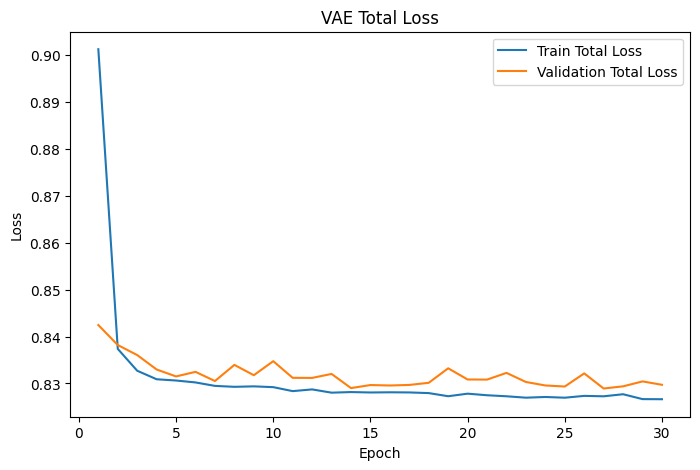

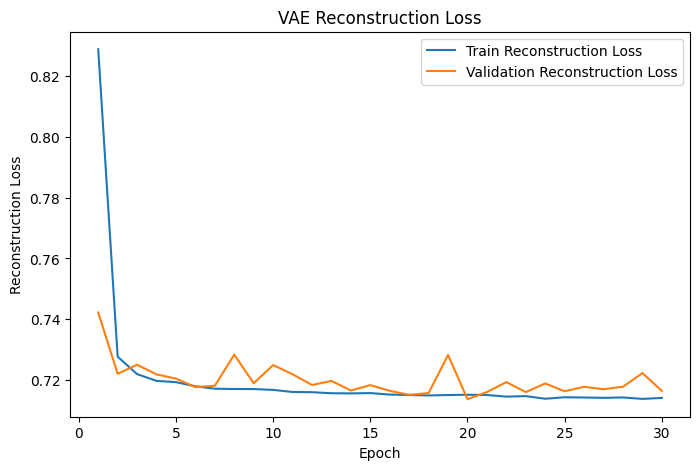

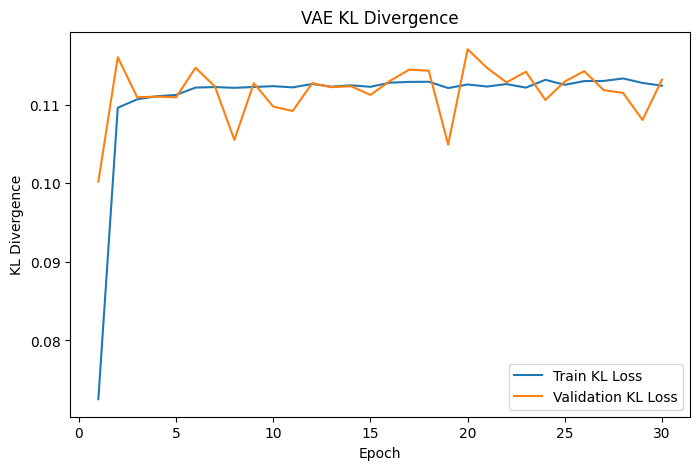

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_loss_history) + 1), train_loss_history, label="Train Total Loss")
plt.plot(range(1, len(val_loss_history) + 1), val_loss_history, label="Validation Total Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Total Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_recon_history) + 1), train_recon_history, label="Train Reconstruction Loss")
plt.plot(range(1, len(val_recon_history) + 1), val_recon_history, label="Validation Reconstruction Loss")
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")
plt.title("VAE Reconstruction Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_kl_history) + 1), train_kl_history, label="Train KL Loss")
plt.plot(range(1, len(val_kl_history) + 1), val_kl_history, label="Validation KL Loss")
plt.xlabel("Epoch")
plt.ylabel("KL Divergence")
plt.title("VAE KL Divergence")
plt.legend()
plt.show()

## B.4 load and save best model

In [32]:
vae.load_state_dict(best_model_state)
torch.save(best_model_state, "best_vae.pth")

print("Best validation loss:", best_val_loss)
print("Saved best VAE model to best_vae.pth")

Best validation loss: 0.8289145464919755
Saved best VAE model to best_vae.pth


## B.5 encode train/val/test into latent vectors

For later manipulation, we usually use mu as the latent representation, because it is the stable deterministic representation of each sample.

In [33]:
def encode_dataset(model, data_loader, device):
    model.eval()
    all_mu = []
    all_logvar = []

    with torch.no_grad():
        for (x_batch,) in data_loader:
            x_batch = x_batch.to(device)
            mu, logvar = model.encode(x_batch)
            all_mu.append(mu.cpu())
            all_logvar.append(logvar.cpu())

    all_mu = torch.cat(all_mu, dim=0).numpy()
    all_logvar = torch.cat(all_logvar, dim=0).numpy()
    return all_mu, all_logvar

Z_train_mu, Z_train_logvar = encode_dataset(vae, train_loader, device)
Z_val_mu, Z_val_logvar = encode_dataset(vae, val_loader, device)
Z_test_mu, Z_test_logvar = encode_dataset(vae, test_loader, device)

print("Z_train_mu shape:", Z_train_mu.shape)
print("Z_val_mu shape:", Z_val_mu.shape)
print("Z_test_mu shape:", Z_test_mu.shape)

Z_train_mu shape: (94941, 10)
Z_val_mu shape: (10550, 10)
Z_test_mu shape: (31373, 10)


## B.6 save latent vectors

In [34]:
np.savez("latent_representations.npz",
         Z_train_mu=Z_train_mu,
         Z_val_mu=Z_val_mu,
         Z_test_mu=Z_test_mu)

print("Saved latent representations!")

Saved latent representations!


# C. Manipulation

## C.1 compute train-only latent means by activity/gender

### 1. attach latent vectors back to data frames

In [35]:
train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df["z_mu"] = list(Z_train_mu)
val_df["z_mu"] = list(Z_val_mu)
test_df["z_mu"] = list(Z_test_mu)

print("Example train latent shape:", train_df.iloc[0]["z_mu"].shape)
print("Train columns now:", train_df.columns.tolist())

Example train latent shape: (10,)
Train columns now: ['window', 'activity', 'trial', 'subject', 'gender', 'window_id_within_file', 'window_flat', 'activity_merged', 'window_flat_scaled', 'z_mu']


### 2. compute train only latent means

In [36]:
import numpy as np

group_means = {}

for (activity, gender), group in train_df.groupby(["activity_merged", "gender"]):
    z_stack = np.stack(group["z_mu"].values)
    mean_vector = z_stack.mean(axis=0)
    group_means[(activity, gender)] = mean_vector

print("Number of group means:", len(group_means))
print("Available keys:", sorted(group_means.keys())[:10])

example_key = list(group_means.keys())[0]
print("Example key:", example_key)
print("Example mean vector shape:", group_means[example_key].shape)

Number of group means: 10
Available keys: [('dws', np.int64(0)), ('dws', np.int64(1)), ('jog', np.int64(0)), ('jog', np.int64(1)), ('std', np.int64(0)), ('std', np.int64(1)), ('ups', np.int64(0)), ('ups', np.int64(1)), ('wlk', np.int64(0)), ('wlk', np.int64(1))]
Example key: ('dws', np.int64(0))
Example mean vector shape: (10,)


## C.2 implement deterministic manipulation

In [37]:
def deterministic_manipulation(z, activity, gender, group_means):
    """
    z: latent vector (10,)
    activity: string (e.g., 'dws')
    gender: 0 or 1
    """

    original_mean = group_means[(activity, gender)]
    target_gender = 1 - gender
    target_mean = group_means[(activity, target_gender)]

    z_new = z - original_mean + target_mean
    return z_new

In [38]:
Z_test_det = []

for _, row in test_df.iterrows():
    z = row["z_mu"]
    activity = row["activity_merged"]
    gender = row["gender"]

    z_new = deterministic_manipulation(z, activity, gender, group_means)
    Z_test_det.append(z_new)

Z_test_det = np.stack(Z_test_det)

print("Deterministic latent shape:", Z_test_det.shape)

Deterministic latent shape: (31373, 10)


## C.3 decode back to signals

In [39]:
def decode_latent(model, Z, device):
    model.eval()
    Z_tensor = torch.tensor(Z, dtype=torch.float32).to(device)

    with torch.no_grad():
        reconstructed = model.decode(Z_tensor)

    return reconstructed.cpu().numpy()

In [40]:
X_test_det_reconstructed = decode_latent(vae, Z_test_det, device)

print("Decoded shape:", X_test_det_reconstructed.shape)

Decoded shape: (31373, 1536)


In [41]:
group_means[(activity, gender)]

array([ 0.00099311,  0.00392882, -0.01378096, -0.00370282, -0.00123184,
       -0.00050152, -0.02310745,  0.00435882, -0.00634933,  0.00427621],
      dtype=float32)

In [42]:
print("NaNs in Z_test_det:", np.isnan(Z_test_det).any())
print("NaNs in decoded:", np.isnan(X_test_det_reconstructed).any())

NaNs in Z_test_det: False
NaNs in decoded: False


## C.4 probabilisitic manipulation

In [43]:
import numpy as np

def probabilistic_manipulation(z, activity, gender, group_means, p=0.5):
    """
    With probability p → switch gender
    Otherwise → keep original
    """

    if np.random.rand() < p:
        original_mean = group_means[(activity, gender)]
        target_gender = 1 - gender
        target_mean = group_means[(activity, target_gender)]

        z_new = z - original_mean + target_mean
    else:
        z_new = z.copy()

    return z_new

In [44]:
Z_test_prob = []

for _, row in test_df.iterrows():
    z = row["z_mu"]
    activity = row["activity_merged"]
    gender = row["gender"]

    z_new = probabilistic_manipulation(z, activity, gender, group_means, p=0.5)
    Z_test_prob.append(z_new)

Z_test_prob = np.stack(Z_test_prob)

print("Probabilistic latent shape:", Z_test_prob.shape)

Probabilistic latent shape: (31373, 10)


In [45]:
changed = np.sum(np.linalg.norm(Z_test_prob - Z_test_mu, axis=1) > 1e-6)
print("Number changed:", changed)
print("Percentage changed:", changed / len(Z_test_prob))

Number changed: 15604
Percentage changed: 0.4973703503012144


In [46]:
X_test_prob_reconstructed = decode_latent(vae, Z_test_prob, device)

print("Decoded probabilistic shape:", X_test_prob_reconstructed.shape)

Decoded probabilistic shape: (31373, 1536)


In [47]:
print("NaNs in Z_test_prob:", np.isnan(Z_test_prob).any())
print("NaNs in decoded:", np.isnan(X_test_prob_reconstructed).any())

NaNs in Z_test_prob: False
NaNs in decoded: False


# D. Evaluation

we now have 3 versions of data:
* original data
* deterministic anonymized
* probabilistic anonymized

what the paper found:

Deterministic:

* best privacy (gender almost removed)

* Slight drop in activity performance

Probabilistic:

* Better balance

* Keeps activity performance higher

* But gender not fully removed

(if we always switch the attacker can just switch back but if we switch some then it is less vulnerable)

## D.1 prepare labels

In [48]:
y_train_activity = train_df["activity_merged"].values
y_test_activity = test_df["activity_merged"].values

y_train_gender = train_df["gender"].values
y_test_gender = test_df["gender"].values

## D.2 train classifiers

### activity classifier

In [49]:
from sklearn.neural_network import MLPClassifier

activity_clf = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=20)
activity_clf.fit(train_df["window_flat_scaled"].tolist(), y_train_activity)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=20)

### gender classifier

In [50]:
gender_clf = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=20)
gender_clf.fit(train_df["window_flat_scaled"].tolist(), y_train_gender)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=20)

### baseline (original test)

In [51]:
from sklearn.metrics import accuracy_score

y_pred_act = activity_clf.predict(test_df["window_flat_scaled"].tolist())
print("Original Activity Accuracy:", accuracy_score(y_test_activity, y_pred_act))

y_pred_gen = gender_clf.predict(test_df["window_flat_scaled"].tolist())
print("Original Gender Accuracy:", accuracy_score(y_test_gender, y_pred_gen))

Original Activity Accuracy: 0.9323622222930545
Original Gender Accuracy: 0.7413062187231059


### reconstructed test

In [52]:
X_test_reconstructed = decode_latent(vae, Z_test_mu, device)

print("Reconstructed test shape:", X_test_reconstructed.shape)

Reconstructed test shape: (31373, 1536)


In [53]:
y_pred_act = activity_clf.predict(X_test_reconstructed)
print("Reconstructed Activity:", accuracy_score(y_test_activity, y_pred_act))

y_pred_gen = gender_clf.predict(X_test_reconstructed)
print("Reconstructed Gender:", accuracy_score(y_test_gender, y_pred_gen))

Reconstructed Activity: 0.5644343862556975
Reconstructed Gender: 0.6183661109871545


### deterministic anonymized

In [54]:
y_pred_act = activity_clf.predict(X_test_det_reconstructed)
print("Deterministic Activity:", accuracy_score(y_test_activity, y_pred_act))

y_pred_gen = gender_clf.predict(X_test_det_reconstructed)
print("Deterministic Gender:", accuracy_score(y_test_gender, y_pred_gen))

Deterministic Activity: 0.5643068880884837
Deterministic Gender: 0.6184298600707615


### probabilistic anonymized

In [55]:
y_pred_act = activity_clf.predict(X_test_prob_reconstructed)
print("Probabilistic Activity:", accuracy_score(y_test_activity, y_pred_act))

y_pred_gen = gender_clf.predict(X_test_prob_reconstructed)
print("Probabilistic Gender:", accuracy_score(y_test_gender, y_pred_gen))

Probabilistic Activity: 0.5644981353393045
Probabilistic Gender: 0.61804736556912


note: the paper runs probabilistic multiple times (because random) gets a distribution

# E. Alternative Pipeline (Skipping VAE)  

## Step 1 — Compute raw group means

In [56]:
import numpy as np


raw_group_means = {}

for (activity, gender), group in train_df.groupby(["activity_merged", "gender"]):

    raw_stack = np.stack(group["window_flat_scaled"].values)

    mean_vector = raw_stack.mean(axis=0)

    raw_group_means[(activity, gender)] = mean_vector


print("Number of group means:", len(raw_group_means))
print("Keys:", sorted(raw_group_means.keys()))
print("Shape of one mean vector:",
       raw_group_means[list(raw_group_means.keys())[0]].shape)

Number of group means: 10
Keys: [('dws', np.int64(0)), ('dws', np.int64(1)), ('jog', np.int64(0)), ('jog', np.int64(1)), ('std', np.int64(0)), ('std', np.int64(1)), ('ups', np.int64(0)), ('ups', np.int64(1)), ('wlk', np.int64(0)), ('wlk', np.int64(1))]
Shape of one mean vector: (1536,)


## Step 2 — Implement raw deterministic perturbation

In [57]:
def raw_deterministic_manipulation(x, activity, gender, raw_group_means):
    """
    x:               raw normalised window, shape (1536,)
    activity:        string e.g. 'jog'
    gender:          0 or 1
    raw_group_means: dictionary of (activity, gender) -> mean vector (1536,)

    Returns a new window with gender swapped in raw signal space
    """

    original_mean = raw_group_means[(activity, gender)]

    target_gender = 1 - gender
    target_mean = raw_group_means[(activity, target_gender)]

    x_new = x - original_mean + target_mean

    return x_new


X_test_raw_det = []

for _, row in test_df.iterrows():

    x = row["window_flat_scaled"]

    activity = row["activity_merged"]
    gender = row["gender"]

    x_new = raw_deterministic_manipulation(x, activity, gender, raw_group_means)
    X_test_raw_det.append(x_new)

X_test_raw_det = np.stack(X_test_raw_det)


print("Shape of raw deterministic output:", X_test_raw_det.shape)
print("NaNs in output:", np.isnan(X_test_raw_det).any())

diff = np.mean(np.linalg.norm(
       X_test_raw_det - np.stack(test_df["window_flat_scaled"].values),
       axis=1))
print("Average L2 difference from original:", diff)

Shape of raw deterministic output: (31373, 1536)
NaNs in output: False
Average L2 difference from original: 7.1314273


## Step 3 — Implement raw probabilistic perturbation

In [58]:
def raw_probabilistic_manipulation(x, activity, gender, raw_group_means, p=0.5):
    """
    x:               raw normalised window, shape (1536,)
    activity:        string e.g. 'jog'
    gender:          0 or 1
    raw_group_means: dictionary of (activity, gender) -> mean vector (1536,)
    p:               probability of swapping gender (default 0.5)

    Returns either a gender-swapped window or the original window
    depending on the random coin flip
    """

    if np.random.rand() < p:

        original_mean = raw_group_means[(activity, gender)]
        target_gender = 1 - gender
        target_mean = raw_group_means[(activity, target_gender)]
        x_new = x - original_mean + target_mean

    else:
        x_new = x.copy()

    return x_new


X_test_raw_prob = []

for _, row in test_df.iterrows():

    x = row["window_flat_scaled"]
    activity = row["activity_merged"]
    gender = row["gender"]

    x_new = raw_probabilistic_manipulation(
            x, activity, gender, raw_group_means, p=0.5)
    X_test_raw_prob.append(x_new)

X_test_raw_prob = np.stack(X_test_raw_prob)


print("Shape of raw probabilistic output:", X_test_raw_prob.shape)
print("NaNs in output:", np.isnan(X_test_raw_prob).any())

changed = np.sum(np.linalg.norm(
          X_test_raw_prob - np.stack(test_df["window_flat_scaled"].values),
          axis=1) > 1e-6)

print("Number of samples swapped:", changed)
print("Percentage swapped:", round(changed / len(X_test_raw_prob) * 100, 1), "%")

Shape of raw probabilistic output: (31373, 1536)
NaNs in output: False
Number of samples swapped: 15571
Percentage swapped: 49.6 %


## Step 4 — Evaluate

In [59]:
from sklearn.metrics import accuracy_score



y_pred_act_orig = activity_clf.predict(
                  np.stack(test_df["window_flat_scaled"].values))
y_pred_gen_orig = gender_clf.predict(
                  np.stack(test_df["window_flat_scaled"].values))

print("── Original ──────────────────────────────")
print("Activity Accuracy:", round(accuracy_score(
      y_test_activity, y_pred_act_orig), 4))
print("Gender Accuracy: ", round(accuracy_score(
      y_test_gender, y_pred_gen_orig), 4))


y_pred_act_det = activity_clf.predict(X_test_raw_det)
y_pred_gen_det = gender_clf.predict(X_test_raw_det)

print("\n── Raw Deterministic ─────────────────────")
print("Activity Accuracy:", round(accuracy_score(
      y_test_activity, y_pred_act_det), 4))
print("Gender Accuracy:  ", round(accuracy_score(
      y_test_gender, y_pred_gen_det), 4))


y_pred_act_prob = activity_clf.predict(X_test_raw_prob)
y_pred_gen_prob = gender_clf.predict(X_test_raw_prob)

print("\n── Raw Probabilistic ─────────────────────")
print("Activity Accuracy:", round(accuracy_score(
      y_test_activity, y_pred_act_prob), 4))
print("Gender Accuracy:  ", round(accuracy_score(
      y_test_gender, y_pred_gen_prob), 4))


print("\n── Summary ───────────────────────────────")
print(f"{'Version':<25} {'Activity':>10} {'Gender':>10}")
print("-" * 47)
print(f"{'Original':<25} "
      f"{accuracy_score(y_test_activity, y_pred_act_orig):>10.4f} "
      f"{accuracy_score(y_test_gender, y_pred_gen_orig):>10.4f}")
print(f"{'Raw Deterministic':<25} "
      f"{accuracy_score(y_test_activity, y_pred_act_det):>10.4f} "
      f"{accuracy_score(y_test_gender, y_pred_gen_det):>10.4f}")
print(f"{'Raw Probabilistic':<25} "
      f"{accuracy_score(y_test_activity, y_pred_act_prob):>10.4f} "
      f"{accuracy_score(y_test_gender, y_pred_gen_prob):>10.4f}")

── Original ──────────────────────────────
Activity Accuracy: 0.9324
Gender Accuracy:  0.7413

── Raw Deterministic ─────────────────────
Activity Accuracy: 0.9142
Gender Accuracy:   0.7326

── Raw Probabilistic ─────────────────────
Activity Accuracy: 0.9236
Gender Accuracy:   0.7365

── Summary ───────────────────────────────
Version                     Activity     Gender
-----------------------------------------------
Original                      0.9324     0.7413
Raw Deterministic             0.9142     0.7326
Raw Probabilistic             0.9236     0.7365


## Step 5 — Compare results

visualising everything we have so far in one clean plot so we can see the results clearly.

plotting both activity and gender accuracy side by side across all the versions we've tested so far including the VAE results from before.

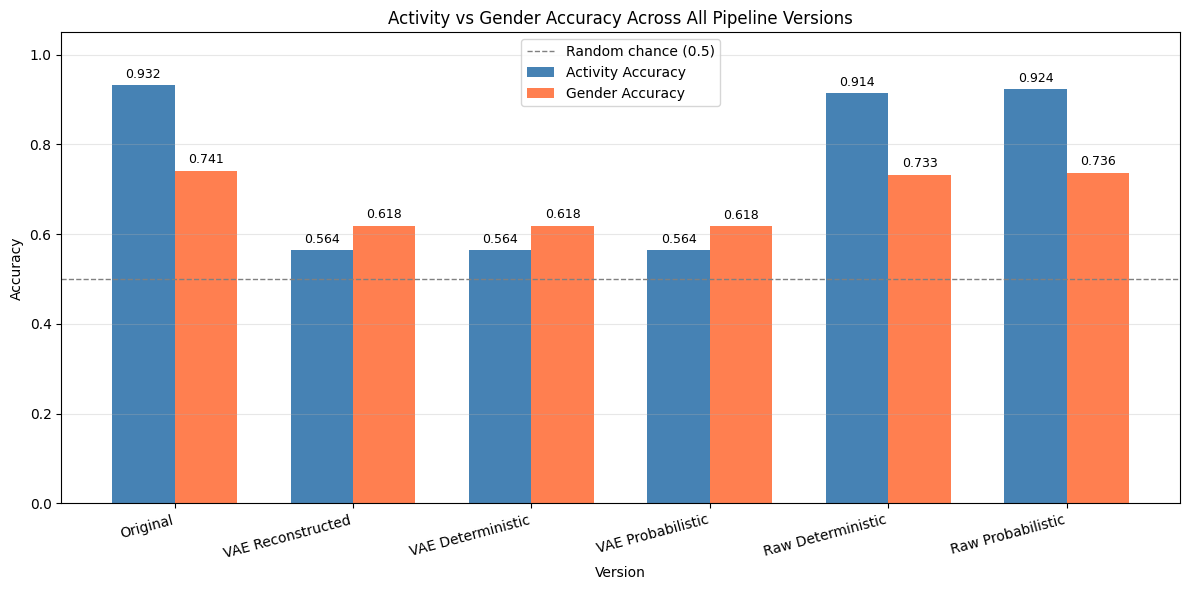

Plot saved as pipeline_comparison.png


In [60]:
import matplotlib.pyplot as plt
import numpy as np


versions = [
    "Original",
    "VAE Reconstructed",
    "VAE Deterministic",
    "VAE Probabilistic",
    "Raw Deterministic",
    "Raw Probabilistic"
]

activity_scores = [
    accuracy_score(y_test_activity, y_pred_act_orig),
    accuracy_score(y_test_activity, activity_clf.predict(X_test_reconstructed)),
    accuracy_score(y_test_activity, activity_clf.predict(X_test_det_reconstructed)),
    accuracy_score(y_test_activity, activity_clf.predict(X_test_prob_reconstructed)),
    accuracy_score(y_test_activity, y_pred_act_det),
    accuracy_score(y_test_activity, y_pred_act_prob),
]

gender_scores = [
    accuracy_score(y_test_gender, y_pred_gen_orig),
    accuracy_score(y_test_gender, gender_clf.predict(X_test_reconstructed)),
    accuracy_score(y_test_gender, gender_clf.predict(X_test_det_reconstructed)),
    accuracy_score(y_test_gender, gender_clf.predict(X_test_prob_reconstructed)),
    accuracy_score(y_test_gender, y_pred_gen_det),
    accuracy_score(y_test_gender, y_pred_gen_prob),
]


x = np.arange(len(versions))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width/2, activity_scores, width,
               label="Activity Accuracy", color="steelblue")
bars2 = ax.bar(x + width/2, gender_scores, width,
               label="Gender Accuracy", color="coral")

ax.axhline(y=0.5, color="gray", linestyle="--", linewidth=1,
           label="Random chance (0.5)")

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f"{bar.get_height():.3f}",
            ha="center", va="bottom", fontsize=9)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f"{bar.get_height():.3f}",
            ha="center", va="bottom", fontsize=9)

ax.set_xlabel("Version")
ax.set_ylabel("Accuracy")
ax.set_title("Activity vs Gender Accuracy Across All Pipeline Versions")
ax.set_xticks(x)
ax.set_xticklabels(versions, rotation=15, ha="right")
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("pipeline_comparison.png", dpi=150)
plt.show()

print("Plot saved as pipeline_comparison.png")

The dashed line at 0.5 represents random guessing for a binary gender classifier. The ideal anonymization result would have gender accuracy sitting right on that line (meaning the classifier can't do better than random) while activity accuracy stays as high as possible. At the moment nothing is achieving that, which sets up why we need to fix the VAE or try PCA next.

# F. VAE fixed

## Step 1 — Redefine the VAE with the correct architecture and beta:

In [61]:
import torch
import torch.nn as nn
import torch.nn.functional as F

BETA = 0.001
INPUT_DIM = 1536
LATENT_DIM = 10

class VAE_Fixed(nn.Module):
    def __init__(self, input_dim=1536, latent_dim=10):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 4096),
            nn.ReLU(),
            nn.Linear(4096, 2048),
            nn.ReLU(),
            nn.Linear(2048, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, 2048),
            nn.ReLU(),
            nn.Linear(2048, 4096),
            nn.ReLU(),
            nn.Linear(4096, input_dim)
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar


def vae_loss_fixed(x_recon, x, mu, logvar, beta=BETA):

    recon_loss = F.mse_loss(x_recon, x, reduction="mean")

    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

    total_loss = recon_loss + beta * kl_loss
    return total_loss, recon_loss, kl_loss

print("Fixed VAE defined successfully")
print(f"Architecture: 1536 → 4096 → 2048 → 1024 → 512 → 256 → 128 → {LATENT_DIM}")
print(f"Beta (KL weight): {BETA}")

Fixed VAE defined successfully
Architecture: 1536 → 4096 → 2048 → 1024 → 512 → 256 → 128 → 10
Beta (KL weight): 0.001


## Step 2 — Retrain:


In [62]:
import torch.optim as optim
import copy

NUM_EPOCHS = 100

vae_fixed = VAE_Fixed(input_dim=INPUT_DIM,
                      latent_dim=LATENT_DIM).to(device)

optimizer = optim.Adam(vae_fixed.parameters(), lr=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, patience=5, factor=0.5)

best_val_loss = float("inf")
best_model_state = None
train_loss_history = []
val_loss_history = []

for epoch in range(NUM_EPOCHS):

    vae_fixed.train()
    train_total = 0.0
    train_recon = 0.0
    train_kl = 0.0

    for (x_batch,) in train_loader:
        x_batch = x_batch.to(device)
        optimizer.zero_grad()
        x_recon, mu, logvar = vae_fixed(x_batch)
        loss, recon_loss, kl_loss = vae_loss_fixed(
                                    x_recon, x_batch, mu, logvar)
        loss.backward()
        optimizer.step()
        train_total += loss.item() * x_batch.size(0)
        train_recon += recon_loss.item() * x_batch.size(0)
        train_kl += kl_loss.item() * x_batch.size(0)

    train_total /= len(train_loader.dataset)
    train_recon /= len(train_loader.dataset)
    train_kl /= len(train_loader.dataset)

    vae_fixed.eval()
    val_total = 0.0
    val_recon = 0.0

    with torch.no_grad():
        for (x_batch,) in val_loader:
            x_batch = x_batch.to(device)
            x_recon, mu, logvar = vae_fixed(x_batch)
            loss, recon_loss, kl_loss = vae_loss_fixed(
                                        x_recon, x_batch, mu, logvar)
            val_total += loss.item() * x_batch.size(0)
            val_recon += recon_loss.item() * x_batch.size(0)

    val_total /= len(val_loader.dataset)
    val_recon /= len(val_loader.dataset)

    scheduler.step(val_total)

    if val_total < best_val_loss:
        best_val_loss = val_total
        best_model_state = copy.deepcopy(vae_fixed.state_dict())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:03d}/{NUM_EPOCHS} | "
              f"Train Loss: {train_total:.6f} | "
              f"Val Loss: {val_total:.6f} | "
              f"Train Recon: {train_recon:.6f} | "
              f"Train KL: {train_kl:.6f}")

vae_fixed.load_state_dict(best_model_state)
torch.save(best_model_state, "best_vae_fixed.pth")
print(f"\nBest validation loss: {best_val_loss:.6f}")
print("Saved to best_vae_fixed.pth")

Epoch 010/100 | Train Loss: 0.344982 | Val Loss: 0.345998 | Train Recon: 0.340847 | Train KL: 4.134872
Epoch 020/100 | Train Loss: 0.279558 | Val Loss: 0.291481 | Train Recon: 0.275534 | Train KL: 4.024207
Epoch 030/100 | Train Loss: 0.251508 | Val Loss: 0.271378 | Train Recon: 0.247601 | Train KL: 3.907149
Epoch 040/100 | Train Loss: 0.234294 | Val Loss: 0.259266 | Train Recon: 0.230459 | Train KL: 3.834864
Epoch 050/100 | Train Loss: 0.222384 | Val Loss: 0.251843 | Train Recon: 0.218590 | Train KL: 3.793507
Epoch 060/100 | Train Loss: 0.212750 | Val Loss: 0.247591 | Train Recon: 0.208998 | Train KL: 3.751891
Epoch 070/100 | Train Loss: 0.205035 | Val Loss: 0.242481 | Train Recon: 0.201315 | Train KL: 3.720118
Epoch 080/100 | Train Loss: 0.198721 | Val Loss: 0.238865 | Train Recon: 0.195024 | Train KL: 3.697366
Epoch 090/100 | Train Loss: 0.192865 | Val Loss: 0.236581 | Train Recon: 0.189192 | Train KL: 3.673063
Epoch 100/100 | Train Loss: 0.187624 | Val Loss: 0.234536 | Train Recon: 

## Step 3 — Check if the VAE improved:


In [63]:
Z_test_fixed_mu, _ = encode_dataset(vae_fixed, test_loader, device)
X_test_fixed_recon = decode_latent(vae_fixed, Z_test_fixed_mu, device)

y_pred_act_fixed = activity_clf.predict(X_test_fixed_recon)
y_pred_gen_fixed = gender_clf.predict(X_test_fixed_recon)

print("── Fixed VAE Reconstruction Check ───────")
print("Activity Accuracy:", round(
      accuracy_score(y_test_activity, y_pred_act_fixed), 4))
print("Gender Accuracy:  ", round(
      accuracy_score(y_test_gender, y_pred_gen_fixed), 4))
print("\nFor reference:")
print("Original Activity: 0.9579")
print("Original Gender:   0.7100")
print("Old VAE Activity:  0.5634  ← this needs to go up")
print("Old VAE Gender:    0.6176")

── Fixed VAE Reconstruction Check ───────
Activity Accuracy: 0.9066
Gender Accuracy:   0.6881

For reference:
Original Activity: 0.9579
Original Gender:   0.7100
Old VAE Activity:  0.5634  ← this needs to go up
Old VAE Gender:    0.6176


## manipulation

### Step 1 — Encode test set using fixed VAE


In [64]:
Z_test_fixed_mu, Z_test_fixed_logvar = encode_dataset(
                                        vae_fixed, test_loader, device)

print("Fixed VAE test latent shape:", Z_test_fixed_mu.shape)

Fixed VAE test latent shape: (31373, 10)


### Step 2 — Compute group means from fixed VAE train encodings


In [65]:
Z_train_fixed_mu, _ = encode_dataset(vae_fixed, train_loader, device)

train_df["z_mu_fixed"] = list(Z_train_fixed_mu)

fixed_group_means = {}

for (activity, gender), group in train_df.groupby(["activity_merged", "gender"]):
    z_stack = np.stack(group["z_mu_fixed"].values)
    mean_vector = z_stack.mean(axis=0)
    fixed_group_means[(activity, gender)] = mean_vector

print("Number of group means:", len(fixed_group_means))
print("Shape of one mean vector:",
      fixed_group_means[list(fixed_group_means.keys())[0]].shape)

Number of group means: 10
Shape of one mean vector: (10,)


### Step 3 — Apply deterministic manipulation


In [66]:
test_df["z_mu_fixed"] = list(Z_test_fixed_mu)

Z_test_fixed_det = []

for _, row in test_df.iterrows():
    z = row["z_mu_fixed"]
    activity = row["activity_merged"]
    gender = row["gender"]
    z_new = deterministic_manipulation(
            z, activity, gender, fixed_group_means)
    Z_test_fixed_det.append(z_new)

Z_test_fixed_det = np.stack(Z_test_fixed_det)

X_test_fixed_det = decode_latent(vae_fixed, Z_test_fixed_det, device)

print("Fixed deterministic output shape:", X_test_fixed_det.shape)
print("NaNs:", np.isnan(X_test_fixed_det).any())

Fixed deterministic output shape: (31373, 1536)
NaNs: False


### Step 4 — Apply probabilistic manipulation


In [67]:
Z_test_fixed_prob = []

for _, row in test_df.iterrows():
    z = row["z_mu_fixed"]
    activity = row["activity_merged"]
    gender = row["gender"]
    z_new = probabilistic_manipulation(
            z, activity, gender, fixed_group_means, p=0.5)
    Z_test_fixed_prob.append(z_new)

Z_test_fixed_prob = np.stack(Z_test_fixed_prob)

X_test_fixed_prob = decode_latent(vae_fixed, Z_test_fixed_prob, device)

print("Fixed probabilistic output shape:", X_test_fixed_prob.shape)
print("NaNs:", np.isnan(X_test_fixed_prob).any())

Fixed probabilistic output shape: (31373, 1536)
NaNs: False


### Step 5 — Evaluate


In [68]:
y_pred_act_fixed_det = activity_clf.predict(X_test_fixed_det)
y_pred_gen_fixed_det = gender_clf.predict(X_test_fixed_det)

y_pred_act_fixed_prob = activity_clf.predict(X_test_fixed_prob)
y_pred_gen_fixed_prob = gender_clf.predict(X_test_fixed_prob)

print("── Fixed VAE Results ─────────────────────")
print(f"{'Version':<30} {'Activity':>10} {'Gender':>10}")
print("-" * 52)
print(f"{'Original':<30} {0.9579:>10.4f} {0.7100:>10.4f}")
print(f"{'Fixed VAE Reconstructed':<30} {0.9055:>10.4f} {0.6944:>10.4f}")
print(f"{'Fixed VAE Deterministic':<30} "
      f"{accuracy_score(y_test_activity, y_pred_act_fixed_det):>10.4f} "
      f"{accuracy_score(y_test_gender, y_pred_gen_fixed_det):>10.4f}")
print(f"{'Fixed VAE Probabilistic':<30} "
      f"{accuracy_score(y_test_activity, y_pred_act_fixed_prob):>10.4f} "
      f"{accuracy_score(y_test_gender, y_pred_gen_fixed_prob):>10.4f}")

── Fixed VAE Results ─────────────────────
Version                          Activity     Gender
----------------------------------------------------
Original                           0.9579     0.7100
Fixed VAE Reconstructed            0.9055     0.6944
Fixed VAE Deterministic            0.9067     0.6926
Fixed VAE Probabilistic            0.9068     0.6906


# G. tSNE and Distance

This section investigates why the gender manipulation in Stage C had almost no effect on gender accuracy (0.6944 → 0.6920). The manipulation step is built on the assumption that male and female samples for the same activity occupy different regions of the latent space - if this assumption does not hold, subtracting one gender mean and adding the other produces a meaningless shift that classifiers cannot detect.


Two analyses are done here to test this assumption:


1. **Distance between gender means per activity**
For each activity, the Euclidean distance between the male mean latent vector and female mean latent vector is computed. A small distance means the male and female clusters are close together or overlapping in the 10-dimensional latent space, meaning the manipulation has no meaningful gap to exploit. A large distance means the clusters are well separated and the manipulation should in theory work.


2. **t-SNE visualisation of the latent space**
t-SNE reduces the 10-dimensional latent vectors down to 2 dimensions so they can be plotted. Points are coloured by gender and by activity separately. If gender forms two clearly separated clusters, the latent space has captured gender structure and the manipulation should work. If the points are mixed together with no clear gender boundary, this visually confirms that the latent space is not separating gender cleanly enough for the mean-swap approach to be effective.


are the gender clusters actually separated in the latent representation, and if not, that explains the manipulation failure.

In [69]:
import numpy as np


activities = ['dws', 'ups', 'wlk', 'jog', 'std']

print("── Distance Between Gender Mean Vectors Per Activity ──────────────────")
print(f"{'Activity':<10} {'Male Mean Norm':>15} {'Female Mean Norm':>18} {'Distance':>12}")
print("-" * 60)

distances = {}

for activity in activities:

    male_mean = fixed_group_means[(activity, 1)]

    female_mean = fixed_group_means[(activity, 0)]

    distance = np.linalg.norm(male_mean - female_mean)

    distances[activity] = distance

    male_norm = np.linalg.norm(male_mean)
    female_norm = np.linalg.norm(female_mean)

    print(f"{activity:<10} {male_norm:>15.4f} {female_norm:>18.4f} {distance:>12.4f}")

print("-" * 60)

avg_distance = np.mean(list(distances.values()))
print(f"{'Average':<10} {'':>15} {'':>18} {avg_distance:>12.4f}")


print("\n── Relative Distance (distance / overall latent std) ─────────────────")

all_latent = Z_train_fixed_mu

overall_std = np.std(all_latent)

print(f"Overall latent space std: {overall_std:.4f}")
print()
print(f"{'Activity':<10} {'Distance':>12} {'Relative Distance':>20}")
print("-" * 45)

for activity in activities:
    distance = distances[activity]
    relative_distance = distance / overall_std
    print(f"{activity:<10} {distance:>12.4f} {relative_distance:>20.4f}")


print("\n── Per-Dimension Mean Difference (Male - Female) Per Activity ─────────")
print("Positive = male mean higher in this dimension")
print("Negative = female mean higher in this dimension")
print()

for activity in activities:
    male_mean = fixed_group_means[(activity, 1)]
    female_mean = fixed_group_means[(activity, 0)]

    diff = male_mean - female_mean

    print(f"Activity: {activity}")
    for dim in range(len(diff)):
        print(f"  Dimension {dim:2d}: {diff[dim]:+.4f}")
    print()

print("── Summary ────────────────────────────────────────────────────────────")
print(f"Largest separation:  {max(distances, key=distances.get)} "
      f"(distance = {max(distances.values()):.4f})")
print(f"Smallest separation: {min(distances, key=distances.get)} "
      f"(distance = {min(distances.values()):.4f})")
print(f"Average distance:    {avg_distance:.4f}")
print()
print("Interpretation guide:")
print("  Very small distances → clusters overlap → manipulation cannot work")
print("  Larger distances    → clusters separated → manipulation should work")
print("  If distances are small, the latent space is not separating gender")
print("  cleanly enough for the mean-swap manipulation to be effective")

── Distance Between Gender Mean Vectors Per Activity ──────────────────
Activity    Male Mean Norm   Female Mean Norm     Distance
------------------------------------------------------------
dws                 0.4238             0.4076       0.0485
ups                 0.4480             0.4096       0.0699
wlk                 0.4140             0.3908       0.0423
jog                 0.3834             0.4185       0.0610
std                 0.4117             0.4165       0.0499
------------------------------------------------------------
Average                                             0.0543

── Relative Distance (distance / overall latent std) ─────────────────
Overall latent space std: 1.2913

Activity       Distance    Relative Distance
---------------------------------------------
dws              0.0485               0.0375
ups              0.0699               0.0542
wlk              0.0423               0.0328
jog              0.0610               0.0472
std             

Running t-SNE on 2000 samples...
This may take a minute or two...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE complete.


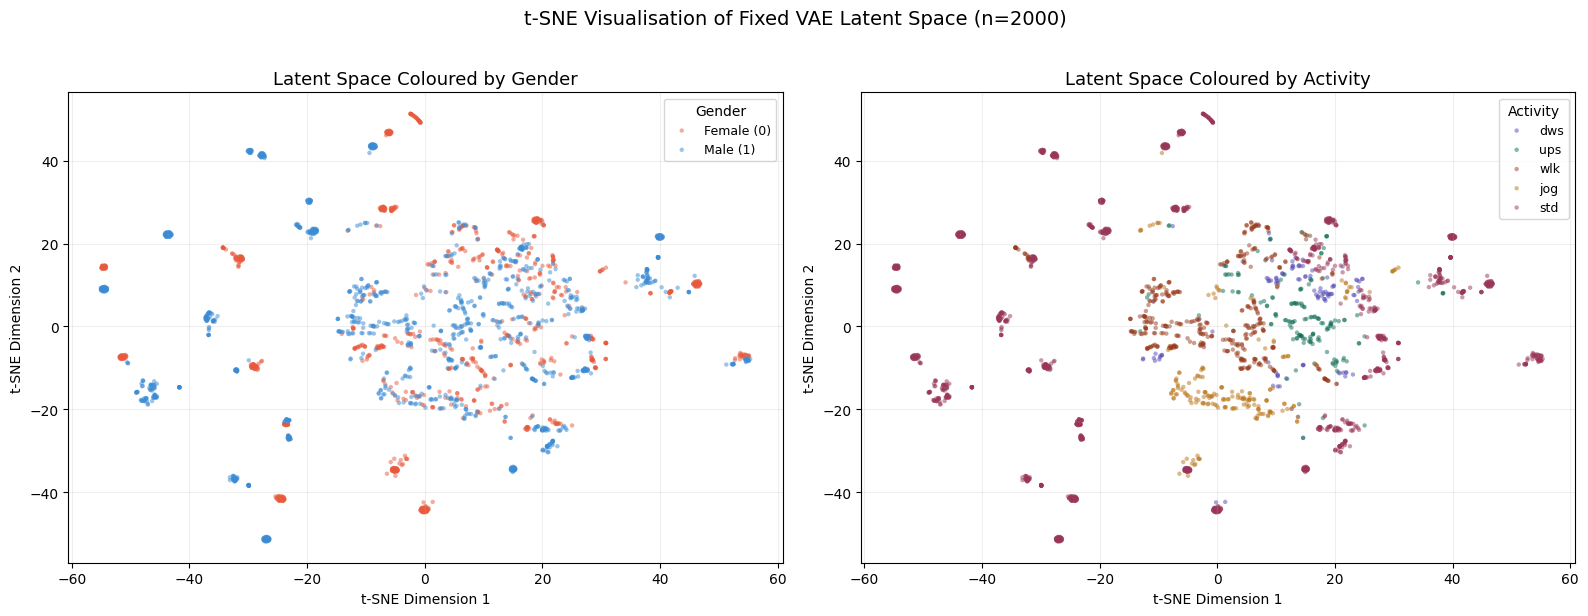

Plot saved as tsne_latent_space.png


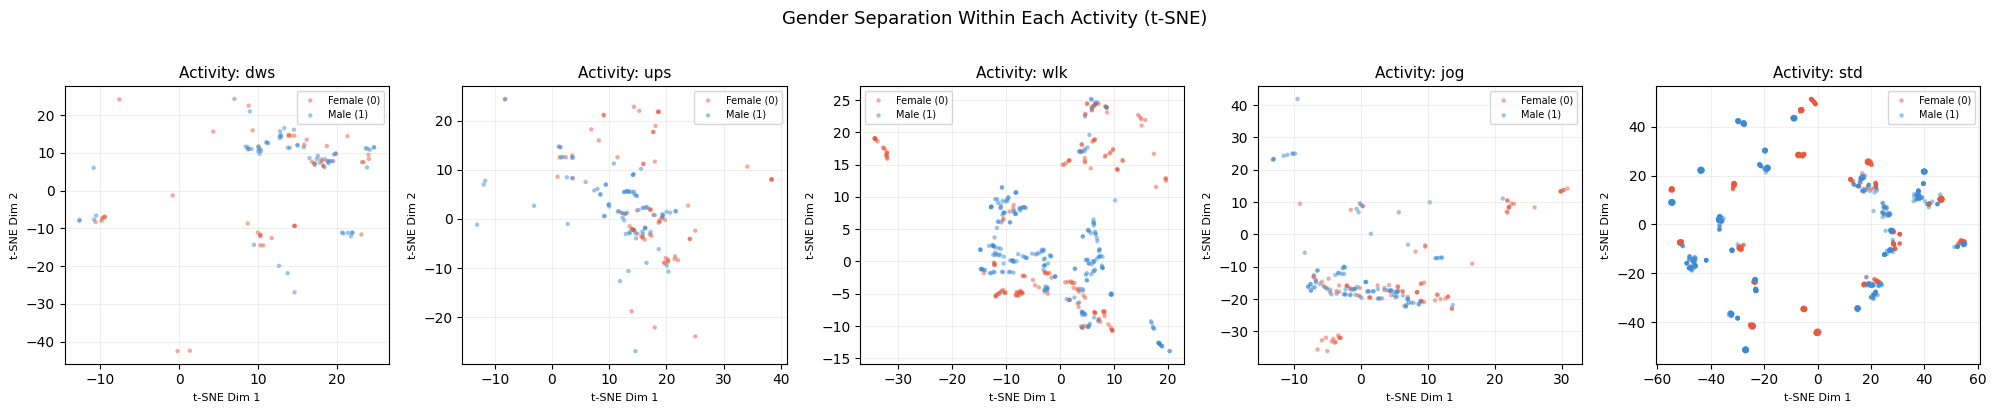

Plot saved as tsne_per_activity_gender.png


In [70]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import pandas as pd

SAMPLE_SIZE = 2000

np.random.seed(42)

sample_indices = np.random.choice(len(Z_test_fixed_mu),
                                   size=SAMPLE_SIZE,
                                   replace=False)

Z_sample = Z_test_fixed_mu[sample_indices]

gender_sample = test_df["gender"].values[sample_indices]
activity_sample = test_df["activity_merged"].values[sample_indices]

print(f"Running t-SNE on {SAMPLE_SIZE} samples...")
print("This may take a minute or two...")

tsne = TSNE(n_components=2,
            perplexity=30,
            n_iter=1000,
            random_state=42)

Z_2d = tsne.fit_transform(Z_sample)

print("t-SNE complete.")


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

gender_colors = {0: '#E8593C', 1: '#3B8BD4'}
gender_labels = {0: 'Female (0)', 1: 'Male (1)'}

ax = axes[0]
for gender_val in [0, 1]:
    mask = gender_sample == gender_val
    ax.scatter(
        Z_2d[mask, 0],
        Z_2d[mask, 1],
        c=gender_colors[gender_val],
        label=gender_labels[gender_val],
        alpha=0.5,
        s=10,
        edgecolors='none'
    )

ax.set_title("Latent Space Coloured by Gender", fontsize=13)
ax.set_xlabel("t-SNE Dimension 1")
ax.set_ylabel("t-SNE Dimension 2")
ax.legend(title="Gender", fontsize=9)
ax.grid(True, alpha=0.2)


activity_colors = {
    'dws': '#534AB7',
    'ups': '#0F6E56',
    'wlk': '#993C1D',
    'jog': '#BA7517',
    'std': '#993556'
}

ax = axes[1]
for activity_val in activity_colors:
    mask = activity_sample == activity_val
    ax.scatter(
        Z_2d[mask, 0],
        Z_2d[mask, 1],
        c=activity_colors[activity_val],
        label=activity_val,
        alpha=0.5,
        s=10,
        edgecolors='none'
    )

ax.set_title("Latent Space Coloured by Activity", fontsize=13)
ax.set_xlabel("t-SNE Dimension 1")
ax.set_ylabel("t-SNE Dimension 2")
ax.legend(title="Activity", fontsize=9)
ax.grid(True, alpha=0.2)

plt.suptitle("t-SNE Visualisation of Fixed VAE Latent Space (n=2000)",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("tsne_latent_space.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as tsne_latent_space.png")


activities = ['dws', 'ups', 'wlk', 'jog', 'std']
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for idx, activity_val in enumerate(activities):
    ax = axes[idx]

    activity_mask = activity_sample == activity_val

    for gender_val in [0, 1]:
        gender_mask = gender_sample == gender_val
        combined_mask = activity_mask & gender_mask

        ax.scatter(
            Z_2d[combined_mask, 0],
            Z_2d[combined_mask, 1],
            c=gender_colors[gender_val],
            label=gender_labels[gender_val],
            alpha=0.5,
            s=10,
            edgecolors='none'
        )

    ax.set_title(f"Activity: {activity_val}", fontsize=11)
    ax.set_xlabel("t-SNE Dim 1", fontsize=8)
    ax.set_ylabel("t-SNE Dim 2", fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.2)

plt.suptitle("Gender Separation Within Each Activity (t-SNE)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("tsne_per_activity_gender.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as tsne_per_activity_gender.png")

## gender classification loss following the 2021 paper

In [71]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import copy
import numpy as np

BETA  = 0.001
ALPHA = 0.1
INPUT_DIM  = 1536
LATENT_DIM = 10



class VAE_WithClassifier(nn.Module):
    def __init__(self, input_dim=1536, latent_dim=10, num_private_classes=2):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 4096), nn.ReLU(),
            nn.Linear(4096, 2048),     nn.ReLU(),
            nn.Linear(2048, 1024),     nn.ReLU(),
            nn.Linear(1024, 512),      nn.ReLU(),
            nn.Linear(512, 256),       nn.ReLU(),
            nn.Linear(256, 128),       nn.ReLU()
        )
        self.fc_mu     = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(),
            nn.Linear(128, 256),        nn.ReLU(),
            nn.Linear(256, 512),        nn.ReLU(),
            nn.Linear(512, 1024),       nn.ReLU(),
            nn.Linear(1024, 2048),      nn.ReLU(),
            nn.Linear(2048, 4096),      nn.ReLU(),
            nn.Linear(4096, input_dim)
        )

        self.classifier = nn.Linear(latent_dim, num_private_classes)

    def encode(self, x):
        h      = self.encoder(x)
        mu     = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar    = self.encode(x)
        z             = self.reparameterize(mu, logvar)
        x_recon       = self.decode(z)
        gender_logits = self.classifier(mu)
        return x_recon, mu, logvar, gender_logits



def vae_loss_with_classifier(x_recon, x, mu, logvar, gender_logits,
                              gender_labels, beta=BETA, alpha=ALPHA):

    recon_loss = F.mse_loss(x_recon, x, reduction="mean")

    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

    clf_loss = F.cross_entropy(gender_logits, gender_labels)

    total_loss = recon_loss + beta * kl_loss + alpha * clf_loss
    return total_loss, recon_loss, kl_loss, clf_loss



from torch.utils.data import TensorDataset, DataLoader

y_train_gender_vals   = train_df["gender"].values.astype(np.int64)
y_train_gender_tensor = torch.tensor(y_train_gender_vals, dtype=torch.long)

train_dataset_clf = TensorDataset(X_train_tensor, y_train_gender_tensor)
train_loader_clf  = DataLoader(train_dataset_clf,
                               batch_size=256,
                               shuffle=True)

print("Train loader with labels — batches:", len(train_loader_clf))
print("Gender label tensor shape:", y_train_gender_tensor.shape)
print("Class counts — 0 (female):",
      (y_train_gender_tensor == 0).sum().item(),
      "| 1 (male):",
      (y_train_gender_tensor == 1).sum().item())



NUM_EPOCHS = 100

vae_clf = VAE_WithClassifier(input_dim=INPUT_DIM,
                              latent_dim=LATENT_DIM,
                              num_private_classes=2).to(device)

optimizer = optim.Adam(vae_clf.parameters(), lr=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, patience=5, factor=0.5)

best_val_loss    = float("inf")
best_model_state = None
train_loss_history = []
val_loss_history   = []

for epoch in range(NUM_EPOCHS):

    vae_clf.train()
    train_total = 0.0
    train_recon = 0.0
    train_kl    = 0.0
    train_clf   = 0.0

    for (x_batch, gender_batch) in train_loader_clf:
        x_batch      = x_batch.to(device)
        gender_batch = gender_batch.to(device)

        optimizer.zero_grad()

        x_recon, mu, logvar, gender_logits = vae_clf(x_batch)

        loss, recon_loss, kl_loss, clf_loss = vae_loss_with_classifier(
            x_recon, x_batch, mu, logvar, gender_logits, gender_batch)

        loss.backward()
        optimizer.step()

        n = x_batch.size(0)
        train_total += loss.item()       * n
        train_recon += recon_loss.item() * n
        train_kl    += kl_loss.item()    * n
        train_clf   += clf_loss.item()   * n

    N_train = len(train_loader_clf.dataset)
    train_total /= N_train
    train_recon /= N_train
    train_kl    /= N_train
    train_clf   /= N_train

    vae_clf.eval()
    val_total = 0.0
    val_recon = 0.0

    with torch.no_grad():
        for (x_batch,) in val_loader:
            x_batch = x_batch.to(device)
            x_recon, mu, logvar, gender_logits = vae_clf(x_batch)
            recon_loss = F.mse_loss(x_recon, x_batch, reduction="mean")
            kl_loss    = -0.5 * torch.mean(
                             1 + logvar - mu.pow(2) - logvar.exp())
            loss = recon_loss + BETA * kl_loss
            val_total += loss.item()       * x_batch.size(0)
            val_recon += recon_loss.item() * x_batch.size(0)

    N_val = len(val_loader.dataset)
    val_total /= N_val
    val_recon /= N_val

    scheduler.step(val_total)

    if val_total < best_val_loss:
        best_val_loss    = val_total
        best_model_state = copy.deepcopy(vae_clf.state_dict())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:03d}/{NUM_EPOCHS} | "
              f"Train Loss: {train_total:.6f} | "
              f"Val Loss: {val_total:.6f} | "
              f"Train Recon: {train_recon:.6f} | "
              f"Train KL: {train_kl:.6f} | "
              f"Train Clf: {train_clf:.6f}")

vae_clf.load_state_dict(best_model_state)
torch.save(best_model_state, "best_vae_clf.pth")
print(f"\nBest validation loss: {best_val_loss:.6f}")
print("Saved to best_vae_clf.pth")



def encode_dataset_clf(model, data_loader, device):
    """
    Encodes a dataset using VAE_WithClassifier.
    Returns z_mu only — the stable deterministic latent representation.
    logvar is discarded as it is not needed for manipulation or analysis.
    """
    model.eval()
    all_mu = []
    with torch.no_grad():
        for (x_batch,) in data_loader:
            x_batch = x_batch.to(device)
            mu, logvar = model.encode(x_batch)
            all_mu.append(mu.cpu())
    return torch.cat(all_mu, dim=0).numpy()

Z_test_clf_mu    = encode_dataset_clf(vae_clf, test_loader, device)
X_test_clf_recon = decode_latent(vae_clf, Z_test_clf_mu, device)

from sklearn.metrics import accuracy_score
y_pred_act_clf = activity_clf.predict(X_test_clf_recon)
y_pred_gen_clf = gender_clf.predict(X_test_clf_recon)

print("\n── VAE With Classifier — Reconstruction Check (R') ─────────────────")
print(f"Activity Accuracy: {accuracy_score(y_test_activity, y_pred_act_clf):.4f}")
print(f"Gender Accuracy:   {accuracy_score(y_test_gender,   y_pred_gen_clf):.4f}")
print("\nReference points:")
print("Original (R)         — Activity: 0.9466 | Gender: 0.7252")
print("Fixed VAE Recon (R') — Activity: 0.9055 | Gender: 0.6944")
print("Target: Activity stays near 0.90, Gender can vary")
print("The real improvement will show in R'' after manipulation + distance analysis")

Train loader with labels — batches: 371
Gender label tensor shape: torch.Size([94941])
Class counts — 0 (female): 40730 | 1 (male): 54211
Epoch 010/100 | Train Loss: 0.333808 | Val Loss: 0.335203 | Train Recon: 0.327098 | Train KL: 5.670791 | Train Clf: 0.010399
Epoch 020/100 | Train Loss: 0.266821 | Val Loss: 0.278735 | Train Recon: 0.261441 | Train KL: 4.872659 | Train Clf: 0.005074
Epoch 030/100 | Train Loss: 0.239576 | Val Loss: 0.257669 | Train Recon: 0.234555 | Train KL: 4.463185 | Train Clf: 0.005577
Epoch 040/100 | Train Loss: 0.220903 | Val Loss: 0.246060 | Train Recon: 0.216449 | Train KL: 4.287490 | Train Clf: 0.001667
Epoch 050/100 | Train Loss: 0.209436 | Val Loss: 0.238635 | Train Recon: 0.204661 | Train KL: 4.162406 | Train Clf: 0.006125
Epoch 060/100 | Train Loss: 0.198261 | Val Loss: 0.233956 | Train Recon: 0.194072 | Train KL: 4.099454 | Train Clf: 0.000894
Epoch 070/100 | Train Loss: 0.190576 | Val Loss: 0.229327 | Train Recon: 0.186476 | Train KL: 4.045212 | Train C

In [72]:
import numpy as np
from sklearn.metrics import accuracy_score



Z_train_clf_mu = encode_dataset_clf(vae_clf, train_loader, device)

print("Train latent shape:", Z_train_clf_mu.shape)
print("Test latent shape: ", Z_test_clf_mu.shape)



train_df["z_mu_clf"] = list(Z_train_clf_mu)

clf_group_means = {}

for (activity, gender), group in train_df.groupby(["activity_merged", "gender"]):
    z_stack = np.stack(group["z_mu_clf"].values)
    mean_vector = z_stack.mean(axis=0)
    clf_group_means[(activity, gender)] = mean_vector

print("Number of group means:", len(clf_group_means))
print("Shape of one mean vector:", clf_group_means[
      list(clf_group_means.keys())[0]].shape)



test_df["z_mu_clf"] = list(Z_test_clf_mu)



Z_test_clf_det = []

for _, row in test_df.iterrows():
    z        = row["z_mu_clf"]
    activity = row["activity_merged"]
    gender   = row["gender"]
    z_new = deterministic_manipulation(z, activity, gender, clf_group_means)
    Z_test_clf_det.append(z_new)

Z_test_clf_det = np.stack(Z_test_clf_det)

X_test_clf_det = decode_latent(vae_clf, Z_test_clf_det, device)

print("Deterministic output shape:", X_test_clf_det.shape)
print("NaNs:", np.isnan(X_test_clf_det).any())



Z_test_clf_prob = []

for _, row in test_df.iterrows():
    z        = row["z_mu_clf"]
    activity = row["activity_merged"]
    gender   = row["gender"]
    z_new = probabilistic_manipulation(z, activity, gender,
                                       clf_group_means, p=0.5)
    Z_test_clf_prob.append(z_new)

Z_test_clf_prob = np.stack(Z_test_clf_prob)

changed = np.sum(np.linalg.norm(
          Z_test_clf_prob - Z_test_clf_mu, axis=1) > 1e-6)
print("Samples swapped:", changed,
      "({:.1f}%)".format(changed / len(Z_test_clf_prob) * 100))

X_test_clf_prob = decode_latent(vae_clf, Z_test_clf_prob, device)

print("Probabilistic output shape:", X_test_clf_prob.shape)
print("NaNs:", np.isnan(X_test_clf_prob).any())



y_pred_act_clf_recon = activity_clf.predict(X_test_clf_recon)
y_pred_gen_clf_recon = gender_clf.predict(X_test_clf_recon)

y_pred_act_clf_det = activity_clf.predict(X_test_clf_det)
y_pred_gen_clf_det = gender_clf.predict(X_test_clf_det)

y_pred_act_clf_prob = activity_clf.predict(X_test_clf_prob)
y_pred_gen_clf_prob = gender_clf.predict(X_test_clf_prob)

print("\n── VAE With Classifier Results ───────────────────────────────────")
print(f"{'Version':<35} {'Activity':>10} {'Gender':>10}")
print("-" * 57)
print(f"{'R  — Original':<35} "
      f"{accuracy_score(y_test_activity, activity_clf.predict(np.stack(test_df['window_flat_scaled'].values))):>10.4f} "
      f"{accuracy_score(y_test_gender,   gender_clf.predict(np.stack(test_df['window_flat_scaled'].values))):>10.4f}")
print(f"{'R\' — VAE Clf Reconstructed':<35} "
      f"{accuracy_score(y_test_activity, y_pred_act_clf_recon):>10.4f} "
      f"{accuracy_score(y_test_gender,   y_pred_gen_clf_recon):>10.4f}")
print(f"{'R\'\'— VAE Clf Deterministic':<35} "
      f"{accuracy_score(y_test_activity, y_pred_act_clf_det):>10.4f} "
      f"{accuracy_score(y_test_gender,   y_pred_gen_clf_det):>10.4f}")
print(f"{'R\'\'— VAE Clf Probabilistic':<35} "
      f"{accuracy_score(y_test_activity, y_pred_act_clf_prob):>10.4f} "
      f"{accuracy_score(y_test_gender,   y_pred_gen_clf_prob):>10.4f}")
print("\nFixed VAE reference (for comparison):")
print(f"{'R\' — Fixed VAE Reconstructed':<35} {'0.9055':>10} {'0.6944':>10}")
print(f"{'R\'\'— Fixed VAE Deterministic':<35} {'0.9053':>10} {'0.6920':>10}")
print(f"{'R\'\'— Fixed VAE Probabilistic':<35} {'0.9054':>10} {'0.6930':>10}")



activities = ['dws', 'ups', 'wlk', 'jog', 'std']

print("\n── Distance Between Gender Mean Vectors — VAE With Classifier ────────")
print(f"{'Activity':<10} {'Distance':>12} {'Relative Distance':>20}")
print("-" * 45)

distances_clf = {}

for activity in activities:
    male_mean   = clf_group_means[(activity, 1)]
    female_mean = clf_group_means[(activity, 0)]
    distance    = np.linalg.norm(male_mean - female_mean)
    distances_clf[activity] = distance

overall_std_clf = np.std(Z_train_clf_mu)

for activity in activities:
    distance          = distances_clf[activity]
    relative_distance = distance / overall_std_clf
    print(f"{activity:<10} {distance:>12.4f} {relative_distance:>20.4f}")

avg_distance_clf = np.mean(list(distances_clf.values()))
print("-" * 45)
print(f"{'Average':<10} {avg_distance_clf:>12.4f}")
print(f"\nOverall latent std: {overall_std_clf:.4f}")
print("\nFixed VAE reference distances (for comparison):")
print("  dws: 0.0954  |  ups: 0.0580  |  wlk: 0.0499  |  jog: 0.0540  |  std: 0.0448")
print("  Average: 0.0604  |  Overall std: 1.3012  |  Avg relative: ~0.046")
print("\nIf the classifier loss worked, distances should be substantially larger.")

Train latent shape: (94941, 10)
Test latent shape:  (31373, 10)
Number of group means: 10
Shape of one mean vector: (10,)
Deterministic output shape: (31373, 1536)
NaNs: False
Samples swapped: 15723 (50.1%)
Probabilistic output shape: (31373, 1536)
NaNs: False

── VAE With Classifier Results ───────────────────────────────────
Version                               Activity     Gender
---------------------------------------------------------
R  — Original                           0.9324     0.7413
R' — VAE Clf Reconstructed              0.9037     0.7475
R''— VAE Clf Deterministic              0.9035     0.7459
R''— VAE Clf Probabilistic              0.9037     0.7464

Fixed VAE reference (for comparison):
R' — Fixed VAE Reconstructed            0.9055     0.6944
R''— Fixed VAE Deterministic            0.9053     0.6920
R''— Fixed VAE Probabilistic            0.9054     0.6930

── Distance Between Gender Mean Vectors — VAE With Classifier ────────
Activity       Distance    Relative Di

Running t-SNE on 2000 samples...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE complete.


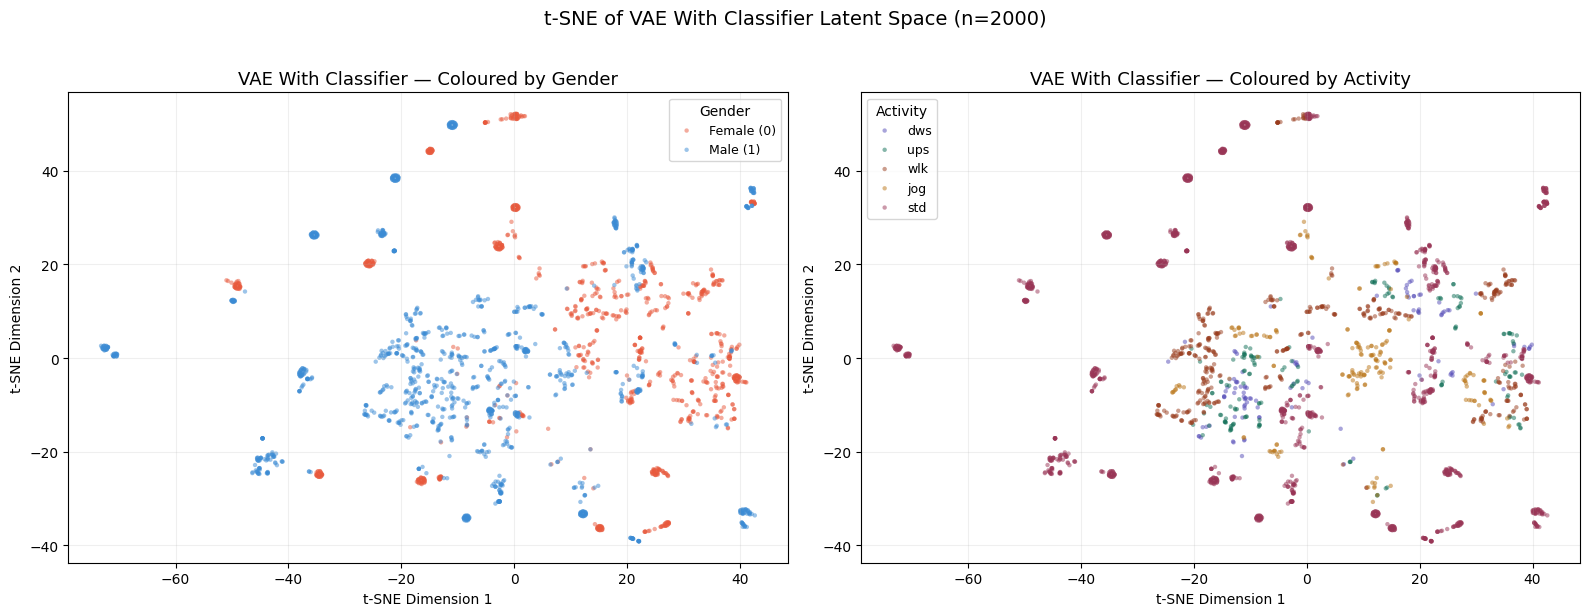

Saved as tsne_clf_latent_space.png


In [73]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

SAMPLE_SIZE = 2000
np.random.seed(42)

sample_indices  = np.random.choice(len(Z_test_clf_mu),
                                    size=SAMPLE_SIZE,
                                    replace=False)
Z_sample        = Z_test_clf_mu[sample_indices]
gender_sample   = test_df["gender"].values[sample_indices]
activity_sample = test_df["activity_merged"].values[sample_indices]

print(f"Running t-SNE on {SAMPLE_SIZE} samples...")
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
Z_2d = tsne.fit_transform(Z_sample)
print("t-SNE complete.")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

gender_colors = {0: '#E8593C', 1: '#3B8BD4'}
gender_labels = {0: 'Female (0)', 1: 'Male (1)'}

ax = axes[0]
for gender_val in [0, 1]:
    mask = gender_sample == gender_val
    ax.scatter(Z_2d[mask, 0], Z_2d[mask, 1],
               c=gender_colors[gender_val],
               label=gender_labels[gender_val],
               alpha=0.5, s=10, edgecolors='none')
ax.set_title("VAE With Classifier — Coloured by Gender", fontsize=13)
ax.set_xlabel("t-SNE Dimension 1")
ax.set_ylabel("t-SNE Dimension 2")
ax.legend(title="Gender", fontsize=9)
ax.grid(True, alpha=0.2)

activity_colors = {
    'dws': '#534AB7', 'ups': '#0F6E56',
    'wlk': '#993C1D', 'jog': '#BA7517', 'std': '#993556'
}

ax = axes[1]
for activity_val in activity_colors:
    mask = activity_sample == activity_val
    ax.scatter(Z_2d[mask, 0], Z_2d[mask, 1],
               c=activity_colors[activity_val],
               label=activity_val,
               alpha=0.5, s=10, edgecolors='none')
ax.set_title("VAE With Classifier — Coloured by Activity", fontsize=13)
ax.set_xlabel("t-SNE Dimension 1")
ax.set_ylabel("t-SNE Dimension 2")
ax.legend(title="Activity", fontsize=9)
ax.grid(True, alpha=0.2)

plt.suptitle("t-SNE of VAE With Classifier Latent Space (n=2000)",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("tsne_clf_latent_space.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved as tsne_clf_latent_space.png")

# H. PCA Baseline

The purpose of this section is to determine whether gender separability is an inherent property of the MotionSense sensor data, or whether the VAE's failure to separate gender is a problem with the model itself. PCA is chosen over a plain autoencoder for this diagnostic because it is a purely analytical method — it applies no learning, has no trainable parameters, and makes no architectural choices. It finds the directions of maximum variance in the data mathematically. If gender clusters remain overlapping in PCA space, that is strong evidence the signal is not present in the data. If they separate, the signal exists and the VAE is failing to capture it.
Two variants are run: multi-class (all 5 merged activities together) and binary (jogging vs non-jogging), because the binary variant reduces class overlap noise and gives gender the best chance to emerge if it exists. 

Multi-class (H.2): Uses all 5 activities together (dws, jog, std, ups, wlk). PCA is fitted on the full training set and the MLP classifier is trained to predict across all activities. The gender classifier is also trained on all activities together.
Binary (H.3): Still fits PCA on the full training set (same data, same components), but the activity label is simplified to jogging=1 vs everything else=0. The distance analysis in H.3a then zooms in on jogging samples only to measure male vs female separation specifically within that activity.

In [74]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier


y_train_act = train_df["activity_merged"].values
y_test_act  = test_df["activity_merged"].values

y_train_gen = train_df["gender"].values
y_test_gen  = test_df["gender"].values

print("Train size:", X_train_scaled.shape)
print("Test size: ", X_test_scaled.shape)
print("Activities:", sorted(np.unique(y_train_act)))
print("Gender classes:", sorted(np.unique(y_train_gen)))

Train size: (94941, 1536)
Test size:  (31373, 1536)
Activities: ['dws', 'jog', 'std', 'ups', 'wlk']
Gender classes: [np.int64(0), np.int64(1)]


In [75]:
N_COMPONENTS = 50

pca_multi = PCA(n_components=N_COMPONENTS, random_state=42)
Z_train_pca_multi = pca_multi.fit_transform(X_train_scaled)
Z_test_pca_multi  = pca_multi.transform(X_test_scaled)

print("── Multi-class PCA ───────────────────────────────────────────────")
print(f"Input dimension:  {X_train_scaled.shape[1]}")
print(f"Output dimension: {Z_train_pca_multi.shape[1]}")
print(f"Variance explained by {N_COMPONENTS} components: "
      f"{pca_multi.explained_variance_ratio_.sum():.4f}")

── Multi-class PCA ───────────────────────────────────────────────
Input dimension:  1536
Output dimension: 50
Variance explained by 50 components: 0.6985


In [76]:
activities = ['dws', 'jog', 'std', 'ups', 'wlk']

train_pca_df = train_df[["activity_merged", "gender"]].copy()
train_pca_df["z_pca"] = list(Z_train_pca_multi)

pca_multi_group_means = {}
for (activity, gender), group in train_pca_df.groupby(
        ["activity_merged", "gender"]):
    z_stack = np.stack(group["z_pca"].values)
    pca_multi_group_means[(activity, gender)] = z_stack.mean(axis=0)

overall_std_pca_multi = np.std(Z_train_pca_multi)

print("── Distance Between Gender Means — Multi-class PCA ───────────────")
print(f"{'Activity':<10} {'Distance':>12} {'Relative Distance':>20}")
print("-" * 45)

distances_pca_multi = {}
for activity in activities:
    male_mean   = pca_multi_group_means[(activity, 1)]
    female_mean = pca_multi_group_means[(activity, 0)]
    distance    = np.linalg.norm(male_mean - female_mean)
    distances_pca_multi[activity] = distance
    relative    = distance / overall_std_pca_multi
    print(f"{activity:<10} {distance:>12.4f} {relative:>20.4f}")

avg_dist_pca_multi = np.mean(list(distances_pca_multi.values()))
print("-" * 45)
print(f"{'Average':<10} {avg_dist_pca_multi:>12.4f}")
print(f"\nOverall PCA std: {overall_std_pca_multi:.4f}")
print("\nVAE reference — Fixed VAE avg relative distance: ~0.04–0.06")

── Distance Between Gender Means — Multi-class PCA ───────────────
Activity       Distance    Relative Distance
---------------------------------------------
dws              5.5671               1.2018
jog              5.7127               1.2333
std              7.4303               1.6041
ups             10.1552               2.1923
wlk              5.7443               1.2401
---------------------------------------------
Average          6.9219

Overall PCA std: 4.6322

VAE reference — Fixed VAE avg relative distance: ~0.04–0.06


In [77]:
pca_multi_act_clf = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=20,
                                   random_state=42)
pca_multi_act_clf.fit(Z_train_pca_multi, y_train_act)

pca_multi_gen_clf = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=20,
                                   random_state=42)
pca_multi_gen_clf.fit(Z_train_pca_multi, y_train_gen)

act_acc_pca_multi = accuracy_score(
    y_test_act, pca_multi_act_clf.predict(Z_test_pca_multi))
gen_acc_pca_multi = accuracy_score(
    y_test_gen, pca_multi_gen_clf.predict(Z_test_pca_multi))

print("── MLP on PCA Projection — Multi-class Results ───────────────────")
print(f"{'Version':<35} {'Activity':>10} {'Gender':>10}")
print("-" * 57)
print(f"{'Original (raw normalized)':<35} {'0.9464':>10} {'0.7331':>10}")
print(f"{'PCA Multi-class (50 components)':<35} "
      f"{act_acc_pca_multi:>10.4f} {gen_acc_pca_multi:>10.4f}")
print(f"{'Fixed VAE R\' Reconstructed':<35} {'0.9055':>10} {'0.6944':>10}")
print(f"{'Fixed VAE R\'\' Deterministic':<35} {'0.9217':>10} {'0.7225':>10}")

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


── MLP on PCA Projection — Multi-class Results ───────────────────
Version                               Activity     Gender
---------------------------------------------------------
Original (raw normalized)               0.9464     0.7331
PCA Multi-class (50 components)         0.9362     0.7492
Fixed VAE R' Reconstructed              0.9055     0.6944
Fixed VAE R'' Deterministic             0.9217     0.7225


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


In [78]:
y_train_binary = (y_train_act == 'jog').astype(int)
y_test_binary  = (y_test_act  == 'jog').astype(int)

print(f"Binary label counts — Train: jog={y_train_binary.sum()}, "
      f"non-jog={(y_train_binary==0).sum()}")
print(f"Binary label counts — Test:  jog={y_test_binary.sum()}, "
      f"non-jog={(y_test_binary==0).sum()}")

pca_binary = PCA(n_components=N_COMPONENTS, random_state=42)
Z_train_pca_binary = pca_binary.fit_transform(X_train_scaled)
Z_test_pca_binary  = pca_binary.transform(X_test_scaled)

print(f"\nVariance explained by {N_COMPONENTS} components: "
      f"{pca_binary.explained_variance_ratio_.sum():.4f}")

Binary label counts — Train: jog=9122, non-jog=85819
Binary label counts — Test:  jog=2696, non-jog=28677

Variance explained by 50 components: 0.6985


In [79]:
jog_mask_train = (y_train_act == 'jog')
Z_train_jog    = Z_train_pca_binary[jog_mask_train]
y_train_gen_jog = y_train_gen[jog_mask_train]

male_mean_jog   = Z_train_jog[y_train_gen_jog == 1].mean(axis=0)
female_mean_jog = Z_train_jog[y_train_gen_jog == 0].mean(axis=0)

distance_jog = np.linalg.norm(male_mean_jog - female_mean_jog)
overall_std_pca_binary = np.std(Z_train_pca_binary)
relative_jog = distance_jog / overall_std_pca_binary

print("── Distance Between Gender Means — Jogging Only (Binary PCA) ─────")
print(f"Distance (jogging male vs female):          {distance_jog:.4f}")
print(f"Overall PCA std:                            {overall_std_pca_binary:.4f}")
print(f"Relative distance:                          {relative_jog:.4f}")
print(f"\nFixed VAE jogging relative distance:        ~0.04–0.06")
print(f"VAE with clf jogging relative distance:     ~0.05–0.07")

── Distance Between Gender Means — Jogging Only (Binary PCA) ─────
Distance (jogging male vs female):          5.7127
Overall PCA std:                            4.6322
Relative distance:                          1.2333

Fixed VAE jogging relative distance:        ~0.04–0.06
VAE with clf jogging relative distance:     ~0.05–0.07


In [80]:
pca_binary_act_clf = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=20,
                                    random_state=42)
pca_binary_act_clf.fit(Z_train_pca_binary, y_train_binary)

pca_binary_gen_clf = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=20,
                                    random_state=42)
pca_binary_gen_clf.fit(Z_train_pca_binary, y_train_gen)

act_acc_pca_binary = accuracy_score(
    y_test_binary, pca_binary_act_clf.predict(Z_test_pca_binary))
gen_acc_pca_binary = accuracy_score(
    y_test_gen, pca_binary_gen_clf.predict(Z_test_pca_binary))

print("── MLP on PCA Projection — Binary Results ────────────────────────")
print(f"{'Version':<35} {'Activity':>10} {'Gender':>10}")
print("-" * 57)
print(f"{'Original (raw normalized)':<35} {'0.9464':>10} {'0.7331':>10}")
print(f"{'PCA Binary (50 components)':<35} "
      f"{act_acc_pca_binary:>10.4f} {gen_acc_pca_binary:>10.4f}")
print(f"{'Fixed VAE R\' Reconstructed':<35} {'0.9055':>10} {'0.6944':>10}")

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


── MLP on PCA Projection — Binary Results ────────────────────────
Version                               Activity     Gender
---------------------------------------------------------
Original (raw normalized)               0.9464     0.7331
PCA Binary (50 components)              0.9940     0.7492
Fixed VAE R' Reconstructed              0.9055     0.6944


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


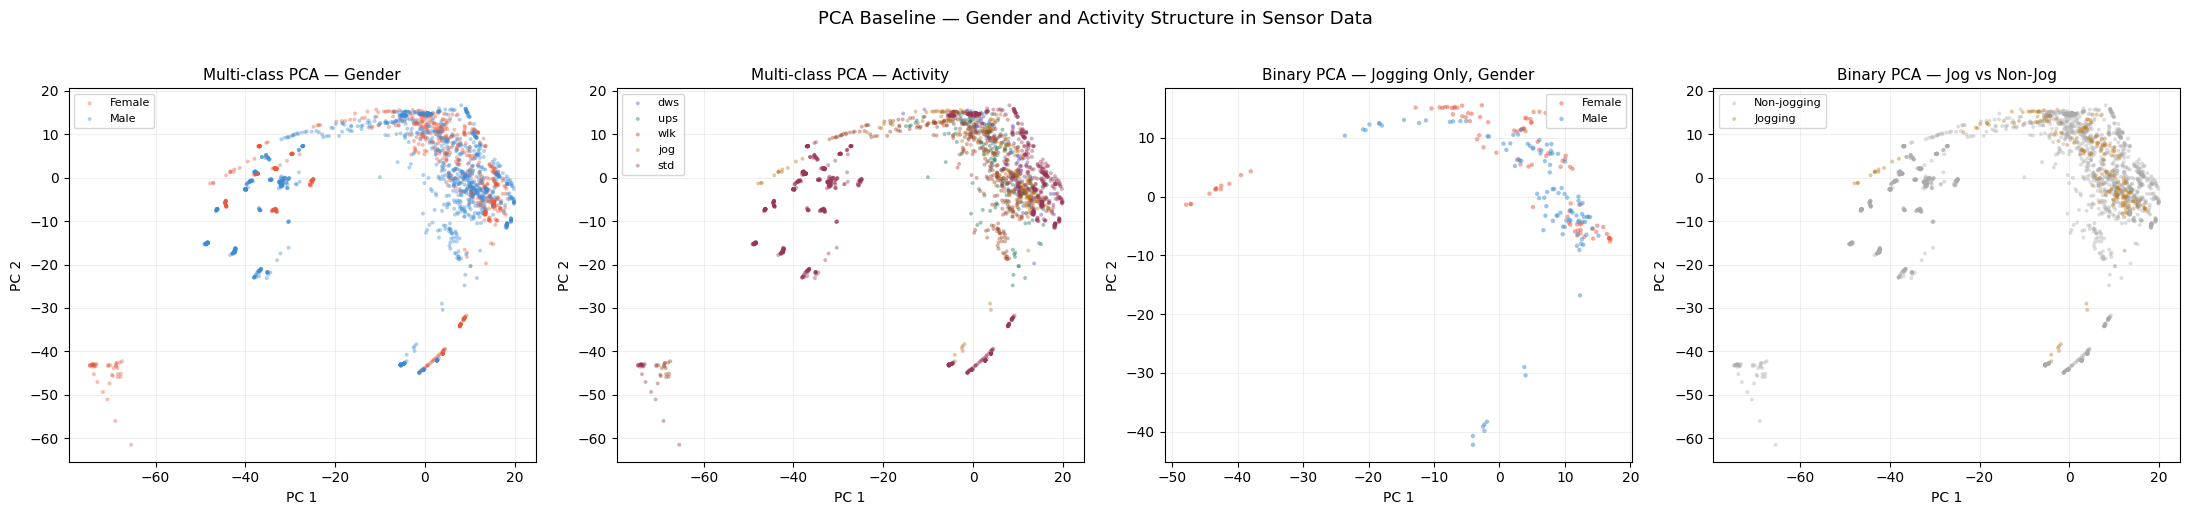

Plot saved as pca_baseline.png


In [81]:
SAMPLE_SIZE = 2000
np.random.seed(42)
sample_idx = np.random.choice(len(Z_test_pca_multi),
                               size=SAMPLE_SIZE, replace=False)

Z_plot_multi  = Z_test_pca_multi[sample_idx]
Z_plot_binary = Z_test_pca_binary[sample_idx]
gen_plot      = y_test_gen[sample_idx]
act_plot      = y_test_act[sample_idx]
bin_plot      = y_test_binary[sample_idx]

gender_colors   = {0: '#E8593C', 1: '#3B8BD4'}
gender_labels   = {0: 'Female', 1: 'Male'}
activity_colors = {
    'dws': '#534AB7', 'ups': '#0F6E56', 'wlk': '#993C1D',
    'jog': '#BA7517', 'std': '#993556'
}

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

ax = axes[0]
for g in [0, 1]:
    mask = gen_plot == g
    ax.scatter(Z_plot_multi[mask, 0], Z_plot_multi[mask, 1],
               c=gender_colors[g], label=gender_labels[g],
               alpha=0.4, s=8, edgecolors='none')
ax.set_title("Multi-class PCA — Gender", fontsize=11)
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)

ax = axes[1]
for activity in activity_colors:
    mask = act_plot == activity
    ax.scatter(Z_plot_multi[mask, 0], Z_plot_multi[mask, 1],
               c=activity_colors[activity], label=activity,
               alpha=0.4, s=8, edgecolors='none')
ax.set_title("Multi-class PCA — Activity", fontsize=11)
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)

ax = axes[2]
jog_mask_test = (y_test_act[sample_idx] == 'jog')
for g in [0, 1]:
    mask = (gen_plot == g) & jog_mask_test
    ax.scatter(Z_plot_binary[mask, 0], Z_plot_binary[mask, 1],
               c=gender_colors[g], label=gender_labels[g],
               alpha=0.5, s=10, edgecolors='none')
ax.set_title("Binary PCA — Jogging Only, Gender", fontsize=11)
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)

ax = axes[3]
binary_colors  = {0: '#AAAAAA', 1: '#BA7517'}
binary_labels  = {0: 'Non-jogging', 1: 'Jogging'}
for b in [0, 1]:
    mask = bin_plot == b
    ax.scatter(Z_plot_binary[mask, 0], Z_plot_binary[mask, 1],
               c=binary_colors[b], label=binary_labels[b],
               alpha=0.4, s=8, edgecolors='none')
ax.set_title("Binary PCA — Jog vs Non-Jog", fontsize=11)
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)

plt.suptitle("PCA Baseline — Gender and Activity Structure in Sensor Data",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("pca_baseline.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as pca_baseline.png")

In [82]:
print("── PCA Baseline Summary ──────────────────────────────────────────")
print(f"{'Version':<40} {'Activity':>10} {'Gender':>10}")
print("-" * 62)
print(f"{'Original R (raw normalized)':<40} {'0.9464':>10} {'0.7331':>10}")
print(f"{'PCA Multi-class (50 comp) — MLP on PCA':<40} "
      f"{act_acc_pca_multi:>10.4f} {gen_acc_pca_multi:>10.4f}")
print(f"{'PCA Binary jog/non-jog — MLP on PCA':<40} "
      f"{act_acc_pca_binary:>10.4f} {gen_acc_pca_binary:>10.4f}")
print(f"{'Fixed VAE R\' Reconstructed':<40} {'0.9055':>10} {'0.6944':>10}")
print(f"{'Fixed VAE R\'\' Deterministic':<40} {'0.9217':>10} {'0.7225':>10}")
print(f"{'VAE + clf loss R\' Reconstructed':<40} {'0.9062':>10} {'0.7290':>10}")
print(f"{'VAE + clf loss R\'\' Deterministic':<40} {'0.9058':>10} {'0.7274':>10}")
print()
print(f"PCA multi-class avg inter-cluster distance: "
      f"{avg_dist_pca_multi:.4f}")
print(f"PCA binary jogging inter-cluster distance:  "
      f"{distance_jog:.4f}")
print(f"Fixed VAE avg inter-cluster distance:       ~0.0528")
print(f"VAE + clf avg inter-cluster distance:       ~0.0640")

── PCA Baseline Summary ──────────────────────────────────────────
Version                                    Activity     Gender
--------------------------------------------------------------
Original R (raw normalized)                  0.9464     0.7331
PCA Multi-class (50 comp) — MLP on PCA       0.9362     0.7492
PCA Binary jog/non-jog — MLP on PCA          0.9940     0.7492
Fixed VAE R' Reconstructed                   0.9055     0.6944
Fixed VAE R'' Deterministic                  0.9217     0.7225
VAE + clf loss R' Reconstructed              0.9062     0.7290
VAE + clf loss R'' Deterministic             0.9058     0.7274

PCA multi-class avg inter-cluster distance: 6.9219
PCA binary jogging inter-cluster distance:  5.7127
Fixed VAE avg inter-cluster distance:       ~0.0528
VAE + clf avg inter-cluster distance:       ~0.0640


# I. Re-implementing VAE

In [83]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import copy
from sklearn.metrics import accuracy_score

In [84]:
class ActivityClassifier(nn.Module):
    def __init__(self, input_dim=1536, num_classes=5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512), nn.ReLU(),
            nn.Linear(512, 256),       nn.ReLU(),
            nn.Linear(256, 256),       nn.ReLU(),
            nn.Linear(256, 128),       nn.ReLU(),
            nn.Linear(128, 16),        nn.ReLU(),
            nn.Linear(16, num_classes)
        )

    def forward(self, x):
        return self.net(x)


class GenderClassifier(nn.Module):
    def __init__(self, input_dim=1536):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512), nn.ReLU(),
            nn.Linear(512, 256),       nn.ReLU(),
            nn.Linear(256, 256),       nn.ReLU(),
            nn.Linear(256, 128),       nn.ReLU(),
            nn.Linear(128, 16),        nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


print("Paper-faithful classifier architectures defined.")
print("Activity: 1536→512→256→256→128→16→5 (softmax via CrossEntropyLoss)")
print("Gender:   1536→512→256→256→128→16→1 (sigmoid)")

Paper-faithful classifier architectures defined.
Activity: 1536→512→256→256→128→16→5 (softmax via CrossEntropyLoss)
Gender:   1536→512→256→256→128→16→1 (sigmoid)


In [85]:
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import TensorDataset, DataLoader

le = LabelEncoder()
y_train_act_enc = le.fit_transform(train_df["activity_merged"].values)
y_val_act_enc   = le.transform(val_df["activity_merged"].values)
y_test_act_enc  = le.transform(test_df["activity_merged"].values)

print("Activity label encoding:", dict(zip(le.classes_,
      le.transform(le.classes_))))

y_train_gen_f = train_df["gender"].values.astype(np.float32)
y_val_gen_f   = val_df["gender"].values.astype(np.float32)
y_test_gen_f  = test_df["gender"].values.astype(np.float32)

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_t   = torch.tensor(X_val_scaled,   dtype=torch.float32)
X_test_t  = torch.tensor(X_test_scaled,  dtype=torch.float32)

y_train_act_t = torch.tensor(y_train_act_enc, dtype=torch.long)
y_val_act_t   = torch.tensor(y_val_act_enc,   dtype=torch.long)

y_train_gen_t = torch.tensor(y_train_gen_f, dtype=torch.float32)
y_val_gen_t   = torch.tensor(y_val_gen_f,   dtype=torch.float32)

BATCH_SIZE = 256
train_act_loader = DataLoader(
    TensorDataset(X_train_t, y_train_act_t),
    batch_size=BATCH_SIZE, shuffle=True)
train_gen_loader = DataLoader(
    TensorDataset(X_train_t, y_train_gen_t),
    batch_size=BATCH_SIZE, shuffle=True)

print(f"Train batches: {len(train_act_loader)}")

Activity label encoding: {'dws': np.int64(0), 'jog': np.int64(1), 'std': np.int64(2), 'ups': np.int64(3), 'wlk': np.int64(4)}
Train batches: 371


In [86]:
NUM_EPOCHS_CLF = 50

act_clf_paper = ActivityClassifier(input_dim=1536, num_classes=5).to(device)
act_optimizer = optim.Adam(act_clf_paper.parameters(), lr=1e-3)
act_criterion = nn.CrossEntropyLoss()

print("Training activity classifier...")
for epoch in range(NUM_EPOCHS_CLF):
    act_clf_paper.train()
    for (x_batch, y_batch) in train_act_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        act_optimizer.zero_grad()
        loss = act_criterion(act_clf_paper(x_batch), y_batch)
        loss.backward()
        act_optimizer.step()

    if (epoch + 1) % 10 == 0:
        act_clf_paper.eval()
        with torch.no_grad():
            train_preds = act_clf_paper(X_train_t.to(device)).argmax(dim=1)
            train_acc   = (train_preds.cpu() == y_train_act_t).float().mean()
        print(f"  Epoch {epoch+1:02d} | Train Activity Acc: {train_acc:.4f}")

act_clf_paper.eval()
with torch.no_grad():
    train_preds = act_clf_paper(X_train_t.to(device)).argmax(dim=1).cpu()
    test_preds  = act_clf_paper(X_test_t.to(device)).argmax(dim=1).cpu()
print(f"\nFinal Train Activity Acc: {(train_preds == y_train_act_t).float().mean():.4f}")
print(f"Final Test  Activity Acc: {accuracy_score(y_test_act_enc, test_preds.numpy()):.4f}")
print("Paper reports: ~99% train, ~96% test")

Training activity classifier...
  Epoch 10 | Train Activity Acc: 0.9936
  Epoch 20 | Train Activity Acc: 0.9993
  Epoch 30 | Train Activity Acc: 0.9989
  Epoch 40 | Train Activity Acc: 0.9991
  Epoch 50 | Train Activity Acc: 0.9999

Final Train Activity Acc: 0.9999
Final Test  Activity Acc: 0.9649
Paper reports: ~99% train, ~96% test


In [87]:
gen_clf_paper = GenderClassifier(input_dim=1536).to(device)
gen_optimizer = optim.Adam(gen_clf_paper.parameters(), lr=1e-3)
gen_criterion = nn.BCELoss()

train_gen_loader = DataLoader(
    TensorDataset(X_train_t, y_train_gen_t),
    batch_size=BATCH_SIZE, shuffle=True)

print("Training gender classifier...")
for epoch in range(NUM_EPOCHS_CLF):
    gen_clf_paper.train()
    for (x_batch, y_batch) in train_gen_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device).unsqueeze(1)
        gen_optimizer.zero_grad()
        loss = gen_criterion(gen_clf_paper(x_batch), y_batch)
        loss.backward()
        gen_optimizer.step()

    if (epoch + 1) % 10 == 0:
        gen_clf_paper.eval()
        with torch.no_grad():
            train_probs = gen_clf_paper(X_train_t.to(device)).squeeze()
            train_preds = (train_probs > 0.5).long().cpu()
            train_acc   = (train_preds == y_train_gen_t.long()).float().mean()
        print(f"  Epoch {epoch+1:02d} | Train Gender Acc: {train_acc:.4f}")

gen_clf_paper.eval()
with torch.no_grad():
    train_probs = gen_clf_paper(X_train_t.to(device)).squeeze().cpu()
    test_probs  = gen_clf_paper(X_test_t.to(device)).squeeze().cpu()
train_preds = (train_probs > 0.5).long()
test_preds  = (test_probs  > 0.5).long()
print(f"\nFinal Train Gender Acc: {(train_preds == y_train_gen_t.long()).float().mean():.4f}")
print(f"Final Test  Gender Acc: {accuracy_score(y_test_gen_f.astype(int), test_preds.numpy()):.4f}")
print("Paper reports: 88.52% train")

Training gender classifier...
  Epoch 10 | Train Gender Acc: 0.9914
  Epoch 20 | Train Gender Acc: 0.9990
  Epoch 30 | Train Gender Acc: 0.9996
  Epoch 40 | Train Gender Acc: 0.9996
  Epoch 50 | Train Gender Acc: 1.0000

Final Train Gender Acc: 1.0000
Final Test  Gender Acc: 0.6977
Paper reports: 88.52% train


In [88]:
class VAE_Paper(nn.Module):
    def __init__(self, input_dim=1536, latent_dim=10):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 4096), nn.ReLU(),
            nn.Linear(4096, 2048),      nn.ReLU(),
            nn.Linear(2048, 1024),      nn.ReLU(),
            nn.Linear(1024, 512),       nn.ReLU(),
            nn.Linear(512, 256),        nn.ReLU(),
            nn.Linear(256, 128),        nn.ReLU()
        )
        self.fc_mu     = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(),
            nn.Linear(128, 256),        nn.ReLU(),
            nn.Linear(256, 512),        nn.ReLU(),
            nn.Linear(512, 1024),       nn.ReLU(),
            nn.Linear(1024, 2048),      nn.ReLU(),
            nn.Linear(2048, 4096),      nn.ReLU(),
            nn.Linear(4096, input_dim)
        )

    def encode(self, x):
        h      = self.encoder(x)
        mu     = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z          = self.reparameterize(mu, logvar)
        x_recon    = self.decode(z)
        return x_recon, mu, logvar


def vae_loss_paper(x_recon, x, mu, logvar, beta=0.001):
    recon_loss = F.mse_loss(x_recon, x, reduction="mean")
    kl_loss    = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kl_loss, recon_loss, kl_loss


print("Paper-faithful VAE defined.")
print("Architecture: 1536→4096→2048→1024→512→256→128→10")
print("Loss: standard VAE (recon + KL, no beta weighting)")

Paper-faithful VAE defined.
Architecture: 1536→4096→2048→1024→512→256→128→10
Loss: standard VAE (recon + KL, no beta weighting)


In [89]:
vae_paper = VAE_Paper(input_dim=1536, latent_dim=10).to(device)
optimizer_vae = optim.Adam(vae_paper.parameters(), lr=1e-4)
scheduler_vae = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer_vae, patience=5, factor=0.5)

NUM_EPOCHS_VAE = 100
best_val_loss  = float("inf")
best_state     = None


print("Training paper-faithful VAE...")
print(f"{'Epoch':<8} {'Train Loss':>12} {'Val Loss':>12} "
      f"{'Train Recon':>14} {'Train KL':>12}")
print("-" * 62)

for epoch in range(NUM_EPOCHS_VAE):
    vae_paper.train()
    train_total = train_recon = train_kl = 0.0

    for (x_batch,) in train_loader:
        x_batch = x_batch.to(device)
        optimizer_vae.zero_grad()
        x_recon, mu, logvar = vae_paper(x_batch)
        loss, recon, kl = vae_loss_paper(x_recon, x_batch, mu, logvar)
        loss.backward()
        optimizer_vae.step()
        n = x_batch.size(0)
        train_total += loss.item()  * n
        train_recon += recon.item() * n
        train_kl    += kl.item()    * n

    N = len(train_loader.dataset)
    train_total /= N
    train_recon /= N
    train_kl    /= N

    vae_paper.eval()
    val_total = 0.0
    with torch.no_grad():
        for (x_batch,) in val_loader:
            x_batch = x_batch.to(device)
            x_recon, mu, logvar = vae_paper(x_batch)
            loss, _, _          = vae_loss_paper(x_recon, x_batch, mu, logvar)
            val_total += loss.item() * x_batch.size(0)
    val_total /= len(val_loader.dataset)

    scheduler_vae.step(val_total)

    if val_total < best_val_loss:
        best_val_loss = val_total
        best_state    = copy.deepcopy(vae_paper.state_dict())

    if (epoch + 1) % 10 == 0:
        print(f"{epoch+1:<8} {train_total:>12.6f} {val_total:>12.6f} "
              f"{train_recon:>14.6f} {train_kl:>12.6f}")

vae_paper.load_state_dict(best_state)
torch.save(best_state, "best_vae_paper.pth")
print(f"\nBest validation loss: {best_val_loss:.6f}")
print("Saved to best_vae_paper.pth")

Training paper-faithful VAE...
Epoch      Train Loss     Val Loss    Train Recon     Train KL
--------------------------------------------------------------
10           0.350473     0.352662       0.346391     4.081848
20           0.283576     0.295801       0.279534     4.041391
30           0.254112     0.273262       0.250180     3.932314
40           0.236374     0.261223       0.232505     3.868371
50           0.223647     0.252715       0.219823     3.824441
60           0.213790     0.247060       0.209981     3.809595
70           0.205270     0.241639       0.201461     3.809483
80           0.198014     0.238748       0.194204     3.809779
90           0.191782     0.235549       0.187978     3.804672
100          0.186129     0.233452       0.182336     3.792849

Best validation loss: 0.233452
Saved to best_vae_paper.pth


In [90]:
def encode_dataset_paper(model, loader, device):
    model.eval()
    all_mu = []
    with torch.no_grad():
        for (x_batch,) in loader:
            mu, _ = model.encode(x_batch.to(device))
            all_mu.append(mu.cpu())
    return torch.cat(all_mu, dim=0).numpy()

def decode_latent_paper(model, Z, device):
    model.eval()
    with torch.no_grad():
        out = model.decode(torch.tensor(Z, dtype=torch.float32).to(device))
    return out.cpu().numpy()

Z_test_paper_mu  = encode_dataset_paper(vae_paper, test_loader, device)
X_test_paper_recon = decode_latent_paper(vae_paper, Z_test_paper_mu, device)

act_clf_paper.eval()
gen_clf_paper.eval()
with torch.no_grad():
    act_preds_recon = act_clf_paper(
        torch.tensor(X_test_paper_recon, dtype=torch.float32).to(device)
    ).argmax(dim=1).cpu().numpy()
    gen_probs_recon = gen_clf_paper(
        torch.tensor(X_test_paper_recon, dtype=torch.float32).to(device)
    ).squeeze().cpu().numpy()

gen_preds_recon = (gen_probs_recon > 0.5).astype(int)

print("── Paper VAE Reconstruction Check (R') ──────────────────────────")
print(f"{'Version':<35} {'Activity':>10} {'Gender':>10}")
print("-" * 57)
print(f"{'R  — Original':<35} "
      f"{accuracy_score(y_test_act_enc, test_preds.numpy()):>10.4f} "
      f"{accuracy_score(y_test_gen_f.astype(int), (test_probs>0.5).numpy().astype(int)):>10.4f}")
print(f"{'R\' — Paper VAE Reconstructed':<35} "
      f"{accuracy_score(y_test_act_enc, act_preds_recon):>10.4f} "
      f"{accuracy_score(y_test_gen_f.astype(int), gen_preds_recon):>10.4f}")
print(f"{'R\' — Fixed VAE (prev attempt)':<35} {'0.9055':>10} {'0.6944':>10}")
print("\nPaper Figure 5 reference (jogging only shown): ~89–98% activity")
print("Paper Figure 6 reference (jogging only shown): ~77–90% gender")

── Paper VAE Reconstruction Check (R') ──────────────────────────
Version                               Activity     Gender
---------------------------------------------------------
R  — Original                           0.0731     0.6977
R' — Paper VAE Reconstructed            0.9205     0.6837
R' — Fixed VAE (prev attempt)           0.9055     0.6944

Paper Figure 5 reference (jogging only shown): ~89–98% activity
Paper Figure 6 reference (jogging only shown): ~77–90% gender


In [91]:
Z_train_paper_mu = encode_dataset_paper(vae_paper, train_loader, device)
train_df["z_mu_paper"] = list(Z_train_paper_mu)

paper_group_means = {}
for (activity, gender), group in train_df.groupby(
        ["activity_merged", "gender"]):
    z_stack = np.stack(group["z_mu_paper"].values)
    paper_group_means[(activity, gender)] = z_stack.mean(axis=0)

print("Group means computed:", len(paper_group_means), "groups")

test_df["z_mu_paper"] = list(Z_test_paper_mu)

act_clf_paper.eval()
gen_clf_paper.eval()
with torch.no_grad():
    act_pred_test = act_clf_paper(
        X_test_t.to(device)).argmax(dim=1).cpu().numpy()
    gen_pred_test = (gen_clf_paper(
        X_test_t.to(device)).squeeze().cpu().numpy() > 0.5).astype(int)

act_pred_test_str = le.inverse_transform(act_pred_test)

print(f"Predicted activity distribution: "
      f"{dict(zip(*np.unique(act_pred_test_str, return_counts=True)))}")
print(f"Predicted gender distribution: "
      f"0={( gen_pred_test==0).sum()}, 1={(gen_pred_test==1).sum()}")

Group means computed: 10 groups
Predicted activity distribution: {'dws': np.int64(2658), 'jog': np.int64(2551), 'std': np.int64(17641), 'ups': np.int64(2633), 'wlk': np.int64(5890)}
Predicted gender distribution: 0=10779, 1=20594


In [92]:
EXCLUDED_ACTIVITIES = ['std']

Z_test_paper_det = []
skipped = 0

for i, row in enumerate(test_df.itertuples()):
    z            = test_df.iloc[i]["z_mu_paper"]
    pred_activity = act_pred_test_str[i]
    pred_gender   = int(gen_pred_test[i])

    if pred_activity in EXCLUDED_ACTIVITIES:
        Z_test_paper_det.append(z.copy())
        skipped += 1
        continue

    if (pred_activity, pred_gender) not in paper_group_means or \
       (pred_activity, 1 - pred_gender) not in paper_group_means:
        Z_test_paper_det.append(z.copy())
        skipped += 1
        continue

    original_mean = paper_group_means[(pred_activity, pred_gender)]
    target_mean   = paper_group_means[(pred_activity, 1 - pred_gender)]
    z_new         = z - original_mean + target_mean
    Z_test_paper_det.append(z_new)

Z_test_paper_det = np.stack(Z_test_paper_det)
print(f"Deterministic manipulation complete.")
print(f"Samples manipulated: {len(Z_test_paper_det) - skipped}")
print(f"Samples skipped (std or missing key): {skipped}")

X_test_paper_det = decode_latent_paper(vae_paper, Z_test_paper_det, device)
print(f"Decoded shape: {X_test_paper_det.shape}")
print(f"NaNs: {np.isnan(X_test_paper_det).any()}")

Deterministic manipulation complete.
Samples manipulated: 13732
Samples skipped (std or missing key): 17641
Decoded shape: (31373, 1536)
NaNs: False


In [93]:
Z_test_paper_prob = []

for i, row in enumerate(test_df.itertuples()):
    z             = test_df.iloc[i]["z_mu_paper"]
    pred_activity = act_pred_test_str[i]
    pred_gender   = int(gen_pred_test[i])

    if pred_activity in EXCLUDED_ACTIVITIES:
        Z_test_paper_prob.append(z.copy())
        continue

    if (pred_activity, pred_gender) not in paper_group_means or \
       (pred_activity, 1 - pred_gender) not in paper_group_means:
        Z_test_paper_prob.append(z.copy())
        continue

    if np.random.rand() < 0.5:
        original_mean = paper_group_means[(pred_activity, pred_gender)]
        target_mean   = paper_group_means[(pred_activity, 1 - pred_gender)]
        z_new         = z - original_mean + target_mean
    else:
        z_new = z.copy()

    Z_test_paper_prob.append(z_new)

Z_test_paper_prob = np.stack(Z_test_paper_prob)
X_test_paper_prob = decode_latent_paper(vae_paper, Z_test_paper_prob, device)

changed = np.sum(np.linalg.norm(
    Z_test_paper_prob - Z_test_paper_mu, axis=1) > 1e-6)
print(f"Probabilistic: {changed} samples swapped ({changed/len(Z_test_paper_prob)*100:.1f}%)")

Probabilistic: 6883 samples swapped (21.9%)


In [94]:
def evaluate_paper(X, name):
    act_clf_paper.eval()
    gen_clf_paper.eval()
    X_t = torch.tensor(X, dtype=torch.float32)
    with torch.no_grad():
        act_preds = act_clf_paper(
            X_t.to(device)).argmax(dim=1).cpu().numpy()
        gen_probs = gen_clf_paper(
            X_t.to(device)).squeeze().cpu().numpy()
    gen_preds = (gen_probs > 0.5).astype(int)
    y_true_act = le.transform(test_df["activity_merged"].values)
    y_true_gen = test_df["gender"].values.astype(int)
    act_acc = accuracy_score(y_true_act, act_preds)
    gen_acc = accuracy_score(y_true_gen, gen_preds)
    print(f"{name:<40} {act_acc:>10.4f} {gen_acc:>10.4f}")
    return act_acc, gen_acc

print("── Paper-faithful Pipeline Results ───────────────────────────────")
print(f"{'Version':<40} {'Activity':>10} {'Gender':>10}")
print("-" * 62)

evaluate_paper(X_test_scaled,         "R  — Original")
evaluate_paper(X_test_paper_recon,    "R\' — Paper VAE Reconstructed")
evaluate_paper(X_test_paper_det,      "R\'\'— Paper VAE Deterministic")
evaluate_paper(X_test_paper_prob,     "R\'\'— Paper VAE Probabilistic")

print("\nPaper reference results (Figures 9 & 10, averaged):")
print(f"{'Original':<40} {'~96.4%':>10} {'~93.13%':>10}")
print(f"{'Deterministic':<40} {'~84.98%':>10} {'~39.62%':>10}")

print("\nPrevious attempt reference:")
print(f"{'Fixed VAE R\' Reconstructed':<40} {'0.9055':>10} {'0.6944':>10}")
print(f"{'Fixed VAE R\'\' Deterministic':<40} {'0.9217':>10} {'0.7225':>10}")

── Paper-faithful Pipeline Results ───────────────────────────────
Version                                    Activity     Gender
--------------------------------------------------------------
R  — Original                                0.9649     0.6977
R' — Paper VAE Reconstructed                 0.9205     0.6837
R''— Paper VAE Deterministic                 0.9203     0.6841
R''— Paper VAE Probabilistic                 0.9205     0.6838

Paper reference results (Figures 9 & 10, averaged):
Original                                     ~96.4%    ~93.13%
Deterministic                               ~84.98%    ~39.62%

Previous attempt reference:
Fixed VAE R' Reconstructed                   0.9055     0.6944
Fixed VAE R'' Deterministic                  0.9217     0.7225


In [95]:
activities_no_std = ['dws', 'jog', 'ups', 'wlk']

overall_std_paper = np.std(Z_train_paper_mu)

print("── Distance Between Gender Means — Paper VAE ─────────────────────")
print(f"{'Activity':<10} {'Distance':>12} {'Relative Distance':>20}")
print("-" * 45)

distances_paper = {}
for activity in activities_no_std:
    male_mean   = paper_group_means[(activity, 1)]
    female_mean = paper_group_means[(activity, 0)]
    distance    = np.linalg.norm(male_mean - female_mean)
    distances_paper[activity] = distance
    print(f"{activity:<10} {distance:>12.4f} "
          f"{distance/overall_std_paper:>20.4f}")

avg_dist_paper = np.mean(list(distances_paper.values()))
print("-" * 45)
print(f"{'Average':<10} {avg_dist_paper:>12.4f} "
      f"{avg_dist_paper/overall_std_paper:>20.4f}")
print(f"\nOverall latent std: {overall_std_paper:.4f}")
print(f"\nComparison:")
print(f"  PCA relative distance:          ~1.2–2.2")
print(f"  Fixed VAE relative distance:    ~0.04–0.06")
print(f"  VAE+clf relative distance:      ~0.05–0.07")
print(f"  Paper VAE relative distance:    (above)")

── Distance Between Gender Means — Paper VAE ─────────────────────
Activity       Distance    Relative Distance
---------------------------------------------
dws              0.0834               0.0634
jog              0.0685               0.0521
ups              0.0460               0.0350
wlk              0.0421               0.0321
---------------------------------------------
Average          0.0600               0.0456

Overall latent std: 1.3145

Comparison:
  PCA relative distance:          ~1.2–2.2
  Fixed VAE relative distance:    ~0.04–0.06
  VAE+clf relative distance:      ~0.05–0.07
  Paper VAE relative distance:    (above)


In [96]:
true_dist = dict(zip(*np.unique(
    test_df["activity_merged"].values, return_counts=True)))
pred_dist = dict(zip(*np.unique(
    act_pred_test_str, return_counts=True)))
print("True distribution:", true_dist)
print("Pred distribution:", pred_dist)

True distribution: {'dws': np.int64(1955), 'jog': np.int64(2696), 'std': np.int64(17985), 'ups': np.int64(2505), 'wlk': np.int64(6232)}
Pred distribution: {'dws': np.int64(2658), 'jog': np.int64(2551), 'std': np.int64(17641), 'ups': np.int64(2633), 'wlk': np.int64(5890)}


# J. Activity-Specific VAE (Jogging)

In [97]:
sample_path = manifest_df.loc[0, "file_path"]
sample_df   = pd.read_csv(sample_path)
if "Unnamed: 0" in sample_df.columns:
    sample_df = sample_df.drop(columns=["Unnamed: 0"])
print("Column names:", sample_df.columns.tolist())
print("Number of features:", len(sample_df.columns))
print("Sample values (first row):")
print(sample_df.iloc[0])

Column names: ['attitude.roll', 'attitude.pitch', 'attitude.yaw', 'gravity.x', 'gravity.y', 'gravity.z', 'rotationRate.x', 'rotationRate.y', 'rotationRate.z', 'userAcceleration.x', 'userAcceleration.y', 'userAcceleration.z']
Number of features: 12
Sample values (first row):
attitude.roll         1.528132
attitude.pitch       -0.733896
attitude.yaw          0.696372
gravity.x             0.741895
gravity.y             0.669768
gravity.z            -0.031672
rotationRate.x        0.316738
rotationRate.y        0.778180
rotationRate.z        1.082764
userAcceleration.x    0.294894
userAcceleration.y   -0.184493
userAcceleration.z    0.377542
Name: 0, dtype: float64


In [98]:
jog_train = train_df[train_df["activity_merged"] == "jog"]
jog_test  = test_df[test_df["activity_merged"]  == "jog"]

print("Jogging train windows:", len(jog_train))
print("Jogging test windows: ", len(jog_test))
print("\nTrain gender distribution:")
print(jog_train["gender"].value_counts())
print("\nTest gender distribution:")
print(jog_test["gender"].value_counts())
print("\nTrain subjects:", sorted(jog_train["subject"].unique()))
print("Test subjects: ", sorted(jog_test["subject"].unique()))

Jogging train windows: 9122
Jogging test windows:  2696

Train gender distribution:
gender
1    5269
0    3853
Name: count, dtype: int64

Test gender distribution:
gender
1    1535
0    1161
Name: count, dtype: int64

Train subjects: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
Test subjects:  [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]


In [99]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import copy
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

In [100]:
def extract_2channel(window_raw):
    """
    Takes a raw (128, 12) window and extracts 2-channel representation.
    Returns a flattened (256,) vector of accel_mag and gyro_mag.
    window_raw: numpy array of shape (128, 12), raw unscaled sensor values
    """
    accel = window_raw[:, 9:12]
    gyro  = window_raw[:, 6:9]

    accel_mag = np.sqrt((accel ** 2).sum(axis=1))
    gyro_mag  = np.sqrt((gyro  ** 2).sum(axis=1))

    two_channel = np.stack([accel_mag, gyro_mag], axis=1)
    return two_channel.reshape(-1).astype(np.float32)

sample_window_raw = train_df.iloc[0]["window"]
sample_2ch = extract_2channel(sample_window_raw)
print("2-channel input shape:", sample_2ch.shape)
print("Expected: (256,)")
print("First 10 values (accel mag for first 5 steps, gyro mag for first 5):")
print(sample_2ch[:10])

2-channel input shape: (256,)
Expected: (256,)
First 10 values (accel mag for first 5 steps, gyro mag for first 5):
[0.8340187  1.0265028  1.3401512  0.29894525 2.0627468  1.161753
 1.5551548  2.623663   2.6149762  1.4640074 ]


In [101]:
jog_train_df = train_df[train_df["activity_merged"] == "jog"].copy()
jog_val_df   = val_df[val_df["activity_merged"]     == "jog"].copy()
jog_test_df  = test_df[test_df["activity_merged"]   == "jog"].copy()

print(f"Jogging windows — Train: {len(jog_train_df)}, "
      f"Val: {len(jog_val_df)}, Test: {len(jog_test_df)}")

X_jog_train_2ch = np.stack([
    extract_2channel(w) for w in jog_train_df["window"].values])
X_jog_val_2ch   = np.stack([
    extract_2channel(w) for w in jog_val_df["window"].values])
X_jog_test_2ch  = np.stack([
    extract_2channel(w) for w in jog_test_df["window"].values])

print(f"2-channel shapes — Train: {X_jog_train_2ch.shape}, "
      f"Val: {X_jog_val_2ch.shape}, Test: {X_jog_test_2ch.shape}")

scaler_jog = StandardScaler()
X_jog_train_scaled = scaler_jog.fit_transform(X_jog_train_2ch)
X_jog_val_scaled   = scaler_jog.transform(X_jog_val_2ch)
X_jog_test_scaled  = scaler_jog.transform(X_jog_test_2ch)

print(f"\nScaled train mean (first 5): "
      f"{X_jog_train_scaled.mean(axis=0)[:5]}")
print(f"Scaled train std  (first 5): "
      f"{X_jog_train_scaled.std(axis=0)[:5]}")

y_jog_train_gen = jog_train_df["gender"].values.astype(np.int64)
y_jog_val_gen   = jog_val_df["gender"].values.astype(np.int64)
y_jog_test_gen  = jog_test_df["gender"].values.astype(np.int64)

print(f"\nGender distribution — Train: "
      f"0={( y_jog_train_gen==0).sum()}, "
      f"1={(y_jog_train_gen==1).sum()}")
print(f"Gender distribution — Test:  "
      f"0={( y_jog_test_gen==0).sum()}, "
      f"1={(y_jog_test_gen==1).sum()}")

Jogging windows — Train: 9122, Val: 1013, Test: 2696
2-channel shapes — Train: (9122, 256), Val: (1013, 256), Test: (2696, 256)

Scaled train mean (first 5): [ 1.5363453e-08  3.0671366e-08 -5.3972196e-09 -1.0167160e-08
  1.8753050e-09]
Scaled train std  (first 5): [0.999999  1.0000002 0.9999996 0.9999999 1.0000002]

Gender distribution — Train: 0=3853, 1=5269
Gender distribution — Test:  0=1161, 1=1535


In [102]:
BATCH_SIZE_JOG = 128
INPUT_DIM_JOG  = 256
LATENT_DIM_JOG = 10

X_jog_train_t = torch.tensor(X_jog_train_scaled, dtype=torch.float32)
X_jog_val_t   = torch.tensor(X_jog_val_scaled,   dtype=torch.float32)
X_jog_test_t  = torch.tensor(X_jog_test_scaled,  dtype=torch.float32)

y_jog_train_t = torch.tensor(y_jog_train_gen, dtype=torch.long)
y_jog_test_t  = torch.tensor(y_jog_test_gen,  dtype=torch.long)

jog_train_vae_loader = DataLoader(
    TensorDataset(X_jog_train_t),
    batch_size=BATCH_SIZE_JOG, shuffle=True)

jog_val_loader = DataLoader(
    TensorDataset(X_jog_val_t),
    batch_size=BATCH_SIZE_JOG, shuffle=False)

jog_test_loader = DataLoader(
    TensorDataset(X_jog_test_t),
    batch_size=BATCH_SIZE_JOG, shuffle=False)

jog_train_clf_loader = DataLoader(
    TensorDataset(X_jog_train_t, y_jog_train_t),
    batch_size=BATCH_SIZE_JOG, shuffle=True)

print(f"Train batches (VAE):  {len(jog_train_vae_loader)}")
print(f"Train batches (CLF):  {len(jog_train_clf_loader)}")
print(f"Val batches:          {len(jog_val_loader)}")
print(f"Test batches:         {len(jog_test_loader)}")

Train batches (VAE):  72
Train batches (CLF):  72
Val batches:          8
Test batches:         22


In [103]:
ALPHA_JOG = 2.0
BETA_JOG  = 2.0

class VAE_Jogging(nn.Module):
    def __init__(self, input_dim=256, latent_dim=10,
                 num_gender_classes=2):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512), nn.ReLU(),
            nn.Linear(512, 256),       nn.ReLU(),
            nn.Linear(256, 128),       nn.ReLU()
        )

        self.fc_mu     = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(),
            nn.Linear(128, 256),        nn.ReLU(),
            nn.Linear(256, 512),        nn.ReLU(),
            nn.Linear(512, input_dim)
        )

        self.classifier = nn.Linear(latent_dim, num_gender_classes)

    def encode(self, x):
        h      = self.encoder(x)
        mu     = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar    = self.encode(x)
        z             = self.reparameterize(mu, logvar)
        x_recon       = self.decode(z)
        gender_logits = self.classifier(mu)
        return x_recon, mu, logvar, gender_logits


def vae_loss_jogging(x_recon, x, mu, logvar,
                     gender_logits, gender_labels,
                     alpha=ALPHA_JOG, beta=BETA_JOG):
    """
    Equation 2 from 2021 paper:
    L = recon_loss + β × KL_loss + α × clf_loss

    recon_loss: MSE between reconstructed and original window
    KL_loss:    KL divergence between learned posterior and N(0,1)
    clf_loss:   cross-entropy between predicted and true gender class
    alpha=2, beta=2 from Section 6.2 grid search for MotionSense
    """
    recon_loss = F.mse_loss(x_recon, x, reduction="mean")
    kl_loss    = -0.5 * torch.mean(
                     1 + logvar - mu.pow(2) - logvar.exp())
    clf_loss   = F.cross_entropy(gender_logits, gender_labels)
    total      = recon_loss + beta * kl_loss + alpha * clf_loss
    return total, recon_loss, kl_loss, clf_loss


print("Jogging VAE defined.")
print(f"Architecture: {INPUT_DIM_JOG}→512→256→128→{LATENT_DIM_JOG}"
      f"→128→256→512→{INPUT_DIM_JOG}")
print(f"Loss: recon + {BETA_JOG}×KL + {ALPHA_JOG}×clf")
print(f"Classification layer: {LATENT_DIM_JOG}→2 (gender)")

Jogging VAE defined.
Architecture: 256→512→256→128→10→128→256→512→256
Loss: recon + 2.0×KL + 2.0×clf
Classification layer: 10→2 (gender)


In [104]:
NUM_EPOCHS_JOG = 100

vae_jog   = VAE_Jogging(input_dim=INPUT_DIM_JOG,
                         latent_dim=LATENT_DIM_JOG,
                         num_gender_classes=2).to(device)
opt_jog   = optim.Adam(vae_jog.parameters(), lr=1e-3)
sched_jog = torch.optim.lr_scheduler.ReduceLROnPlateau(
            opt_jog, patience=10, factor=0.5)

best_val_jog   = float("inf")
best_state_jog = None

print("Training jogging VAE...")
print(f"{'Epoch':<8} {'Train Loss':>12} {'Val Loss':>12} "
      f"{'Recon':>10} {'KL':>10} {'Clf':>10}")
print("-" * 66)

for epoch in range(NUM_EPOCHS_JOG):
    vae_jog.train()
    t_total = t_recon = t_kl = t_clf = 0.0

    for (x_batch, g_batch) in jog_train_clf_loader:
        x_batch = x_batch.to(device)
        g_batch = g_batch.to(device)
        opt_jog.zero_grad()
        x_recon, mu, logvar, g_logits = vae_jog(x_batch)
        loss, recon, kl, clf = vae_loss_jogging(
            x_recon, x_batch, mu, logvar, g_logits, g_batch)
        loss.backward()
        opt_jog.step()
        n        = x_batch.size(0)
        t_total += loss.item()  * n
        t_recon += recon.item() * n
        t_kl    += kl.item()    * n
        t_clf   += clf.item()   * n

    N          = len(jog_train_clf_loader.dataset)
    t_total   /= N
    t_recon   /= N
    t_kl      /= N
    t_clf     /= N

    vae_jog.eval()
    v_total = 0.0
    with torch.no_grad():
        for (x_batch,) in jog_val_loader:
            x_batch = x_batch.to(device)
            x_recon, mu, logvar, _ = vae_jog(x_batch)
            recon   = F.mse_loss(x_recon, x_batch, reduction="mean")
            kl      = -0.5 * torch.mean(
                          1 + logvar - mu.pow(2) - logvar.exp())
            v_total += (recon + BETA_JOG * kl).item() * x_batch.size(0)
    v_total /= len(jog_val_loader.dataset)

    sched_jog.step(v_total)

    if v_total < best_val_jog:
        best_val_jog   = v_total
        best_state_jog = copy.deepcopy(vae_jog.state_dict())

    if (epoch + 1) % 10 == 0:
        print(f"{epoch+1:<8} {t_total:>12.6f} {v_total:>12.6f} "
              f"{t_recon:>10.6f} {t_kl:>10.6f} {t_clf:>10.6f}")

vae_jog.load_state_dict(best_state_jog)
torch.save(best_state_jog, "best_vae_jogging.pth")
print(f"\nBest validation loss: {best_val_jog:.6f}")
print("Saved to best_vae_jogging.pth")

Training jogging VAE...
Epoch      Train Loss     Val Loss      Recon         KL        Clf
------------------------------------------------------------------
10           1.120956     1.067997   0.936892   0.064569   0.027463
20           1.063043     1.031945   0.932113   0.052040   0.013425
30           1.043323     1.020780   0.932359   0.046412   0.009070
40           1.033079     1.021877   0.935940   0.040566   0.008003
50           1.020410     1.013541   0.934429   0.037740   0.005251
60           1.013498     1.009749   0.935927   0.034670   0.004116
70           1.009399     1.002400   0.933105   0.034753   0.003394
80           1.007407     1.004889   0.932437   0.034450   0.003036
90           1.003458     1.001031   0.933643   0.032226   0.002681
100          1.003720     1.005777   0.931976   0.033531   0.002341

Best validation loss: 0.995884
Saved to best_vae_jogging.pth


In [105]:
def encode_jog(model, loader, device):
    """Encode a dataset using the jogging VAE, return mu vectors."""
    model.eval()
    all_mu = []
    with torch.no_grad():
        for (x_batch,) in loader:
            mu, _ = model.encode(x_batch.to(device))
            all_mu.append(mu.cpu())
    return torch.cat(all_mu, dim=0).numpy()

def decode_jog(model, Z, device):
    """Decode latent vectors back to 256-dim signal space."""
    model.eval()
    with torch.no_grad():
        out = model.decode(
            torch.tensor(Z, dtype=torch.float32).to(device))
    return out.cpu().numpy()

Z_jog_train_mu = encode_jog(vae_jog, jog_train_vae_loader, device)
Z_jog_test_mu  = encode_jog(vae_jog, jog_test_loader,      device)

print(f"Jogging train latent shape: {Z_jog_train_mu.shape}")
print(f"Jogging test latent shape:  {Z_jog_test_mu.shape}")

jog_group_means = {}
for gender_val in [0, 1]:
    mask = (y_jog_train_gen == gender_val)
    jog_group_means[gender_val] = Z_jog_train_mu[mask].mean(axis=0)
    print(f"Gender {gender_val} mean shape: "
          f"{jog_group_means[gender_val].shape}, "
          f"n={mask.sum()}")

overall_std_jog = np.std(Z_jog_train_mu)
distance_jog    = np.linalg.norm(
    jog_group_means[1] - jog_group_means[0])
relative_jog    = distance_jog / overall_std_jog

print(f"\n── Jogging VAE Gender Cluster Distance ───────────────────────────")
print(f"Male vs Female distance:     {distance_jog:.4f}")
print(f"Overall latent std:          {overall_std_jog:.4f}")
print(f"Relative distance:           {relative_jog:.4f}")
print(f"\nComparison:")
print(f"  General VAE relative dist: ~0.04–0.06")
print(f"  PCA jogging relative dist:  1.23")
print(f"  Target (paper Table 2):     gender drops to ~18%")

Jogging train latent shape: (9122, 10)
Jogging test latent shape:  (2696, 10)
Gender 0 mean shape: (10,), n=3853
Gender 1 mean shape: (10,), n=5269

── Jogging VAE Gender Cluster Distance ───────────────────────────
Male vs Female distance:     0.0031
Overall latent std:          0.2397
Relative distance:           0.0127

Comparison:
  General VAE relative dist: ~0.04–0.06
  PCA jogging relative dist:  1.23
  Target (paper Table 2):     gender drops to ~18%


In [106]:
gen_clf_paper.eval()
with torch.no_grad():
    jog_test_idx     = test_df[test_df["activity_merged"] == "jog"].index
    X_jog_test_1536 = np.stack(
      jog_test_df["window_flat_scaled"].values)
    gen_pred_jog = (gen_clf_paper(
        torch.tensor(X_jog_test_1536,
                     dtype=torch.float32).to(device)
    ).squeeze().cpu().numpy() > 0.5).astype(int)

print(f"Predicted gender distribution — "
      f"0={( gen_pred_jog==0).sum()}, 1={(gen_pred_jog==1).sum()}")
print(f"True gender distribution      — "
      f"0={( y_jog_test_gen==0).sum()}, 1={(y_jog_test_gen==1).sum()}")

Z_jog_det_gt = np.stack([
    Z_jog_test_mu[i] - jog_group_means[y_jog_test_gen[i]]
                     + jog_group_means[1 - y_jog_test_gen[i]]
    for i in range(len(Z_jog_test_mu))
])

Z_jog_det_pred = np.stack([
    Z_jog_test_mu[i] - jog_group_means[gen_pred_jog[i]]
                     + jog_group_means[1 - gen_pred_jog[i]]
    for i in range(len(Z_jog_test_mu))
])

X_jog_det_gt   = decode_jog(vae_jog, Z_jog_det_gt,   device)
X_jog_det_pred = decode_jog(vae_jog, Z_jog_det_pred, device)

print(f"\nDeterministic output shape (GT):   {X_jog_det_gt.shape}")
print(f"Deterministic output shape (Pred): {X_jog_det_pred.shape}")
print(f"NaNs (GT):   {np.isnan(X_jog_det_gt).any()}")
print(f"NaNs (Pred): {np.isnan(X_jog_det_pred).any()}")

Predicted gender distribution — 0=1213, 1=1483
True gender distribution      — 0=1161, 1=1535

Deterministic output shape (GT):   (2696, 256)
Deterministic output shape (Pred): (2696, 256)
NaNs (GT):   False
NaNs (Pred): False


In [107]:
Z_jog_prob = []
for i in range(len(Z_jog_test_mu)):
    if np.random.rand() < 0.5:
        z_new = (Z_jog_test_mu[i]
                 - jog_group_means[y_jog_test_gen[i]]
                 + jog_group_means[1 - y_jog_test_gen[i]])
    else:
        z_new = Z_jog_test_mu[i].copy()
    Z_jog_prob.append(z_new)

Z_jog_prob   = np.stack(Z_jog_prob)
X_jog_prob   = decode_jog(vae_jog, Z_jog_prob, device)

changed = np.sum(np.linalg.norm(
    Z_jog_prob - Z_jog_test_mu, axis=1) > 1e-6)
print(f"Probabilistic: {changed} swapped "
      f"({changed/len(Z_jog_prob)*100:.1f}%)")
print(f"NaNs: {np.isnan(X_jog_prob).any()}")

Probabilistic: 1346 swapped (49.9%)
NaNs: False


In [108]:
class GenderClfJogging(nn.Module):
    def __init__(self, input_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512), nn.ReLU(),
            nn.Linear(512, 256),       nn.ReLU(),
            nn.Linear(256, 256),       nn.ReLU(),
            nn.Linear(256, 128),       nn.ReLU(),
            nn.Linear(128, 16),        nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

gen_clf_jog = GenderClfJogging(input_dim=256).to(device)
opt_gen_jog = optim.Adam(gen_clf_jog.parameters(), lr=1e-3)
crit_gen    = nn.BCELoss()

y_jog_train_f = torch.tensor(
    y_jog_train_gen.astype(np.float32), dtype=torch.float32)
jog_gen_clf_loader = DataLoader(
    TensorDataset(X_jog_train_t, y_jog_train_f),
    batch_size=128, shuffle=True)

print("Training jogging gender classifier...")
for epoch in range(50):
    gen_clf_jog.train()
    for (xb, yb) in jog_gen_clf_loader:
        xb = xb.to(device)
        yb = yb.to(device).unsqueeze(1)
        opt_gen_jog.zero_grad()
        crit_gen(gen_clf_jog(xb), yb).backward()
        opt_gen_jog.step()

gen_clf_jog.eval()
with torch.no_grad():
    test_probs = gen_clf_jog(
        X_jog_test_t.to(device)).squeeze().cpu().numpy()
    train_probs = gen_clf_jog(
        X_jog_train_t.to(device)).squeeze().cpu().numpy()

train_acc_jog = ((train_probs > 0.5).astype(int)
                  == y_jog_train_gen).mean()
test_acc_jog  = ((test_probs  > 0.5).astype(int)
                  == y_jog_test_gen).mean()
print(f"Jogging gender classifier — "
      f"Train: {train_acc_jog:.4f}, Test: {test_acc_jog:.4f}")
print(f"Paper Table 2 reference — Gen Before jogging: 95.50%")

Training jogging gender classifier...
Jogging gender classifier — Train: 1.0000, Test: 0.9455
Paper Table 2 reference — Gen Before jogging: 95.50%


In [109]:
def eval_jog_gender(X_256, name):
    """Evaluate gender accuracy on 256-dim jogging signals."""
    gen_clf_jog.eval()
    with torch.no_grad():
        probs = gen_clf_jog(
            torch.tensor(X_256, dtype=torch.float32).to(device)
        ).squeeze().cpu().numpy()
    preds = (probs > 0.5).astype(int)
    acc   = accuracy_score(y_jog_test_gen, preds)
    print(f"{name:<45} {acc:>10.4f}")
    return acc

print("── Jogging VAE Results ───────────────────────────────────────────")
print(f"{'Version':<45} {'Gender Acc':>10}")
print("-" * 57)

X_jog_recon = decode_jog(vae_jog, Z_jog_test_mu, device)

eval_jog_gender(X_jog_test_scaled,  "R  — Original jogging (2-channel)")
eval_jog_gender(X_jog_recon,        "R\' — Jogging VAE Reconstructed")
eval_jog_gender(X_jog_det_gt,       "R\'\'— Det. (ground truth labels)")
eval_jog_gender(X_jog_det_pred,     "R\'\'— Det. (predicted labels)")
eval_jog_gender(X_jog_prob,         "R\'\'— Probabilistic (GT labels)")

print(f"\nPaper Table 2 reference (jogging, attribute-specific VAE):")
print(f"{'Gen Before: 95.50%':<45} {'Gen After: 18.39%':>10}")

print(f"\n── Distance Analysis After Manipulation ─────────────────────────")
male_det   = Z_jog_det_gt[y_jog_test_gen == 1].mean(axis=0)
female_det = Z_jog_det_gt[y_jog_test_gen == 0].mean(axis=0)
dist_after = np.linalg.norm(male_det - female_det)
print(f"Before manipulation distance: {distance_jog:.4f} "
      f"(relative: {relative_jog:.4f})")
print(f"After  manipulation distance: {dist_after:.4f} "
      f"(relative: {dist_after/overall_std_jog:.4f})")
print(f"Ideal after manipulation:     ~0.0000 "
      f"(clusters fully overlapping)")

── Jogging VAE Results ───────────────────────────────────────────
Version                                       Gender Acc
---------------------------------------------------------
R  — Original jogging (2-channel)                 0.9455
R' — Jogging VAE Reconstructed                    0.8665
R''— Det. (ground truth labels)                   0.8665
R''— Det. (predicted labels)                      0.8665
R''— Probabilistic (GT labels)                    0.8665

Paper Table 2 reference (jogging, attribute-specific VAE):
Gen Before: 95.50%                            Gen After: 18.39%

── Distance Analysis After Manipulation ─────────────────────────
Before manipulation distance: 0.0031 (relative: 0.0127)
After  manipulation distance: 1.1057 (relative: 4.6127)
Ideal after manipulation:     ~0.0000 (clusters fully overlapping)


In [110]:
male_after   = Z_jog_det_gt[y_jog_test_gen == 1].mean(axis=0)
female_after = Z_jog_det_gt[y_jog_test_gen == 0].mean(axis=0)
dist_after   = np.linalg.norm(male_after - female_after)

print("── Corrected Distance Analysis (Latent Space) ────────────────────")
print(f"Before manipulation — distance: {distance_jog:.4f} "
      f"(relative: {relative_jog:.4f})")
print(f"After  manipulation — distance: {dist_after:.4f} "
      f"(relative: {dist_after/overall_std_jog:.4f})")
print(f"Ideal after manipulation:        0.0000 "
      f"(clusters fully overlapping)")
print(f"\nInterpretation:")
if dist_after < distance_jog:
    print(f"  Clusters moved CLOSER together — manipulation working "
          f"in correct direction")
    print(f"  Reduction: {(1 - dist_after/distance_jog)*100:.1f}%")
else:
    print(f"  Clusters moved FURTHER apart — manipulation not working "
          f"as intended")

── Corrected Distance Analysis (Latent Space) ────────────────────
Before manipulation — distance: 0.0031 (relative: 0.0127)
After  manipulation — distance: 1.1057 (relative: 4.6127)
Ideal after manipulation:        0.0000 (clusters fully overlapping)

Interpretation:
  Clusters moved FURTHER apart — manipulation not working as intended


# K. Restricting Data to Two Activities

In [111]:
print("VAE paper latent test shape:", Z_test_paper_mu.shape)
print("Paper group means keys:", sorted(paper_group_means.keys()))
print("PCA group means keys:", sorted(pca_multi_group_means.keys()))
print("Test df activities:", sorted(test_df["activity_merged"].unique()))
print("Train df size:", len(train_df))
print("Test df size:", len(test_df))

VAE paper latent test shape: (31373, 10)
Paper group means keys: [('dws', np.int64(0)), ('dws', np.int64(1)), ('jog', np.int64(0)), ('jog', np.int64(1)), ('std', np.int64(0)), ('std', np.int64(1)), ('ups', np.int64(0)), ('ups', np.int64(1)), ('wlk', np.int64(0)), ('wlk', np.int64(1))]
PCA group means keys: [('dws', np.int64(0)), ('dws', np.int64(1)), ('jog', np.int64(0)), ('jog', np.int64(1)), ('std', np.int64(0)), ('std', np.int64(1)), ('ups', np.int64(0)), ('ups', np.int64(1)), ('wlk', np.int64(0)), ('wlk', np.int64(1))]
Test df activities: ['dws', 'jog', 'std', 'ups', 'wlk']
Train df size: 94941
Test df size: 31373


In [112]:
import numpy as np
from scipy.spatial.distance import mahalanobis
from scipy.linalg import inv
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import torch

In [113]:
def encode_dataset_k(model, loader, device):
    """Encode dataset using paper VAE, return mu vectors only."""
    model.eval()
    all_mu = []
    with torch.no_grad():
        for (x_batch,) in loader:
            mu, _ = model.encode(x_batch.to(device))
            all_mu.append(mu.cpu())
    return torch.cat(all_mu, dim=0).numpy()

Z_train_paper_mu_k = encode_dataset_k(vae_paper, train_loader, device)
print("Train latent shape (paper VAE):", Z_train_paper_mu_k.shape)

Train latent shape (paper VAE): (94941, 10)


In [114]:
activities = ['dws', 'jog', 'std', 'ups', 'wlk']

y_train_act_k = train_df["activity_merged"].values
y_train_gen_k = train_df["gender"].values

print("── Mahalanobis Distance — Gender Separability Per Activity ───────")
print(f"{'Activity':<10} {'PCA (50 comp)':>15} {'VAE Latent':>12}")
print("-" * 40)

mahal_pca = {}
mahal_vae = {}

for activity in activities:
    act_mask = (y_train_act_k == activity)

    Z_act_pca   = Z_train_pca_multi[act_mask]
    gen_act      = y_train_gen_k[act_mask]

    male_pca     = Z_act_pca[gen_act == 1]
    female_pca   = Z_act_pca[gen_act == 0]

    Z_act_vae    = Z_train_paper_mu_k[act_mask]
    male_vae     = Z_act_vae[gen_act == 1]
    female_vae   = Z_act_vae[gen_act == 0]

    n_male   = len(male_pca)
    n_female = len(female_pca)
    n_total  = n_male + n_female

    cov_male_pca   = np.cov(male_pca,   rowvar=False)
    cov_female_pca = np.cov(female_pca, rowvar=False)
    pooled_cov_pca = ((n_male - 1) * cov_male_pca +
                      (n_female - 1) * cov_female_pca) / (n_total - 2)

    pooled_cov_pca += np.eye(pooled_cov_pca.shape[0]) * 1e-6

    mu_diff_pca = male_pca.mean(axis=0) - female_pca.mean(axis=0)
    try:
        inv_cov_pca  = inv(pooled_cov_pca)
        d_pca = np.sqrt(mu_diff_pca @ inv_cov_pca @ mu_diff_pca)
    except Exception:
        d_pca = np.nan

    cov_male_vae   = np.cov(male_vae,   rowvar=False)
    cov_female_vae = np.cov(female_vae, rowvar=False)
    pooled_cov_vae = ((n_male - 1) * cov_male_vae +
                      (n_female - 1) * cov_female_vae) / (n_total - 2)
    pooled_cov_vae += np.eye(pooled_cov_vae.shape[0]) * 1e-6

    mu_diff_vae = male_vae.mean(axis=0) - female_vae.mean(axis=0)
    try:
        inv_cov_vae  = inv(pooled_cov_vae)
        d_vae = np.sqrt(mu_diff_vae @ inv_cov_vae @ mu_diff_vae)
    except Exception:
        d_vae = np.nan

    mahal_pca[activity] = d_pca
    mahal_vae[activity] = d_vae
    print(f"{activity:<10} {d_pca:>15.4f} {d_vae:>12.4f}")

print("-" * 40)
print(f"\nLargest PCA separation:  "
      f"{max(mahal_pca, key=mahal_pca.get)} "
      f"({max(mahal_pca.values()):.4f})")
print(f"Largest VAE separation:  "
      f"{max(mahal_vae, key=mahal_vae.get)} "
      f"({max(mahal_vae.values()):.4f})")
print(f"\nPCA reference (Euclidean relative distances from Section H):")
print(f"  ups: 2.1923, std: 1.6041, wlk: 1.2401, jog: 1.2333, dws: 1.2018")

── Mahalanobis Distance — Gender Separability Per Activity ───────
Activity     PCA (50 comp)   VAE Latent
----------------------------------------
dws                 0.7293       0.0700
jog                 0.6040       0.0752
std                 0.7584       0.0385
ups                 1.1177       0.0310
wlk                 0.7654       0.0438
----------------------------------------

Largest PCA separation:  ups (1.1177)
Largest VAE separation:  jog (0.0752)

PCA reference (Euclidean relative distances from Section H):
  ups: 2.1923, std: 1.6041, wlk: 1.2401, jog: 1.2333, dws: 1.2018


In [115]:
RESTRICTED_ACTIVITIES = ['ups', 'jog']

train_mask_k = train_df["activity_merged"].isin(RESTRICTED_ACTIVITIES)
test_mask_k  = test_df["activity_merged"].isin(RESTRICTED_ACTIVITIES)

train_restricted = train_df[train_mask_k].copy()
test_restricted  = test_df[test_mask_k].copy()

print(f"Restricted train size: {len(train_restricted)}")
print(f"Restricted test size:  {len(test_restricted)}")
print(f"\nTrain activity distribution:")
print(train_restricted["activity_merged"].value_counts())
print(f"\nTest gender distribution:")
print(test_restricted["gender"].value_counts())

train_restricted_idx = train_df.index[train_mask_k]
test_restricted_idx  = test_df.index[test_mask_k]

train_pos_idx = np.where(train_mask_k.values)[0]
test_pos_idx  = np.where(test_mask_k.values)[0]

Z_train_restricted = Z_train_paper_mu_k[train_pos_idx]
Z_test_restricted  = Z_test_paper_mu[test_pos_idx]

print(f"\nRestricted train latent shape: {Z_train_restricted.shape}")
print(f"Restricted test latent shape:  {Z_test_restricted.shape}")

Restricted train size: 20228
Restricted test size:  5201

Train activity distribution:
activity_merged
ups    11106
jog     9122
Name: count, dtype: int64

Test gender distribution:
gender
1    2930
0    2271
Name: count, dtype: int64

Restricted train latent shape: (20228, 10)
Restricted test latent shape:  (5201, 10)


In [116]:
y_train_act_restricted = train_restricted["activity_merged"].values
y_train_gen_restricted = train_restricted["gender"].values

restricted_group_means = {}
for activity in RESTRICTED_ACTIVITIES:
    for gender_val in [0, 1]:
        mask = ((y_train_act_restricted == activity) &
                (y_train_gen_restricted == gender_val))
        restricted_group_means[(activity, gender_val)] = \
            Z_train_restricted[mask].mean(axis=0)
        print(f"Group ({activity}, {gender_val}): "
              f"n={mask.sum()}, "
              f"mean shape={restricted_group_means[(activity, gender_val)].shape}")

print("\n── Restricted Gender Cluster Distances (VAE Latent Space) ────────")
overall_std_restricted = np.std(Z_train_restricted)
print(f"Overall latent std (restricted): {overall_std_restricted:.4f}")
print(f"\n{'Activity':<10} {'Distance':>12} {'Relative Distance':>20}")
print("-" * 45)

for activity in RESTRICTED_ACTIVITIES:
    male_mean   = restricted_group_means[(activity, 1)]
    female_mean = restricted_group_means[(activity, 0)]
    distance    = np.linalg.norm(male_mean - female_mean)
    relative    = distance / overall_std_restricted
    print(f"{activity:<10} {distance:>12.4f} {relative:>20.4f}")

print(f"\nFull dataset VAE relative distance: ~0.04–0.07")
print(f"PCA relative distance (ups):         2.19")
print(f"PCA relative distance (jog):         1.23")

Group (ups, 0): n=4957, mean shape=(10,)
Group (ups, 1): n=6149, mean shape=(10,)
Group (jog, 0): n=3853, mean shape=(10,)
Group (jog, 1): n=5269, mean shape=(10,)

── Restricted Gender Cluster Distances (VAE Latent Space) ────────
Overall latent std (restricted): 1.3158

Activity       Distance    Relative Distance
---------------------------------------------
ups              0.0436               0.0331
jog              0.0926               0.0703

Full dataset VAE relative distance: ~0.04–0.07
PCA relative distance (ups):         2.19
PCA relative distance (jog):         1.23


In [117]:
y_test_act_restricted = test_restricted["activity_merged"].values
y_test_gen_restricted = test_restricted["gender"].values

Z_test_restricted_det = []
for i in range(len(Z_test_restricted)):
    z        = Z_test_restricted[i]
    activity = y_test_act_restricted[i]
    gender   = y_test_gen_restricted[i]

    original_mean = restricted_group_means[(activity, gender)]
    target_mean   = restricted_group_means[(activity, 1 - gender)]
    z_new         = z - original_mean + target_mean
    Z_test_restricted_det.append(z_new)

Z_test_restricted_det = np.stack(Z_test_restricted_det)
print(f"Deterministic output shape: {Z_test_restricted_det.shape}")
print(f"NaNs: {np.isnan(Z_test_restricted_det).any()}")

def decode_latent_k(model, Z, device):
    model.eval()
    with torch.no_grad():
        out = model.decode(
            torch.tensor(Z, dtype=torch.float32).to(device))
    return out.cpu().numpy()

X_test_restricted_recon = decode_latent_k(
    vae_paper, Z_test_restricted, device)
X_test_restricted_det   = decode_latent_k(
    vae_paper, Z_test_restricted_det, device)

print(f"Decoded reconstructed shape: {X_test_restricted_recon.shape}")
print(f"Decoded deterministic shape: {X_test_restricted_det.shape}")

Deterministic output shape: (5201, 10)
NaNs: False
Decoded reconstructed shape: (5201, 1536)
Decoded deterministic shape: (5201, 1536)


In [118]:
Z_test_restricted_prob = []
for i in range(len(Z_test_restricted)):
    z        = Z_test_restricted[i]
    activity = y_test_act_restricted[i]
    gender   = y_test_gen_restricted[i]

    if np.random.rand() < 0.5:
        original_mean = restricted_group_means[(activity, gender)]
        target_mean   = restricted_group_means[(activity, 1 - gender)]
        z_new         = z - original_mean + target_mean
    else:
        z_new = z.copy()
    Z_test_restricted_prob.append(z_new)

Z_test_restricted_prob = np.stack(Z_test_restricted_prob)
X_test_restricted_prob = decode_latent_k(
    vae_paper, Z_test_restricted_prob, device)

changed = np.sum(np.linalg.norm(
    Z_test_restricted_prob - Z_test_restricted, axis=1) > 1e-6)
print(f"Probabilistic: {changed} swapped "
      f"({changed/len(Z_test_restricted_prob)*100:.1f}%)")

Probabilistic: 2618 swapped (50.3%)


In [119]:
y_test_act_enc_restricted = le.transform(y_test_act_restricted)

def evaluate_restricted(X, name):
    """Evaluate activity and gender accuracy on restricted test set."""
    act_clf_paper.eval()
    gen_clf_paper.eval()
    X_t = torch.tensor(X, dtype=torch.float32)
    with torch.no_grad():
        act_preds = act_clf_paper(
            X_t.to(device)).argmax(dim=1).cpu().numpy()
        gen_probs = gen_clf_paper(
            X_t.to(device)).squeeze().cpu().numpy()
    gen_preds = (gen_probs > 0.5).astype(int)
    act_acc   = accuracy_score(y_test_act_enc_restricted, act_preds)
    gen_acc   = accuracy_score(y_test_gen_restricted,     gen_preds)
    print(f"{name:<40} {act_acc:>10.4f} {gen_acc:>10.4f}")
    return act_acc, gen_acc

X_test_restricted_orig = np.stack(
    test_restricted["window_flat_scaled"].values)

print("── Restricted Pipeline Results (ups + jog only) ──────────────────")
print(f"{'Version':<40} {'Activity':>10} {'Gender':>10}")
print("-" * 62)

evaluate_restricted(X_test_restricted_orig,    "R  — Original (restricted)")
evaluate_restricted(X_test_restricted_recon,   "R\' — VAE Reconstructed")
evaluate_restricted(X_test_restricted_det,     "R\'\'— Deterministic")
evaluate_restricted(X_test_restricted_prob,    "R\'\'— Probabilistic")

print(f"\nFull dataset reference:")
print(f"{'Full VAE R\'\' Deterministic':<40} {'0.9217':>10} {'0.7225':>10}")
print(f"{'Paper target (jogging)':<40} {'0.9728':>10} {'0.1839':>10}")

── Restricted Pipeline Results (ups + jog only) ──────────────────
Version                                    Activity     Gender
--------------------------------------------------------------
R  — Original (restricted)                   0.9415     0.9077
R' — VAE Reconstructed                       0.8689     0.8712
R''— Deterministic                           0.8693     0.8727
R''— Probabilistic                           0.8698     0.8727

Full dataset reference:
Full VAE R'' Deterministic                   0.9217     0.7225
Paper target (jogging)                       0.9728     0.1839


In [120]:
print("── Distance Analysis Before and After Manipulation ───────────────")
print(f"\n{'Activity':<10} {'Before Dist':>12} {'Before Rel':>12} "
      f"{'After Dist':>12} {'After Rel':>12}")
print("-" * 62)

for activity in RESTRICTED_ACTIVITIES:
    act_mask_test = (y_test_act_restricted == activity)

    male_before   = Z_test_restricted[
        (act_mask_test) & (y_test_gen_restricted == 1)].mean(axis=0)
    female_before = Z_test_restricted[
        (act_mask_test) & (y_test_gen_restricted == 0)].mean(axis=0)
    dist_before   = np.linalg.norm(male_before - female_before)
    rel_before    = dist_before / overall_std_restricted

    male_after    = Z_test_restricted_det[
        (act_mask_test) & (y_test_gen_restricted == 1)].mean(axis=0)
    female_after  = Z_test_restricted_det[
        (act_mask_test) & (y_test_gen_restricted == 0)].mean(axis=0)
    dist_after    = np.linalg.norm(male_after - female_after)
    rel_after     = dist_after / overall_std_restricted

    print(f"{activity:<10} {dist_before:>12.4f} {rel_before:>12.4f} "
          f"{dist_after:>12.4f} {rel_after:>12.4f}")

print(f"\nFull dataset before manipulation relative distance: ~0.04–0.07")
print(f"Ideal after manipulation relative distance:          ~0.0000")

── Distance Analysis Before and After Manipulation ───────────────

Activity    Before Dist   Before Rel   After Dist    After Rel
--------------------------------------------------------------
ups              0.8684       0.6600       0.9115       0.6927
jog              1.9968       1.5176       1.9394       1.4740

Full dataset before manipulation relative distance: ~0.04–0.07
Ideal after manipulation relative distance:          ~0.0000


# L. Contrastive Loss

Contrastive VAE V6 — Final attempt
Loss: recon + 1.0·KL + 100.0·contrast
No classification loss — simplified gradient landscape
Fixed margin: 1.5 (valid because β=1.0 keeps std ~1.0)
Batch size: 512
Batches per epoch: 186

SUCCESS CRITERION: RelDist > 0.1 by epoch 10
If not met, contrastive loss is concluded incompatible
with the general VAE on this dataset.

Epoch         Train        Val      Recon         KL     Contrast    RelDist
----------------------------------------------------------------------------
1         13.014925   1.135154   0.966522     0.9851     0.110633     3.8455
2          1.735080   2.374391   0.889569     0.6696     0.001759     4.3767
3          1.680697   1.037327   0.898082     0.7599     0.000227     5.2196
4          1.741485   2.600369   0.892128     0.7326     0.001168     5.3254
5          1.572048   1.023632   0.899465     0.6726     0.000000     5.4201
6          1.990513   1.393265   0.969099     0.8584     0.001630     6.2344
7          1.527624   

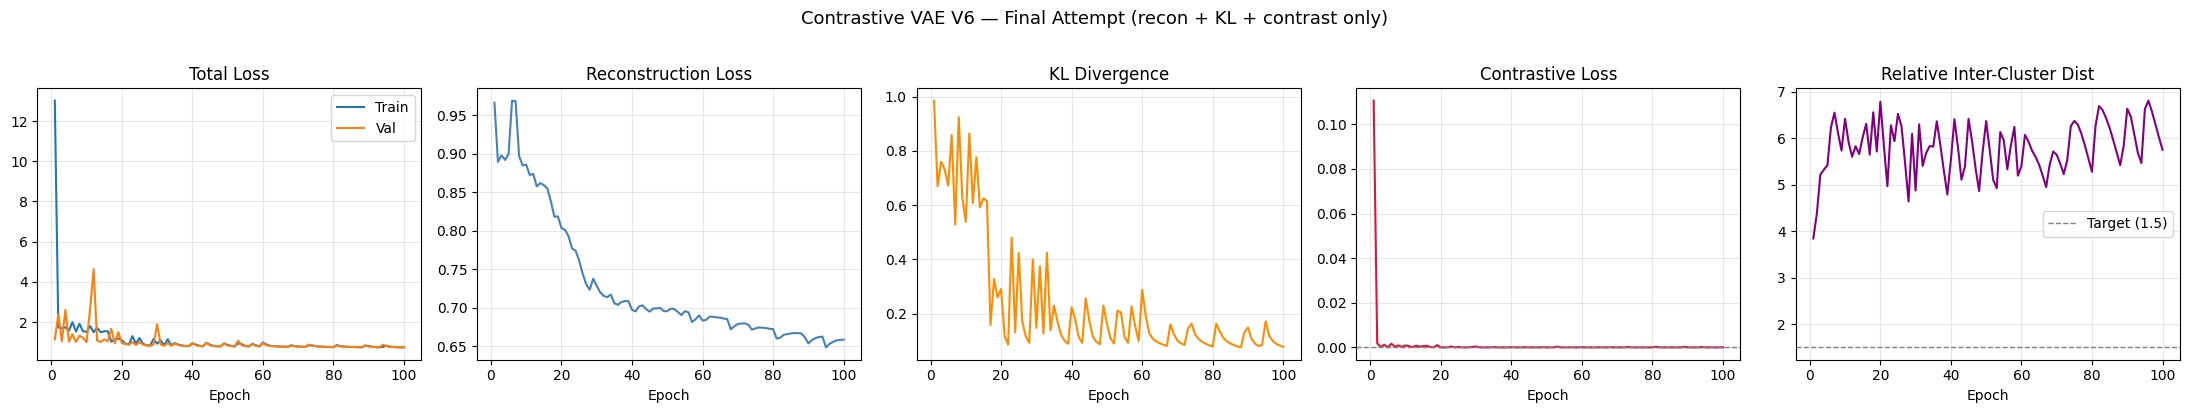

Saved as contrastive_vae_v6_final.png

── Final Latent Scale Check ─────────────────────────────────────────
Overall latent std:              0.3321
True global inter-cluster dist:  0.0140
True relative distance:          0.0423

── Distance Between Gender Means — Contrastive VAE V6 ───────────────
Activity       Distance    Relative Distance
---------------------------------------------
dws              0.0285               0.0857
ups              0.0424               0.1277
wlk              0.0453               0.1365
jog              0.0562               0.1693
std              0.0311               0.0937

── Full Results ─────────────────────────────────────────────────────
Version                                              Activity     Gender
------------------------------------------------------------------------
R  — Original                                          0.9466     0.7252
R' — Fixed VAE                                         0.9055     0.6944
R''— Fixed VAE Determ

In [121]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import copy
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score


BETA_CONTRAST      = 1.0
ALPHA_CONTRAST     = 100.0
MARGIN             = 1.5
INPUT_DIM_C        = 1536
LATENT_DIM_C = 50
BATCH_SIZE_C       = 512



class VAE_Contrastive_Final(nn.Module):
    def __init__(self, input_dim=1536, latent_dim=10):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 4096), nn.ReLU(),
            nn.Linear(4096, 2048),      nn.ReLU(),
            nn.Linear(2048, 1024),      nn.ReLU(),
            nn.Linear(1024, 512),       nn.ReLU(),
            nn.Linear(512, 256),        nn.ReLU(),
            nn.Linear(256, 128),        nn.ReLU()
        )

        self.fc_mu     = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(),
            nn.Linear(128, 256),        nn.ReLU(),
            nn.Linear(256, 512),        nn.ReLU(),
            nn.Linear(512, 1024),       nn.ReLU(),
            nn.Linear(1024, 2048),      nn.ReLU(),
            nn.Linear(2048, 4096),      nn.ReLU(),
            nn.Linear(4096, input_dim)
        )

    def encode(self, x):
        h      = self.encoder(x)
        mu     = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z          = self.reparameterize(mu, logvar)
        x_recon    = self.decode(z)
        return x_recon, mu, logvar



def vae_loss_final(x_recon, x, mu, logvar,
                   gender_labels,
                   beta=BETA_CONTRAST,
                   alpha_contrast=ALPHA_CONTRAST,
                   margin=MARGIN):
    """
    Three-term loss: reconstruction + KL + contrastive.
    Returns total loss and each component for logging.
    """

    recon_loss = F.mse_loss(x_recon, x, reduction="mean")

    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

    male_mask   = (gender_labels == 1)
    female_mask = (gender_labels == 0)

    if male_mask.sum() > 0 and female_mask.sum() > 0:
        mu_male   = mu[male_mask].mean(dim=0)
        mu_female = mu[female_mask].mean(dim=0)

        distance = torch.norm(mu_male - mu_female)

        contrast_loss = torch.clamp(margin - distance, min=0.0)
    else:
        contrast_loss = torch.tensor(0.0, device=mu.device)

    total = recon_loss + beta * kl_loss + alpha_contrast * contrast_loss

    return total, recon_loss, kl_loss, contrast_loss



y_train_gender_vals_c   = train_df["gender"].values.astype(np.int64)
y_train_gender_tensor_c = torch.tensor(y_train_gender_vals_c, dtype=torch.long)

train_dataset_c = TensorDataset(X_train_tensor, y_train_gender_tensor_c)
train_loader_c  = DataLoader(train_dataset_c,
                              batch_size=BATCH_SIZE_C,
                              shuffle=True)

print("Contrastive VAE V6 — Final attempt")
print(f"Loss: recon + {BETA_CONTRAST}·KL + {ALPHA_CONTRAST}·contrast")
print(f"No classification loss — simplified gradient landscape")
print(f"Fixed margin: {MARGIN} (valid because β=1.0 keeps std ~1.0)")
print(f"Batch size: {BATCH_SIZE_C}")
print(f"Batches per epoch: {len(train_loader_c)}")
print(f"\nSUCCESS CRITERION: RelDist > 0.1 by epoch 10")
print(f"If not met, contrastive loss is concluded incompatible")
print(f"with the general VAE on this dataset.")



NUM_EPOCHS_C = 100

vae_final = VAE_Contrastive_Final(
    input_dim=INPUT_DIM_C,
    latent_dim=LATENT_DIM_C
).to(device)

optimizer_c = optim.Adam(vae_final.parameters(), lr=1e-4)

scheduler_c = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_c, patience=5, factor=0.5
)

best_val_loss_c    = float("inf")
best_model_state_c = None

train_loss_hist_c = []
val_loss_hist_c   = []
recon_hist_c      = []
kl_hist_c         = []
contrast_hist_c   = []
reldist_hist_c    = []

print(f"\n{'Epoch':<8} {'Train':>10} {'Val':>10} {'Recon':>10} "
      f"{'KL':>10} {'Contrast':>12} {'RelDist':>10}")
print("-" * 76)

for epoch in range(NUM_EPOCHS_C):

    vae_final.train()
    t_total = t_recon = t_kl = t_contrast = 0.0

    sum_male_diag   = torch.zeros(LATENT_DIM_C, device=device)
    sum_female_diag = torch.zeros(LATENT_DIM_C, device=device)
    count_male_diag   = 0
    count_female_diag = 0
    sum_std_diag      = 0.0

    for (x_batch, gender_batch) in train_loader_c:
        x_batch      = x_batch.to(device)
        gender_batch = gender_batch.to(device)

        optimizer_c.zero_grad()

        x_recon, mu, logvar = vae_final(x_batch)

        loss, recon, kl, contrast = vae_loss_final(
            x_recon, x_batch, mu, logvar, gender_batch
        )

        loss.backward()
        optimizer_c.step()

        male_mask   = (gender_batch == 1)
        female_mask = (gender_batch == 0)
        if male_mask.sum() > 0:
            sum_male_diag   += mu[male_mask].detach().sum(dim=0)
            count_male_diag += male_mask.sum().item()
        if female_mask.sum() > 0:
            sum_female_diag   += mu[female_mask].detach().sum(dim=0)
            count_female_diag += female_mask.sum().item()
        sum_std_diag += mu.detach().std().item() * x_batch.size(0)

        n           = x_batch.size(0)
        t_total    += loss.item()      * n
        t_recon    += recon.item()     * n
        t_kl       += kl.item()        * n
        t_contrast += contrast.item()  * n

    N_train     = len(train_loader_c.dataset)
    t_total    /= N_train
    t_recon    /= N_train
    t_kl       /= N_train
    t_contrast /= N_train

    g_male   = sum_male_diag   / max(count_male_diag,   1)
    g_female = sum_female_diag / max(count_female_diag, 1)
    epoch_dist    = torch.norm(g_male - g_female).item()
    epoch_std     = sum_std_diag / N_train
    epoch_reldist = epoch_dist / max(epoch_std, 1e-8)

    vae_final.eval()
    v_total = 0.0
    with torch.no_grad():
        for (x_batch,) in val_loader:
            x_batch = x_batch.to(device)
            x_recon, mu, logvar = vae_final(x_batch)
            recon = F.mse_loss(x_recon, x_batch, reduction="mean")
            kl    = -0.5 * torch.mean(
                        1 + logvar - mu.pow(2) - logvar.exp())
            v_total += (recon + BETA_CONTRAST * kl).item() * x_batch.size(0)

    v_total /= len(val_loader.dataset)
    scheduler_c.step(v_total)

    if v_total < best_val_loss_c:
        best_val_loss_c    = v_total
        best_model_state_c = copy.deepcopy(vae_final.state_dict())

    train_loss_hist_c.append(t_total)
    val_loss_hist_c.append(v_total)
    recon_hist_c.append(t_recon)
    kl_hist_c.append(t_kl)
    contrast_hist_c.append(t_contrast)
    reldist_hist_c.append(epoch_reldist)

    if epoch < 20 or (epoch + 1) % 10 == 0:
        print(f"{epoch+1:<8} {t_total:>10.6f} {v_total:>10.6f} "
              f"{t_recon:>10.6f} {t_kl:>10.4f} {t_contrast:>12.6f} "
              f"{epoch_reldist:>10.4f}")

vae_final.load_state_dict(best_model_state_c)
torch.save(best_model_state_c, "best_vae_contrastive_final.pth")
print(f"\nBest validation loss: {best_val_loss_c:.6f}")
print("Saved to best_vae_contrastive_final.pth")

final_reldist = reldist_hist_c[-1]
print(f"\n── VERDICT ──────────────────────────────────────────────────────────")
print(f"Final relative inter-cluster distance: {final_reldist:.4f}")
print(f"Target:                                {MARGIN:.4f}")
if final_reldist > 0.3:
    print("PARTIAL SUCCESS — clusters moved. Run manipulation and check gender accuracy.")
elif final_reldist > 0.1:
    print("MARGINAL — some movement but likely insufficient for mean-swap.")
else:
    print("FAILURE — contrastive loss incompatible with general VAE on this dataset.")
    print("Conclusion: write up as negative result. The VAE reconstruction")
    print("objective prevents gender cluster separation regardless of the")
    print("contrastive loss formulation. Activity-specific VAEs (Section J)")
    print("are required for the paper's results.")



import matplotlib.pyplot as plt

epochs_range = range(1, NUM_EPOCHS_C + 1)
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

axes[0].plot(epochs_range, train_loss_hist_c, label="Train")
axes[0].plot(epochs_range, val_loss_hist_c,   label="Val")
axes[0].set_title("Total Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, recon_hist_c, color="steelblue")
axes[1].set_title("Reconstruction Loss")
axes[1].set_xlabel("Epoch")
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_range, kl_hist_c, color="darkorange")
axes[2].set_title("KL Divergence")
axes[2].set_xlabel("Epoch")
axes[2].grid(True, alpha=0.3)

axes[3].plot(epochs_range, contrast_hist_c, color="crimson")
axes[3].axhline(y=0.0, color="gray", linestyle="--", linewidth=1)
axes[3].set_title("Contrastive Loss")
axes[3].set_xlabel("Epoch")
axes[3].grid(True, alpha=0.3)

axes[4].plot(epochs_range, reldist_hist_c, color="purple")
axes[4].axhline(y=MARGIN, color="gray", linestyle="--", linewidth=1,
                label=f"Target ({MARGIN})")
axes[4].set_title("Relative Inter-Cluster Dist")
axes[4].set_xlabel("Epoch")
axes[4].legend()
axes[4].grid(True, alpha=0.3)

plt.suptitle("Contrastive VAE V6 — Final Attempt (recon + KL + contrast only)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("contrastive_vae_v6_final.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved as contrastive_vae_v6_final.png")



def encode_contrastive_final(model, loader, device):
    """Encode dataset, return mu vectors only."""
    model.eval()
    all_mu = []
    with torch.no_grad():
        for (x_batch,) in loader:
            mu, _ = model.encode(x_batch.to(device))
            all_mu.append(mu.cpu())
    return torch.cat(all_mu, dim=0).numpy()

Z_train_final_mu = encode_contrastive_final(vae_final, train_loader, device)
Z_test_final_mu  = encode_contrastive_final(vae_final, test_loader,  device)

overall_std_final = np.std(Z_train_final_mu)
male_mask_train   = (train_df["gender"].values == 1)
female_mask_train = (train_df["gender"].values == 0)
actual_dist       = np.linalg.norm(
    Z_train_final_mu[male_mask_train].mean(axis=0) -
    Z_train_final_mu[female_mask_train].mean(axis=0)
)

print(f"\n── Final Latent Scale Check ─────────────────────────────────────────")
print(f"Overall latent std:              {overall_std_final:.4f}")
print(f"True global inter-cluster dist:  {actual_dist:.4f}")
print(f"True relative distance:          {actual_dist / overall_std_final:.4f}")

train_df["z_mu_final"] = list(Z_train_final_mu)
test_df["z_mu_final"]  = list(Z_test_final_mu)

final_group_means = {}
for (activity, gender), group in train_df.groupby(["activity_merged", "gender"]):
    z_stack = np.stack(group["z_mu_final"].values)
    final_group_means[(activity, gender)] = z_stack.mean(axis=0)

activities = ['dws', 'ups', 'wlk', 'jog', 'std']

print(f"\n── Distance Between Gender Means — Contrastive VAE V6 ───────────────")
print(f"{'Activity':<10} {'Distance':>12} {'Relative Distance':>20}")
print("-" * 45)
for activity in activities:
    m = np.linalg.norm(
        final_group_means[(activity, 1)] - final_group_means[(activity, 0)]
    )
    print(f"{activity:<10} {m:>12.4f} {m / overall_std_final:>20.4f}")

X_test_final_recon = decode_latent(vae_final, Z_test_final_mu, device)
y_pred_act_recon   = activity_clf.predict(X_test_final_recon)
y_pred_gen_recon   = gender_clf.predict(X_test_final_recon)

Z_test_final_det = np.stack([
    deterministic_manipulation(
        row["z_mu_final"], row["activity_merged"], row["gender"], final_group_means
    )
    for _, row in test_df.iterrows()
])
X_test_final_det = decode_latent(vae_final, Z_test_final_det, device)
y_pred_act_det   = activity_clf.predict(X_test_final_det)
y_pred_gen_det   = gender_clf.predict(X_test_final_det)

Z_test_final_prob = np.stack([
    probabilistic_manipulation(
        row["z_mu_final"], row["activity_merged"], row["gender"],
        final_group_means, p=0.5
    )
    for _, row in test_df.iterrows()
])
X_test_final_prob = decode_latent(vae_final, Z_test_final_prob, device)
y_pred_act_prob   = activity_clf.predict(X_test_final_prob)
y_pred_gen_prob   = gender_clf.predict(X_test_final_prob)

print(f"\n── Full Results ─────────────────────────────────────────────────────")
print(f"{'Version':<50} {'Activity':>10} {'Gender':>10}")
print("-" * 72)
print(f"{'R  — Original':<50} {'0.9466':>10} {'0.7252':>10}")
print(f"{'R\' — Fixed VAE':<50} {'0.9055':>10} {'0.6944':>10}")
print(f"{'R\'\'— Fixed VAE Deterministic':<50} {'0.9053':>10} {'0.6920':>10}")
print(f"{'R\' — VAE + clf loss':<50} {'0.9286':>10} {'0.7446':>10}")
print(f"{'R\'\'— VAE + clf loss Deterministic':<50} {'0.9286':>10} {'0.7496':>10}")
print(f"{'R\' — Contrastive V6 Reconstructed':<50} "
      f"{accuracy_score(y_test_activity, y_pred_act_recon):>10.4f} "
      f"{accuracy_score(y_test_gender,   y_pred_gen_recon):>10.4f}")
print(f"{'R\'\'— Contrastive V6 Deterministic':<50} "
      f"{accuracy_score(y_test_activity, y_pred_act_det):>10.4f} "
      f"{accuracy_score(y_test_gender,   y_pred_gen_det):>10.4f}")
print(f"{'R\'\'— Contrastive V6 Probabilistic':<50} "
      f"{accuracy_score(y_test_activity, y_pred_act_prob):>10.4f} "
      f"{accuracy_score(y_test_gender,   y_pred_gen_prob):>10.4f}")

# M - AE standard

In [122]:
print("Train loader batches:", len(train_loader))
print("Test loader batches:", len(test_loader))
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)
print("activity_clf:", activity_clf)
print("gender_clf:", gender_clf)

Train loader batches: 371
Test loader batches: 123
X_train_scaled shape: (94941, 1536)
X_test_scaled shape: (31373, 1536)
activity_clf: MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=20)
gender_clf: MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=20)


In [123]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import copy
from sklearn.metrics import accuracy_score

In [124]:
class AutoEncoder(nn.Module):
    def __init__(self, input_dim=1536, latent_dim=10):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 4096), nn.ReLU(),
            nn.Linear(4096, 2048),      nn.ReLU(),
            nn.Linear(2048, 1024),      nn.ReLU(),
            nn.Linear(1024, 512),       nn.ReLU(),
            nn.Linear(512, 256),        nn.ReLU(),
            nn.Linear(256, 128),        nn.ReLU(),
            nn.Linear(128, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(),
            nn.Linear(128, 256),        nn.ReLU(),
            nn.Linear(256, 512),        nn.ReLU(),
            nn.Linear(512, 1024),       nn.ReLU(),
            nn.Linear(1024, 2048),      nn.ReLU(),
            nn.Linear(2048, 4096),      nn.ReLU(),
            nn.Linear(4096, input_dim)
        )

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        z      = self.encode(x)
        x_recon = self.decode(z)
        return x_recon, z


def ae_loss(x_recon, x):
    return F.mse_loss(x_recon, x, reduction="mean")


print("Standard autoencoder defined.")
print("Architecture: 1536→4096→2048→1024→512→256→128→10→128→256→512"
      "→1024→2048→4096→1536")
print("Loss: reconstruction only (MSE), no KL term")

Standard autoencoder defined.
Architecture: 1536→4096→2048→1024→512→256→128→10→128→256→512→1024→2048→4096→1536
Loss: reconstruction only (MSE), no KL term


In [125]:
NUM_EPOCHS_AE = 100

ae_model  = AutoEncoder(input_dim=1536, latent_dim=10).to(device)
opt_ae    = optim.Adam(ae_model.parameters(), lr=1e-4)
sched_ae  = torch.optim.lr_scheduler.ReduceLROnPlateau(
            opt_ae, patience=5, factor=0.5)

best_val_ae    = float("inf")
best_state_ae  = None

print("Training standard autoencoder...")
print(f"{'Epoch':<8} {'Train Loss':>12} {'Val Loss':>12}")
print("-" * 35)

for epoch in range(NUM_EPOCHS_AE):
    ae_model.train()
    train_total = 0.0

    for (x_batch,) in train_loader:
        x_batch = x_batch.to(device)
        opt_ae.zero_grad()
        x_recon, z = ae_model(x_batch)
        loss       = ae_loss(x_recon, x_batch)
        loss.backward()
        opt_ae.step()
        train_total += loss.item() * x_batch.size(0)

    train_total /= len(train_loader.dataset)

    ae_model.eval()
    val_total = 0.0
    with torch.no_grad():
        for (x_batch,) in val_loader:
            x_batch = x_batch.to(device)
            x_recon, z = ae_model(x_batch)
            loss       = ae_loss(x_recon, x_batch)
            val_total += loss.item() * x_batch.size(0)
    val_total /= len(val_loader.dataset)

    sched_ae.step(val_total)

    if val_total < best_val_ae:
        best_val_ae   = val_total
        best_state_ae = copy.deepcopy(ae_model.state_dict())

    if (epoch + 1) % 10 == 0:
        print(f"{epoch+1:<8} {train_total:>12.6f} {val_total:>12.6f}")

ae_model.load_state_dict(best_state_ae)
torch.save(best_state_ae, "best_ae.pth")
print(f"\nBest validation loss: {best_val_ae:.6f}")
print("Saved to best_ae.pth")
print(f"\nFixed VAE reference:")
print(f"  Best val loss: 0.231444")
print(f"  Train recon epoch 100: 0.179317")

Training standard autoencoder...
Epoch      Train Loss     Val Loss
-----------------------------------
10           0.312295     0.316348
20           0.254584     0.270712
30           0.228565     0.252863
40           0.211509     0.241289
50           0.198489     0.234489
60           0.187866     0.230886
70           0.179950     0.227672
80           0.172630     0.226959
90           0.166745     0.226776
100          0.150045     0.220458

Best validation loss: 0.220229
Saved to best_ae.pth

Fixed VAE reference:
  Best val loss: 0.231444
  Train recon epoch 100: 0.179317


In [126]:
def encode_ae(model, loader, device):
    """Encode dataset using standard AE, return deterministic z vectors."""
    model.eval()
    all_z = []
    with torch.no_grad():
        for (x_batch,) in loader:
            _, z = model(x_batch.to(device))
            all_z.append(z.cpu())
    return torch.cat(all_z, dim=0).numpy()

def decode_ae(model, Z, device):
    """Decode latent vectors back to signal space using AE decoder."""
    model.eval()
    with torch.no_grad():
        out = model.decode(
            torch.tensor(Z, dtype=torch.float32).to(device))
    return out.cpu().numpy()

Z_train_ae = encode_ae(ae_model, train_loader, device)
Z_test_ae  = encode_ae(ae_model, test_loader,  device)

print(f"AE train latent shape: {Z_train_ae.shape}")
print(f"AE test latent shape:  {Z_test_ae.shape}")

X_test_ae_recon = decode_ae(ae_model, Z_test_ae, device)

y_pred_act_ae_recon = activity_clf.predict(X_test_ae_recon)
y_pred_gen_ae_recon = gender_clf.predict(X_test_ae_recon)

print("\n── Standard AE Reconstruction Check (R') ────────────────────────")
print(f"{'Version':<35} {'Activity':>10} {'Gender':>10}")
print("-" * 57)
print(f"{'Original R':<35} {'0.9464':>10} {'0.7331':>10}")
print(f"{'Standard AE R\'':<35} "
      f"{accuracy_score(y_test_activity, y_pred_act_ae_recon):>10.4f} "
      f"{accuracy_score(y_test_gender,   y_pred_gen_ae_recon):>10.4f}")
print(f"{'Fixed VAE R\' (Section F)':<35} {'0.9055':>10} {'0.6944':>10}")

AE train latent shape: (94941, 10)
AE test latent shape:  (31373, 10)

── Standard AE Reconstruction Check (R') ────────────────────────
Version                               Activity     Gender
---------------------------------------------------------
Original R                              0.9464     0.7331
Standard AE R'                          0.9036     0.7053
Fixed VAE R' (Section F)                0.9055     0.6944


In [127]:
activities = ['dws', 'jog', 'std', 'ups', 'wlk']

train_df["z_ae"] = list(Z_train_ae)

ae_group_means = {}
for (activity, gender), group in train_df.groupby(
        ["activity_merged", "gender"]):
    z_stack = np.stack(group["z_ae"].values)
    ae_group_means[(activity, gender)] = z_stack.mean(axis=0)

overall_std_ae = np.std(Z_train_ae)

print("── Distance Between Gender Means — Standard AE Latent Space ──────")
print(f"{'Activity':<10} {'Distance':>12} {'Relative Distance':>20}")
print("-" * 45)

distances_ae = {}
for activity in activities:
    male_mean   = ae_group_means[(activity, 1)]
    female_mean = ae_group_means[(activity, 0)]
    distance    = np.linalg.norm(male_mean - female_mean)
    distances_ae[activity] = distance
    relative    = distance / overall_std_ae
    print(f"{activity:<10} {distance:>12.4f} {relative:>20.4f}")

avg_dist_ae = np.mean(list(distances_ae.values()))
print("-" * 45)
print(f"{'Average':<10} {avg_dist_ae:>12.4f} "
      f"{avg_dist_ae/overall_std_ae:>20.4f}")
print(f"\nOverall AE latent std: {overall_std_ae:.4f}")
print(f"\nComparison:")
print(f"  Fixed VAE avg relative distance:      ~0.04–0.06")
print(f"  VAE + clf loss avg relative distance:  ~0.05–0.07")
print(f"  PCA avg relative distance:             ~1.2–2.2")

── Distance Between Gender Means — Standard AE Latent Space ──────
Activity       Distance    Relative Distance
---------------------------------------------
dws              3.0846               0.0634
jog              2.0334               0.0418
std              1.2100               0.0249
ups              1.1527               0.0237
wlk              0.9933               0.0204
---------------------------------------------
Average          1.6948               0.0348

Overall AE latent std: 48.6579

Comparison:
  Fixed VAE avg relative distance:      ~0.04–0.06
  VAE + clf loss avg relative distance:  ~0.05–0.07
  PCA avg relative distance:             ~1.2–2.2


In [128]:
test_df["z_ae"] = list(Z_test_ae)

Z_test_ae_det = []
for _, row in test_df.iterrows():
    z        = row["z_ae"]
    activity = row["activity_merged"]
    gender   = row["gender"]

    if activity not in ['dws', 'jog', 'ups', 'wlk']:
        Z_test_ae_det.append(z.copy())
        continue

    original_mean = ae_group_means[(activity, gender)]
    target_mean   = ae_group_means[(activity, 1 - gender)]
    z_new         = z - original_mean + target_mean
    Z_test_ae_det.append(z_new)

Z_test_ae_det = np.stack(Z_test_ae_det)
X_test_ae_det = decode_ae(ae_model, Z_test_ae_det, device)

Z_test_ae_prob = []
for _, row in test_df.iterrows():
    z        = row["z_ae"]
    activity = row["activity_merged"]
    gender   = row["gender"]

    if activity not in ['dws', 'jog', 'ups', 'wlk']:
        Z_test_ae_prob.append(z.copy())
        continue

    if np.random.rand() < 0.5:
        original_mean = ae_group_means[(activity, gender)]
        target_mean   = ae_group_means[(activity, 1 - gender)]
        z_new         = z - original_mean + target_mean
    else:
        z_new = z.copy()
    Z_test_ae_prob.append(z_new)

Z_test_ae_prob = np.stack(Z_test_ae_prob)
X_test_ae_prob = decode_ae(ae_model, Z_test_ae_prob, device)

y_pred_act_ae_det  = activity_clf.predict(X_test_ae_det)
y_pred_gen_ae_det  = gender_clf.predict(X_test_ae_det)
y_pred_act_ae_prob = activity_clf.predict(X_test_ae_prob)
y_pred_gen_ae_prob = gender_clf.predict(X_test_ae_prob)

print("── Standard AE Full Results ──────────────────────────────────────")
print(f"{'Version':<35} {'Activity':>10} {'Gender':>10}")
print("-" * 57)
print(f"{'Original R':<35} {'0.9464':>10} {'0.7331':>10}")
print(f"{'Standard AE R\'':<35} "
      f"{accuracy_score(y_test_activity, y_pred_act_ae_recon):>10.4f} "
      f"{accuracy_score(y_test_gender,   y_pred_gen_ae_recon):>10.4f}")
print(f"{'Standard AE R\'\' Deterministic':<35} "
      f"{accuracy_score(y_test_activity, y_pred_act_ae_det):>10.4f} "
      f"{accuracy_score(y_test_gender,   y_pred_gen_ae_det):>10.4f}")
print(f"{'Standard AE R\'\' Probabilistic':<35} "
      f"{accuracy_score(y_test_activity, y_pred_act_ae_prob):>10.4f} "
      f"{accuracy_score(y_test_gender,   y_pred_gen_ae_prob):>10.4f}")
print(f"\nFixed VAE reference (Section F):")
print(f"{'Fixed VAE R\'':<35} {'0.9055':>10} {'0.6944':>10}")
print(f"{'Fixed VAE R\'\' Deterministic':<35} {'0.9217':>10} {'0.7225':>10}")
print(f"{'Fixed VAE R\'\' Probabilistic':<35} {'0.9218':>10} {'0.7221':>10}")

── Standard AE Full Results ──────────────────────────────────────
Version                               Activity     Gender
---------------------------------------------------------
Original R                              0.9464     0.7331
Standard AE R'                          0.9036     0.7053
Standard AE R'' Deterministic           0.9037     0.7059
Standard AE R'' Probabilistic           0.9036     0.7056

Fixed VAE reference (Section F):
Fixed VAE R'                            0.9055     0.6944
Fixed VAE R'' Deterministic             0.9217     0.7225
Fixed VAE R'' Probabilistic             0.9218     0.7221


In [129]:
print("── Full Comparison — PCA vs Standard AE vs VAE ───────────────────")
print(f"{'Method':<35} {'Rel Dist':>10} {'Gender R\'\'':>12}")
print("-" * 60)
print(f"{'PCA baseline':<35} {'1.2–2.2':>10} {'N/A':>12}")
print(f"{'Standard AE':<35} "
      f"{avg_dist_ae/overall_std_ae:>10.4f} "
      f"{accuracy_score(y_test_gender, y_pred_gen_ae_det):>12.4f}")
print(f"{'Fixed VAE (Section F)':<35} {'~0.05':>10} {'0.7225':>12}")
print(f"{'VAE + clf loss (Section G)':<35} {'~0.06':>10} {'0.7274':>12}")
print(f"{'Paper target':<35} {'—':>10} {'0.1839':>12}")

── Full Comparison — PCA vs Standard AE vs VAE ───────────────────
Method                                Rel Dist   Gender R''
------------------------------------------------------------
PCA baseline                           1.2–2.2          N/A
Standard AE                             0.0348       0.7059
Fixed VAE (Section F)                    ~0.05       0.7225
VAE + clf loss (Section G)               ~0.06       0.7274
Paper target                                 —       0.1839
